In [4]:
%pip install beautifulsoup4 scikit_posthocs publicsuffix2 adblockparser pingouin tldextract statannotations pandas numpy matplotlib seaborn scipy requests tqdm


Note: you may need to restart the kernel to use updated packages.


In [1]:
    # imports

%matplotlib inline
import pandas as pd
import numpy as np
import sqlite3
import os
from bs4 import BeautifulSoup as bs
import re
from functools import reduce
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
sns.set_theme()
import requests
import warnings
import scipy.stats
import scikit_posthocs as sp
from publicsuffix2 import PublicSuffixList
import time
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pingouin as pg
import tldextract
import copy


from tqdm import tqdm
from adblockparser import AdblockRules
import csv
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor

from statannotations.Annotator import Annotator

psl = PublicSuffixList()
warnings.filterwarnings('ignore')
# %config Completer.use_jedi = False

/root/miniconda3/envs/openwpm/lib/python3.9/site-packages/tldextract/cli.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.autolayout"] = False   # True can cause PDF layout bugs
plt.rcParams["text.usetex"] = False         # Disable LaTeX text
plt.rcParams['figure.figsize'] = (3.35, 7.03)

sns.set_style("white")

single_col_width = 3.6 * 0.9
double_col_width = 7.8 * 0.9


In [4]:
import requests
import json
import os

def download_disconnect_list():
    """
    Download the Disconnect.me tracker protection list
    """
    # URL for the Disconnect.me services list
    url = "https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json"

    print("Downloading Disconnect.me tracker list...")
    print(f"URL: {url}")

    try:
        # Download the file
        response = requests.get(url, timeout=30)
        response.raise_for_status()  # Raise an error for bad status codes

        # Parse JSON
        json_data = response.json()

        # Create directory if it doesn't exist
        os.makedirs('dataset_disconnect', exist_ok=True)

        # Save to file
        output_file = 'dataset_disconnect/services-relay-disconnect.json'
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

        print(f"✓ Successfully downloaded and saved to: {output_file}")

        # Display available categories
        if 'categories' in json_data:
            print("\nAvailable categories:")
            for category in json_data['categories'].keys():
                domain_count = len(json_data['categories'][category])
                print(f"  - {category}: {domain_count} domains")

        return json_data

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading file: {e}")
        print("\nAlternative URLs to try:")
        print("1. https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json")
        print("2. https://services.disconnect.me/disconnect-plaintext.json")
        return None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None

def extract_domains_from_category(category_list):
    """
    Extract all domains from a nested category structure

    Format:
    [
      {"ServiceName": {"url": ["domain1", "domain2"]}},
      ...
    ]
    """
    domains = set()

    for item in category_list:
        # Each item is a dict with one key (service name)
        for service_name, service_data in item.items():
            # service_data is a dict with URLs as keys and domain lists as values
            for url, domain_list in service_data.items():
                # Add all domains from the list
                domains.update(domain_list)

    return domains

def load_and_process_disconnect_data(json_file='dataset_disconnect/services-relay-disconnect.json'):
    """
    Load the Disconnect.me list and extract fingerprinting domains
    """
    print(f"\nLoading Disconnect.me data from: {json_file}")

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        # Extract domains from FingerprintingInvasive and FingerprintingGeneral categories
        fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
        fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])

        # Parse the nested structure to extract actual domains
        fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
        fp_general_domains = extract_domains_from_category(fp_general_list)


        print(f"✓ Loaded successfully")
        print(f"  - FingerprintingInvasive domains: {len(fp_invasive_domains)}")
        print(f"  - FingerprintingGeneral domains: {len(fp_general_domains)}")


        # Display some example domains
        if fp_invasive_domains:
            print(f"\nExample FingerprintingInvasive domains:")
            for domain in list(fp_invasive_domains)[:5]:
                print(f"  - {domain}")

        if fp_general_domains:
            print(f"\nExample FingerprintingGeneral domains:")
            for domain in list(fp_general_domains)[:5]:
                print(f"  - {domain}")

        return fp_invasive_domains, fp_general_domains

    except FileNotFoundError:
        print(f"✗ File not found: {json_file}")
        print("Run download_disconnect_list() first to download the file.")
        return None, None, None, None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None, None, None, None

def apply_disconnect_categories_to_dataframe(df, domain_column='domain_script_url'):
    """
    Apply FingerprintingInvasive and FingerprintingGeneral boolean columns to dataframe

    Parameters:
    - df: pandas DataFrame with script/request data
    - domain_column: column name containing the domain to check
    """
    # Load the disconnect data
    fp_invasive_domains, fp_general_domains = load_and_process_disconnect_data()

    if fp_invasive_domains is None:
        print("Failed to load Disconnect.me data. Attempting to download...")
        json_data = download_disconnect_list()
        if json_data:
            fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
            fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])


            fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
            fp_general_domains = extract_domains_from_category(fp_general_list)

        else:
            return df

    # Create boolean columns
    print(f"\nApplying categories to dataframe...")
    df['FingerprintingInvasive'] = df[domain_column].isin(fp_invasive_domains)
    df['FingerprintingGeneral'] = df[domain_column].isin(fp_general_domains)


    print(f"✓ Categories applied:")
    print(f"  - FingerprintingInvasive: {df['FingerprintingInvasive'].sum()} matches")
    print(f"  - FingerprintingGeneral: {df['FingerprintingGeneral'].sum()} matches")


    return df

# # ============================================================
# # MAIN EXECUTION
# # ============================================================
# if __name__ == "__main__":
#     print("="*60)
#     print("DISCONNECT.ME TRACKER LIST DOWNLOADER")
#     print("="*60)
#     df_2 = main_map_unique["javascript"]
#     df_2 = df_2[df_2["clicked"].notna()]
#     df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
#     df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)

#     # Step 1: Download the list
#     json_data = download_disconnect_list()

#     if json_data:
#         # Step 2: Load and process
#         df_2 = apply_disconnect_categories_to_dataframe(df_2, domain_column='domain_script_url')


URL: https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json
✓ Successfully downloaded and saved to: dataset_disconnect/services-relay-disconnect.json

Available categories:
  - Email: 83 domains
  - EmailAggressive: 84 domains
  - Advertising: 1272 domains
  - Content: 101 domains
  - Analytics: 355 domains
  - FingerprintingInvasive: 282 domains
  - FingerprintingGeneral: 98 domains
  - Anti-fraud: 15 domains
  - Social: 16 domains
  - ConsentManagers: 7 domains
  - Cryptomining: 14 domains

Loading Disconnect.me data from: dataset_disconnect/services-relay-disconnect.json
✓ Loaded successfully
  - FingerprintingInvasive domains: 377
  - FingerprintingGeneral domains: 179

Example FingerprintingInvasive domains:
  - api.adquery.io
  - 7roundprince.com
  - keenquill.com
  - fishrobotflower.com
  - durchsichtig.xyz

Example FingerprintingGeneral domains:
  - 2mdn.net
  - openx.net
  - elements.stytch.com
  - appcast.io
  - rto-study.oss-us-wes

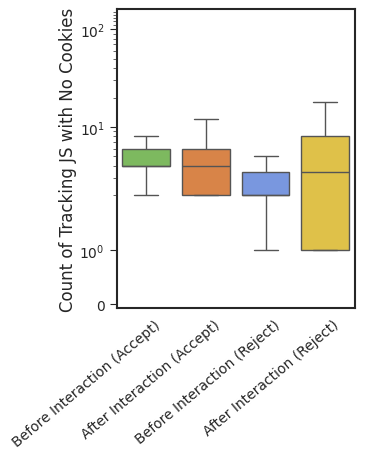

In [10]:
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl


df_javascript_all = pd.read_csv('js_combined.csv')
df_cookie_all = pd.read_csv('javascript_cookies_combined.csv')

json_data = download_disconnect_list()
if json_data :
    df_javascript_all = apply_disconnect_categories_to_dataframe(df_javascript_all, domain_column='domain_script_url')


common_domains = pd.read_csv('common_domains.csv')
common_domains = set(common_domains.iloc[:, 0])

modes = [
    "Before Interaction (Accept)",
    "After Interaction (Accept)",
    "Before Interaction (Reject)",
    "After Interaction (Reject)"
]

def get_stage_counts(df):

    df = df[['visit_id', "clicked_stage", "domain"]]
    
    grouped = df.groupby(['domain', 'clicked_stage']).size().reset_index(name='count')
    print(grouped.head(10))
    # stages = ["Before Interaction", "After Interaction"]
    stages = df["clicked_stage"].unique().tolist()

    stages_df = pd.DataFrame({"clicked_stage": stages})
    print(stages_df)
    stages_df["key"] = 1
    print(stages_df)
    result = pd.merge(
        df[['visit_id', 'domain', 'clicked_stage']],
        grouped,
        on=['domain', 'clicked_stage'],
        how='left'
    )

    # Keep unique rows
    result = result.drop_duplicates()

    # Final column order
    result = result[['visit_id', 'domain', 'clicked_stage', 'count']]

    return result


# ─────────────────────────────────────────────────────────────
# Collect filtered data for all 4 stages
# ─────────────────────────────────────────────────────────────
final_data = []

for mode in modes:

    print(f"\nProcessing: {mode}")

    # Stage-specific filtering
    df_js = df_javascript_all[
        df_javascript_all['clicked_stage'] == mode
    ].copy()

    df_cookie = df_cookie_all[
        df_cookie_all['clicked_stage'] == mode
    ].copy()

    # Remove first-party cookies
    df_cookie = df_cookie[
        df_cookie['domain_cookie'] != df_cookie['domain']
    ]

    # Domains with tracking cookies
    domains_with_tracking_cookies = set(df_cookie['domain'])

    # Domains WITHOUT tracking cookies
    domains_without_tracking_cookies = (
        common_domains - domains_with_tracking_cookies
    )

    # Keep invasive/general fingerprinting scripts
    df_js = df_js[
        (df_js['AllList'] == True) &
        (
            (df_js['FingerprintingInvasive'] == True) |
            (df_js['FingerprintingGeneral'] == True)
        ) &
        (df_js['domain_script_url'] != df_js['domain'])
    ]

    # Domains with fingerprinting scripts
    domains_with_fingerprinting_scripts = set(df_js['domain'])

    # Only FS and NO cookies
    domain_with_only_fs = (
        domains_with_fingerprinting_scripts &
        domains_without_tracking_cookies
    )

    # Keep only those rows
    df_js = df_js[
        df_js['domain'].isin(domain_with_only_fs)
    ]

    # Get counts
    counts = get_stage_counts(df_js)

    final_data.append(counts)

# Merge all stages together
final_df = pd.concat(final_data, ignore_index=True)
# ─────────────────────────────────────────────────────────────
# Statistical summary (MISSING PART)
# ─────────────────────────────────────────────────────────────
print("\n===== Statistical Summary (JS with No Cookies) =====\n")

summary = final_df.groupby("clicked_stage")["count"].describe()

print(summary)

print("\n====================================================\n")
# ─────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

# TO THIS (matches graph b):
f, axes = plt.subplots(
    1, 1,
    figsize=(
        single_col_width * 0.95,  # ✓ same as graph b
        single_col_width * 1.2    # ✓ same as graph b
    )
)

sns.boxplot(
    x='clicked_stage',
    y='count',
    order=modes,
    data=final_df,
    showfliers=False,
    ax=axes,
    palette=colors
)

# ── Symlog scale ─────────────────────────────────────────────
axes.set_yscale("symlog")
axes.set_ylim(-0.075, 160)

# ── Major ticks ──────────────────────────────────────────────
major_ticks = [0, 1, 10, 100]

axes.set_yticks(major_ticks)

axes.set_yticklabels(
    ['0', '$10^{0}$', '$10^{1}$', '$10^{2}$'],
    fontsize=10
)

# ── Minor dash marks ─────────────────────────────────────────
minor_ticks = [
    2, 3, 4, 5, 6, 7, 8, 9,
    20, 30, 40, 50, 60, 70, 80, 90,
    110, 120, 130, 140, 150
]

axes.yaxis.set_minor_locator(FixedLocator(minor_ticks))
axes.yaxis.set_minor_formatter(NullFormatter())

axes.tick_params(
    axis='y',
    which='major',
    length=5,
    width=0.8,
    left=True
)

axes.tick_params(
    axis='y',
    which='minor',
    length=3,
    width=0.5,
    left=True
)

# ── Labels ───────────────────────────────────────────────────
axes.set_ylabel(
    'Count of Tracking JS with No Cookies',
    labelpad=2
)

axes.set_xlabel('')

# ── X tick formatting ────────────────────────────────────────
xtl = axes.get_xticklabels()

axes.set_xticklabels(
    labels=xtl,
    rotation=40,
    ha="right",
    fontsize=10
)

dx = 12 / 72.
dy = 3 / 72.

offset = mpl.transforms.ScaledTranslation(
    dx,
    dy,
    f.dpi_scale_trans
)

for label in axes.xaxis.get_majorticklabels():
    label.set_transform(
        label.get_transform() + offset
    )
    label.set_fontsize(10)

plt.show()

f.savefig(
    'boxplot_tracking_js_no_cookies.pdf',
    bbox_inches='tight',
    dpi=300
)

In [ ]:
with open('Split_disclosure_output/Transparent.csv', 'r') as file:
    transparent_disclosure = [line.strip() for line in file.readlines()]
with open('Split_disclosure_output/Partially_Ambiguous.csv', 'r') as file:
    partially_ambiguous = [line.strip() for line in file.readlines()]

with open('/home/subcode/Split_disclosure_output/Completely_Ambiguous.csv', 'r') as file:
    complete_ambiguous = [line.strip() for line in file.readlines()]

with open('Split_disclosure_output/No_Disclosure.csv', 'r') as file:
    no_disclosure = [line.strip() for line in file.readlines()]

class_1, class_2, class_3, class_4 = [], [], [], []
class_5, class_6, class_7, class_8 = [], [], [], []

base_path = "Split_disclosure_output/class_"

for i in range(1, 8+1):
    file_path = f"{base_path}{i}.csv"

    try:
        with open(file_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception:
        lines = []   # File missing or empty -> ignore safely

    globals()[f"class_{i}"] = lines

In [17]:
df_1 = pd.read_csv('Accept/javascript_cookies.csv')

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
import gc
import os

# Define colors for the groups
colors = plt.cm.tab20.colors
# ref_df = pd.read_csv("common_domains_only_translated.csv")

# common_domains = set(ref_df["domains"].dropna().unique())


def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""

    if domain in class_1:
        return 1
    if domain in class_2:
        return 2
    if domain in class_3:
        return 3
    if domain in class_4:
        return 4
    if domain in class_5:
        return 5
    if domain in class_6:
        return 6
    if domain in class_7:
        return 7
    if domain in class_8:
        return 8
    return None


def process_single_file(df):
    """Process a single cookie file and return unique cookies"""

    # Load one file
    df_cookie = df
    print(f"  Loaded {len(df_cookie)} rows")

    df_cookie_accept = df_cookie[df_cookie['clicked_stage'].isin([
        'After Interaction (Accept)',
    ])]
    # print(df_cookie_accept)
    # print('check')
    # print(df_cookie_accept[df_cookie_accept['domain'].isin(common_domains)])
    df_cookie_accept = df_cookie_accept[
        (df_cookie_accept['domain_cookie'] != df_cookie_accept['domain']) 
    ]

    df_cookie_accept['disclosure_group'] = df_cookie_accept['domain'].apply(assign_disclosure_group)
    df_cookie_accept = df_cookie_accept[df_cookie_accept['disclosure_group'].notnull()]

    print(f"After disclosure assignment: {len(df_cookie_accept)} rows")

    # Extract unique cookies from this file
    cookies_this_file = df_cookie_accept[
        ['disclosure_group', 'domain', 'host_url', 'name']
    ].drop_duplicates()

    print(f"  Unique cookies in this file: {len(cookies_this_file)}")

    return cookies_this_file

# Process this file
cookies_from_file = process_single_file(df_1)


  Loaded 2760894 rows
After disclosure assignment: 2408612 rows
  Unique cookies in this file: 2288544


In [18]:
print(df_2['domain'].nunique())

28151


In [30]:
print((cookies_from_file[cookies_from_file['disclosure_group'] == 8]['name']).nunique())

2396


In [15]:
print(cookies_from_file['domain'].nunique())

20460


In [6]:
print(cookies_from_file['disclosure_group'].unique())

[5 2 4 6 1 7 8]


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

class_map = {
    1: class_1,
    2: class_2,
    3: class_3,
    4: class_4,
    5: class_5,
    6: class_6,
    7: class_7,
    8: class_8,
}

common_domains = set().union(*class_map.values())

# ============================================================
# LOAD DATA
# ============================================================
all_cookies_unique = cookies_from_file

# all_cookies_unique['disclosure_group'] = all_cookies_unique['domain'].apply(assign_disclosure_group)

class_mapping = {
    1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
    5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8",
    None: "Unassigned"
}

all_cookies_unique['disclosure_group'] = all_cookies_unique['disclosure_group'].map(class_mapping)
print(all_cookies_unique)



        disclosure_group       domain          host_url  \
0                Class 5  register.it  .doubleclick.net   
1                Class 5  register.it  .doubleclick.net   
2                Class 5  register.it  .doubleclick.net   
3                Class 5  register.it  .doubleclick.net   
4                Class 5  register.it         .bing.com   
...                  ...          ...               ...   
2760881          Class 4  ftbwiki.org       .rfihub.com   
2760882          Class 4  ftbwiki.org     .adkernel.com   
2760883          Class 4  ftbwiki.org     .adkernel.com   
2760884          Class 4  ftbwiki.org     .adkernel.com   
2760885          Class 4  ftbwiki.org     .adkernel.com   

                                            name  
0                                    test_cookie  
1        register.it-_-test_cookie-_-bannerclick  
2                                            IDE  
3                register.it-_-IDE-_-bannerclick  
4                                   

In [20]:
# ============================================================
# COOKIE COUNTING (UNCHANGED LOGIC)
# ============================================================
cookie_counts = all_cookies_unique.groupby(
    ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')

combined_data = cookie_counts.groupby(
    ['disclosure_group', 'domain']
)['cookie_count'].sum().reset_index(name='total_cookie_count')

print(combined_data)


      disclosure_group            domain  total_cookie_count
0              Class 1         01net.com                 350
1              Class 1     1001giochi.it                 408
2              Class 1       1001jeux.fr                 412
3              Class 1  1001jogos.com.br                 470
4              Class 1     1001spiele.de                 428
...                ...               ...                 ...
20455          Class 8   weather-doc.com                 320
20456          Class 8       weather.com                 332
20457          Class 8         wpmet.com                  40
20458          Class 8  wunderground.com                 276
20459          Class 8      zenmarket.jp                   4

[20460 rows x 3 columns]


In [9]:
print((combined_data[combined_data['disclosure_group'] == 'Class 8']['total_cookie_count']).unique())

[ 46   6   4  42  72  20  40   2 644  12  14   8 692 578  16  10 110  38
  36  48  96  28  22  70  78  60 320 332 276]


/tmp/ipykernel_3521932/1691697028.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3521932/1691697028.py:159: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_4, fontsize=13, fontweight="bold")


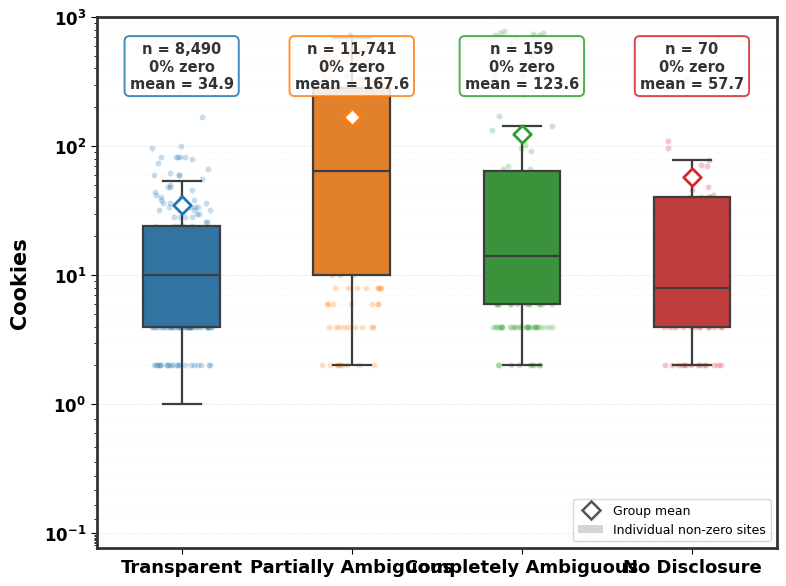

✓ DONE


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

# ============================================================
# BROAD GROUP MAPPING
# ============================================================
broad_map_4 = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
    "Class 8": "No Disclosure"
}

order_4 = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure"
]

plot_data = combined_data.copy()
plot_data["broad_group"] = plot_data["disclosure_group"].map(broad_map_4)

# ============================================================
# PER-GROUP STATS FOR ANNOTATIONS
# ============================================================
group_stats = {}
for grp in order_4:
    sub = plot_data[plot_data["broad_group"] == grp]["total_cookie_count"]
    group_stats[grp] = {
        "n":        len(sub),
        "pct_zero": 100 * (sub == 0).sum() / len(sub),
        "mean":     sub.mean(),
        "median":   sub.median(),
    }

# ============================================================
# COLORS
# ============================================================
palette = {
    "Transparent":           "#1f77b4",
    "Partially Ambiguous":  "#ff7f0e",
    "Completely Ambiguous": "#2ca02c",
    "No Disclosure":         "#d62728",
}

# ============================================================
# FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# ✅ FIXED: PURE WHITE BACKGROUND (LaTeX STYLE)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── 1. Boxplot ──
sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.6,
    width=0.45,
    ax=ax,
    zorder=3,
)

# ── 2. Strip-plot overlay (non-zero points only) ──
rng = np.random.default_rng(42)

for i, grp in enumerate(order_4):
    sub = plot_data[plot_data["broad_group"] == grp]["total_cookie_count"]
    nonzero = sub[sub > 0]

    if len(nonzero) > 200:
        nonzero = nonzero.sample(200, random_state=42)

    jitter = rng.uniform(-0.18, 0.18, size=len(nonzero))
    ax.scatter(
        i + jitter,
        nonzero,
        color=palette[grp],
        alpha=0.25,
        s=18,
        linewidths=0,
        zorder=2,
    )

# ── 3. Mean diamond markers ──
for i, grp in enumerate(order_4):
    mean_val = group_stats[grp]["mean"]
    if mean_val > 0:
        ax.scatter(
            i, mean_val,
            marker="D",
            color="white",
            edgecolors=palette[grp],
            s=80,
            linewidths=2.0,
            zorder=5,
        )

# ── 4. Annotations: n, % zeros, mean ──
for i, grp in enumerate(order_4):
    st = group_stats[grp]
    txt = (
        f"n = {st['n']:,}\n"
        f"{st['pct_zero']:.0f}% zero\n"
        f"mean = {st['mean']:.1f}"
    )
    ax.text(
        i, 650,
        txt,
        ha="center", va="top",
        fontsize=10.5,
        color="#333333",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=palette[grp],
            linewidth=1.4,
            alpha=0.85,
        ),
        zorder=6,
    )

# ── 5. Axes / scale ──
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 10**3)
ax.set_xlim(-0.5, 3.5)

ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
)
ax.grid(axis="y", which="major", linestyle="--", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(axis="y", which="minor", linestyle=":",  linewidth=0.4,
        color="#dddddd", zorder=0)

# ── 6. Labels & ticks ──
ax.set_ylabel("Cookies",
              fontsize=15, fontweight="bold", labelpad=10)
ax.set_xlabel("", fontsize=1)
ax.set_xticklabels(order_4, fontsize=13, fontweight="bold")
ax.tick_params(axis="y", which="both", labelsize=12)
for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ── 7. Legend ──
legend_elements = [
    Line2D([0], [0], marker="D", color="w",
           markerfacecolor="white", markeredgecolor="#555",
           markeredgewidth=1.8, markersize=9, label="Group mean"),
    mpatches.Patch(facecolor="#888", alpha=0.35, label="Individual non-zero sites"),
]

ax.legend(
    handles=legend_elements,
    fontsize=9,
    loc="lower right",
    framealpha=0.8,
    edgecolor="#cccccc",
)

plt.tight_layout()

# ✅ FIXED EXPORT BACKGROUND
plt.savefig("cookie_4_group_boxplot_v2.pdf", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("cookie_4_group_boxplot_v2.png", dpi=200, bbox_inches="tight", facecolor="white")

plt.show()
print("✓ DONE")

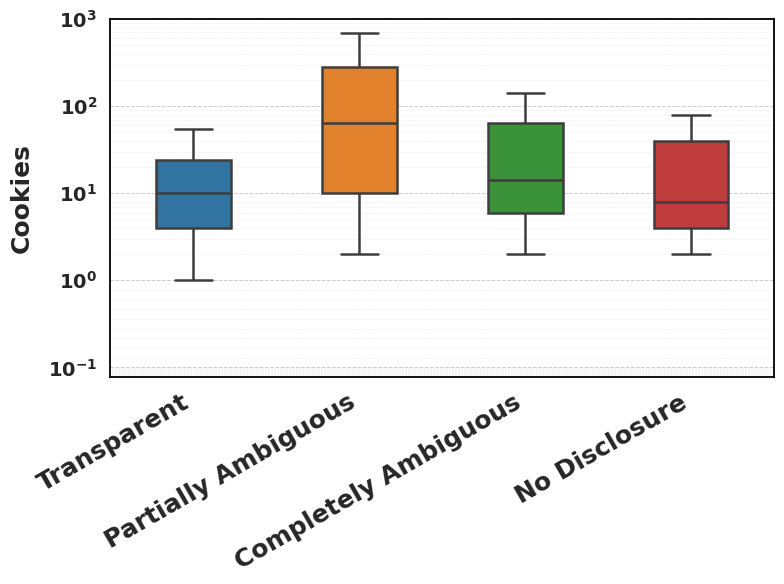

✓ DONE


In [82]:
# ============================================================
# FIGURE — CLEAN BOXPLOT ONLY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── Boxplot only ──
sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.8,
    width=0.45,
    ax=ax,
)

# ── Axes / scale ──
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 10**3)
ax.set_xlim(-0.5, 3.5)

ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
)

# Grid
ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.7,
    color="#cccccc",
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    color="#dddddd",
)

# ── Labels & ticks ──
ax.set_ylabel(
    "Cookies",
    fontsize=18,
    fontweight="bold",
    labelpad=10
)

ax.set_xlabel("")
# ax.set_xticklabels(order_4, fontsize=13, fontweight="bold")
ax.set_xticklabels(order_4, fontsize=18, fontweight="bold", rotation=30, ha='right')

ax.tick_params(axis="y", which="both", labelsize=14)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ── FULL BOUNDING BOX (top/right borders enabled) ──
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# ── Tight layout ──
plt.tight_layout()

# ── Export ──
plt.savefig(
    "cookie_broad_groups.pdf",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

# plt.savefig(
#     "cookie_4_group_boxplot_clean.png",
#     dpi=200,
#     bbox_inches="tight",
#     facecolor="white"
# )

plt.show()

print("✓ DONE")

/tmp/ipykernel_3521932/321418651.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3521932/321418651.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


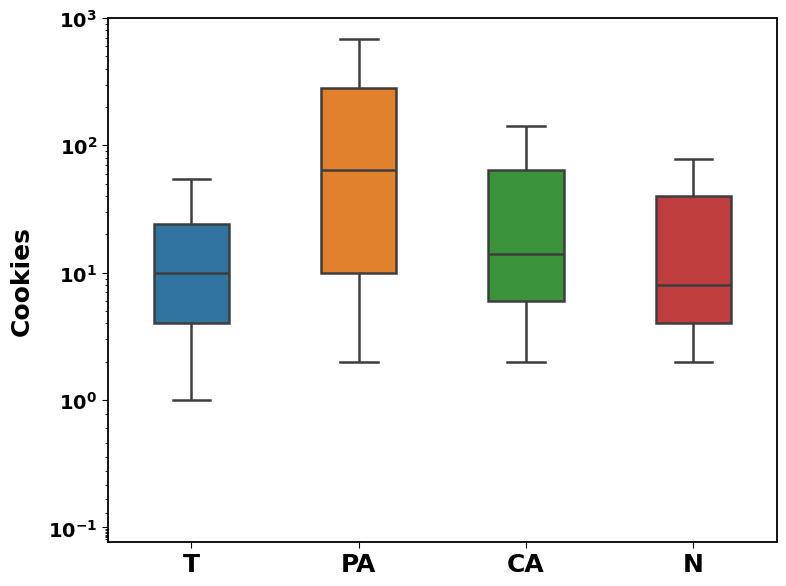

✓ DONE


In [ ]:
# ============================================================---------------------------
# FIGURE — CLEAN BOXPLOT ONLY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── Boxplot only ──
sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.8,
    width=0.45,
    ax=ax,
)

# ── Axes / scale ──
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 10**3)
ax.set_xlim(-0.5, 3.5)
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
)

ax.grid(False)
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_axisbelow(False)

# ── Labels & ticks ──
ax.set_ylabel("Cookies", fontsize=18, fontweight="bold", labelpad=10)
ax.set_xlabel("")
x_labels = ["T", "PA", "CA", "N"]

ax.set_xticklabels(
    x_labels,
    fontsize=18,
    fontweight="bold",
    rotation=0,
    ha="center"
)
ax.tick_params(axis="y", which="both", labelsize=14)
plt.draw()
for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")
    lbl.set_fontsize(14)

# ── FULL BOUNDING BOX ──
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_color("black")

# ── Tight layout ──
plt.tight_layout()

# ── Export ──
plt.savefig(
    "cookie_broad_groups.pdf",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
# plt.savefig(
#     "cookie_4_group_boxplot_clean.png",
#     dpi=200,
#     bbox_inches="tight",
#     facecolor="white",
#     edgecolor="none"
# )
plt.show()
print("✓ DONE")

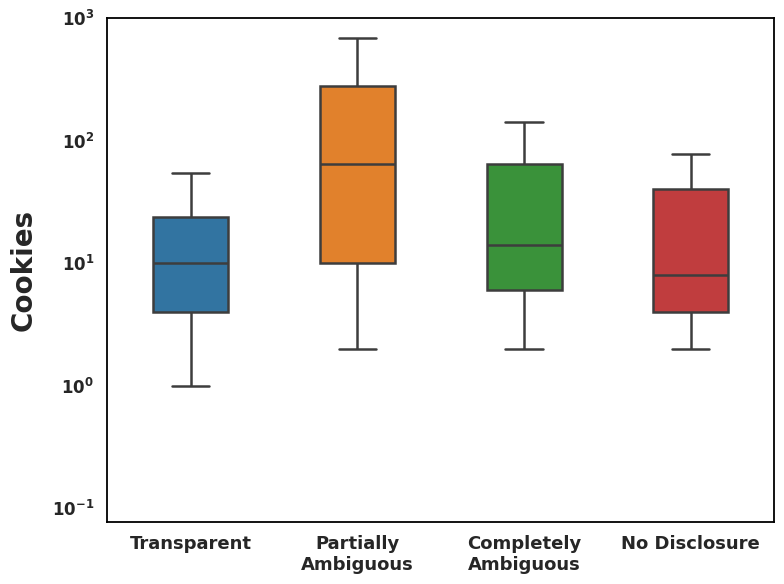

✓ DONE


In [58]:
# ============================================================
# FIGURE — CLEAN WHITE BOXPLOT (NO GRID)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Pure white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Remove seaborn gray styling
sns.set_style("white")

# ── Boxplot only ──
sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.8,
    width=0.45,
    ax=ax,
)

# ── Axes / scale ──
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 10**3)
ax.set_xlim(-0.5, 3.5)

ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
)

# ❌ Remove all grid/jitter lines
ax.grid(False)

# ── Labels & ticks ──
ax.set_ylabel(
    "Cookies",
    fontsize=20,
    fontweight="bold",
    labelpad=10
)

ax.set_xlabel("")

ax.set_xticklabels(
    order_4,
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="y",
    which="both",
    labelsize=12
)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ── Full black border around plot ──
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# Ensure fully opaque white background
ax.patch.set_alpha(1.0)
fig.patch.set_alpha(1.0)

# ── Tight layout ──
plt.tight_layout()

# ── Export ──
plt.savefig(
    "cookie_broad_groups.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white"
)


plt.show()

print("✓ DONE")

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
import gc
import os

# Define colors for the groups
colors = plt.cm.tab20.colors





def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""

    if domain in class_1:
        return 1
    if domain in class_2:
        return 2
    if domain in class_3:
        return 3
    if domain in class_4:
        return 4
    if domain in class_5:
        return 5
    if domain in class_6:
        return 6
    if domain in class_7:
        return 7
    if domain in class_8:
        return 8
    return None


In [68]:
df_2 = pd.read_csv('Accept/js.csv')

In [69]:
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl


json_data = download_disconnect_list()
if json_data :
    df_2 = apply_disconnect_categories_to_dataframe(df_2, domain_column='domain_script_url')

✓ Downloaded Disconnect list


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
import gc
import os

# Define colors for the groups
colors = plt.cm.tab20.colors
def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""

    if domain in class_1:
        return 1
    if domain in class_2:
        return 2
    if domain in class_3:
        return 3
    if domain in class_4:
        return 4
    if domain in class_5:
        return 5
    if domain in class_6:
        return 6
    if domain in class_7:
        return 7
    if domain in class_8:
        return 8
    return None


def process_single_file(df_j):


    # Load one file
    df_javascript = df_j
    print(f"  Loaded {len(df_javascript)} rows")

    # Filter for relevant stages and fingerprinting scripts
    df_javascript_accept = df_javascript[df_javascript['clicked_stage'].isin([
        'After Interaction (Accept)',
    ])]

    df_javascript_accept = df_javascript_accept[
        (df_javascript_accept['AllList'] == True) &
        ((df_javascript_accept['FingerprintingInvasive'] == True) |
         (df_javascript_accept['FingerprintingGeneral'] == True)) &
        (df_javascript_accept['domain_script_url'] != df_javascript_accept['domain'])

    ]

    print(f"  After filtering: {len(df_javascript_accept)} rows")

    # Assign disclosure group
    df_javascript_accept['disclosure_group'] = df_javascript_accept['domain'].apply(assign_disclosure_group)
    df_javascript_accept = df_javascript_accept[df_javascript_accept['disclosure_group'].notnull()]

    print(f"  After disclosure assignment: {len(df_javascript_accept)} rows")

    # Extract unique scripts from this file
    scripts_this_file = df_javascript_accept[
        ['disclosure_group', 'domain', 'host_url']
    ].drop_duplicates()

    print(f"  Unique scripts in this file: {len(scripts_this_file)}")


    return scripts_this_file



# ============================================================
# MAIN PROCESSING LOOP
# ============================================================





Total unique scripts across all files: 219441

Total zero entries: 13117

Number of zero entries per class:
  - Class 2: 8566
  - Class 5: 3222
  - Class 4: 999
  - Class 7: 175
  - Class 1: 113
  - Class 6: 37
  - Class 3: 5

Descriptive Statistics:
                    count       Mean    Std Dev  Min  Median    Max
disclosure_group                                                   
Class 1             478.0  14.020921  15.517610  0.0     9.0   82.0
Class 2           16774.0   2.137236   4.837539  0.0     0.0   64.0
Class 3               5.0   0.000000   0.000000  0.0     0.0    0.0
Class 4            8468.0  17.660250  14.084710  0.0    16.0  107.0
Class 5            7000.0   2.949000   6.297374  0.0     1.0   66.0
Class 6             350.0  13.742857  11.013258  0.0    12.0   55.0
Class 7             324.0   3.820988   8.636738  0.0     0.0   52.0
Class 8              95.0   6.852632   9.024751  1.0     3.0   39.0

Combined Median Analysis (Broad Groups):
 → Transparent (1,2,3): Med

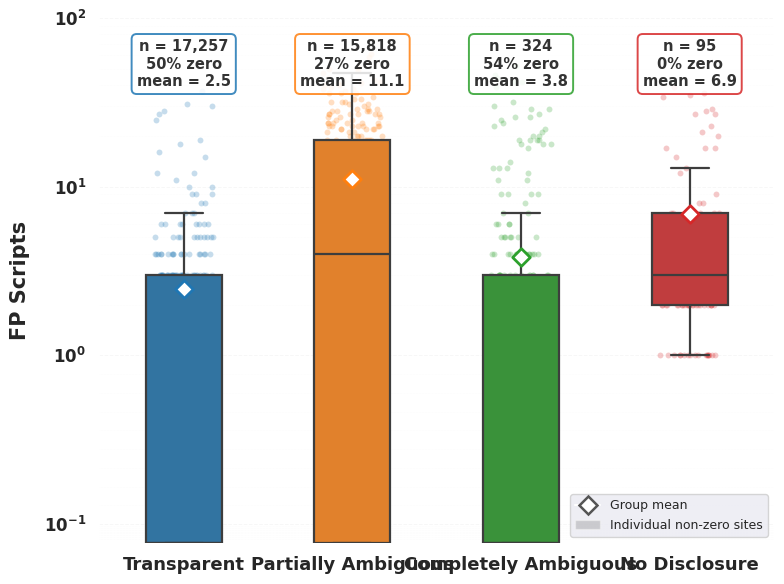

✓ DONE


In [71]:

all_scripts_unique = js_from_file
print(f"Total unique scripts across all files: {len(all_scripts_unique)}")

# Assign disclosure group based on class lists
# all_scripts_unique['disclosure_group'] = all_scripts_unique['domain'].apply(assign_disclosure_group)

# Map class numbers to readable names (optional)
class_mapping = {
    1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
    5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8",
    None: "Unassigned"
}
all_scripts_unique['disclosure_group'] = all_scripts_unique['disclosure_group'].map(class_mapping)

# Count scripts per domain
request_counts = all_scripts_unique.groupby(
    ['disclosure_group', 'domain', 'host_url']
).size().reset_index(name='request_count')

combined_data = request_counts.groupby(
    ['disclosure_group', 'domain']
)['request_count'].sum().reset_index(name='total_request_count')



# Add missing domains with request_count = 0 for each class
def create_zero_entries(domain_list, class_num):
    missing_domains = list(
        set(domain_list) - set(combined_data[combined_data['disclosure_group'] == f"Class {class_num}"]['domain'])
    )
    return pd.DataFrame({
        'disclosure_group': [f"Class {class_num}"] * len(missing_domains),
        'domain': missing_domains,
        'total_request_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(class_1, 1),
    create_zero_entries(class_2, 2),
    create_zero_entries(class_3, 3),
    create_zero_entries(class_4, 4),
    create_zero_entries(class_5, 5),
    create_zero_entries(class_6, 6),
    create_zero_entries(class_7, 7),

], ignore_index=True)

print(f"\nTotal zero entries: {len(zero_entries)}")

# Print zero entries statistics
group_counts = zero_entries['disclosure_group'].value_counts()
print("\nNumber of zero entries per class:")
for group, count in group_counts.items():
    print(f"  - {group}: {count}")

combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)
combined_data_scripts = combined_data.copy()

# Compute descriptive statistics
stats = combined_data.groupby("disclosure_group")["total_request_count"].describe()
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nDescriptive Statistics:")
print(stats)
# ============================================================
# EXTRA ANALYSIS — COMBINED MEDIANS FOR BROAD GROUPS
# ============================================================

print("\nCombined Median Analysis (Broad Groups):")

# Transparent: Classes 1, 2, 3
transparent_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 1", "Class 2", "Class 3"])
]['total_request_count'].median()

# Partially Ambiguous: Classes 4, 5, 6
partially_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6"])
]['total_request_count'].median()

# Completely Ambiguous: Class 7
complete_median = combined_data[
    combined_data['disclosure_group'] == "Class 7"
]['total_request_count'].median()

# Completely Ambiguous: Class 7
no_disclosure_median = combined_data[
    combined_data['disclosure_group'] == "Class 8"
]['total_request_count'].median()

# Ambiguous overall: 4,5,6,7
ambiguous_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6", "Class 7"])
]['total_request_count'].median()

print(f" → Transparent (1,2,3): Median = {transparent_median}")
print(f" → Partially Ambiguous (4,5,6): Median = {partially_median}")
print(f" → Completely Ambiguous (7): Median = {complete_median}")
print(f" → No Disclsoure (8): Median = {no_disclosure_median}")
print(f" → Ambiguous All (4,5,6,7): Median = {ambiguous_median}")
print("============================================================\n")



# Print sorted values for each class
for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[
        combined_data['disclosure_group'] == group
    ]['total_request_count'].sort_values()
    print(f"\n{group} total_request_count values:\n{group_values.values}\n")

## ============================================================
# 4-GROUP FP SCRIPT VISUALIZATION (MATCHING COOKIE STYLE)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

# ============================================================
# BROAD GROUP MAPPING
# ============================================================

broad_map_4 = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
    "Class 8": "No Disclosure"
}

order_4 = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure"
]

# ============================================================
# PREPARE PLOT DATA
# ============================================================

plot_data = combined_data.copy()
plot_data["broad_group"] = plot_data["disclosure_group"].map(broad_map_4)

# ============================================================
# PER-GROUP STATS FOR ANNOTATIONS
# ============================================================

group_stats = {}

for grp in order_4:
    sub = plot_data[
        plot_data["broad_group"] == grp
    ]["total_request_count"]

    group_stats[grp] = {
        "n": len(sub),
        "pct_zero": 100 * (sub == 0).sum() / len(sub),
        "mean": sub.mean(),
        "median": sub.median(),
    }

# ============================================================
# COLORS
# ============================================================

palette = {
    "Transparent": "#1f77b4",
    "Partially Ambiguous": "#ff7f0e",
    "Completely Ambiguous": "#2ca02c",
    "No Disclosure": "#d62728",
}

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Pure white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# 1. BOXPLOT
# ============================================================

sns.boxplot(
    x="broad_group",
    y="total_request_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.6,
    width=0.45,
    ax=ax,
    zorder=3,
)

# ============================================================
# 2. STRIP-PLOT OVERLAY (NON-ZERO ONLY)
# ============================================================

rng = np.random.default_rng(42)

for i, grp in enumerate(order_4):

    sub = plot_data[
        plot_data["broad_group"] == grp
    ]["total_request_count"]

    nonzero = sub[sub > 0]

    # Downsample if too many points
    if len(nonzero) > 200:
        nonzero = nonzero.sample(200, random_state=42)

    jitter = rng.uniform(-0.18, 0.18, size=len(nonzero))

    ax.scatter(
        i + jitter,
        nonzero,
        color=palette[grp],
        alpha=0.25,
        s=18,
        linewidths=0,
        zorder=2,
    )

# ============================================================
# 3. MEAN DIAMOND MARKERS
# ============================================================

for i, grp in enumerate(order_4):

    mean_val = group_stats[grp]["mean"]

    if mean_val > 0:
        ax.scatter(
            i,
            mean_val,
            marker="D",
            color="white",
            edgecolors=palette[grp],
            s=80,
            linewidths=2.0,
            zorder=5,
        )

# ============================================================
# 4. STATISTICS ANNOTATIONS
# ============================================================

for i, grp in enumerate(order_4):

    st = group_stats[grp]

    txt = (
        f"n = {st['n']:,}\n"
        f"{st['pct_zero']:.0f}% zero\n"
        f"mean = {st['mean']:.1f}"
    )

    ax.text(
        i,
        75,   # adjust depending on your data scale
        txt,
        ha="center",
        va="top",
        fontsize=10.5,
        color="#333333",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=palette[grp],
            linewidth=1.4,
            alpha=0.85,
        ),
        zorder=6,
    )

# ============================================================
# 5. AXES / SCALE
# ============================================================

ax.set_yscale("symlog", linthresh=1)

# Adjust based on your FP script distribution
ax.set_ylim(0, 10**2)

ax.set_xlim(-0.5, 3.5)

ax.yaxis.set_major_locator(
    LogLocator(base=10.0, numticks=6)
)

ax.yaxis.set_minor_locator(
    LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=12
    )
)

# Grid styling
ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.7,
    color="#cccccc",
    zorder=0
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    color="#dddddd",
    zorder=0
)

# ============================================================
# 6. LABELS & TICKS
# ============================================================

ax.set_ylabel(
    "FP Scripts",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.set_xlabel("", fontsize=1)

ax.set_xticklabels(
    order_4,
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="y",
    which="both",
    labelsize=12
)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ============================================================
# 7. LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        marker="D",
        color="w",
        markerfacecolor="white",
        markeredgecolor="#555",
        markeredgewidth=1.8,
        markersize=9,
        label="Group mean"
    ),

    mpatches.Patch(
        facecolor="#888",
        alpha=0.35,
        label="Individual non-zero sites"
    ),
]

ax.legend(
    handles=legend_elements,
    fontsize=9,
    loc="lower right",
    framealpha=0.8,
    edgecolor="#cccccc",
)

# ============================================================
# FINALIZE
# ============================================================

plt.tight_layout()

plt.savefig(
    "fp_scripts_4_group_boxplot_v2.pdf",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "fp_scripts_4_group_boxplot_v2.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✓ DONE")

In [66]:


all_scripts_unique = js_from_file
print(f"Total unique scripts across all files: {len(all_scripts_unique)}")

# Assign disclosure group based on class lists
# all_scripts_unique['disclosure_group'] = all_scripts_unique['domain'].apply(assign_disclosure_group)

# Map class numbers to readable names (optional)
class_mapping = {
    1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
    5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8",
    None: "Unassigned"
}
all_scripts_unique['disclosure_group'] = all_scripts_unique['disclosure_group'].map(class_mapping)

# Count scripts per domain
request_counts = all_scripts_unique.groupby(
    ['disclosure_group', 'domain', 'host_url']
).size().reset_index(name='request_count')

combined_data = request_counts.groupby(
    ['disclosure_group', 'domain']
)['request_count'].sum().reset_index(name='total_request_count')



# Add missing domains with request_count = 0 for each class
def create_zero_entries(domain_list, class_num):
    missing_domains = list(
        set(domain_list) - set(combined_data[combined_data['disclosure_group'] == f"Class {class_num}"]['domain'])
    )
    return pd.DataFrame({
        'disclosure_group': [f"Class {class_num}"] * len(missing_domains),
        'domain': missing_domains,
        'total_request_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(class_1, 1),
    create_zero_entries(class_2, 2),
    create_zero_entries(class_3, 3),
    create_zero_entries(class_4, 4),
    create_zero_entries(class_5, 5),
    create_zero_entries(class_6, 6),
    create_zero_entries(class_7, 7),

], ignore_index=True)

print(f"\nTotal zero entries: {len(zero_entries)}")

# Print zero entries statistics
group_counts = zero_entries['disclosure_group'].value_counts()
print("\nNumber of zero entries per class:")
for group, count in group_counts.items():
    print(f"  - {group}: {count}")

combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)
combined_data_scripts = combined_data.copy()

# Compute descriptive statistics
stats = combined_data.groupby("disclosure_group")["total_request_count"].describe()
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nDescriptive Statistics:")
print(stats)
# ============================================================
# EXTRA ANALYSIS — COMBINED MEDIANS FOR BROAD GROUPS
# ============================================================

print("\nCombined Median Analysis (Broad Groups):")

# Transparent: Classes 1, 2, 3
transparent_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 1", "Class 2", "Class 3"])
]['total_request_count'].median()

# Partially Ambiguous: Classes 4, 5, 6
partially_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6"])
]['total_request_count'].median()

# Completely Ambiguous: Class 7
complete_median = combined_data[
    combined_data['disclosure_group'] == "Class 7"
]['total_request_count'].median()

# Completely Ambiguous: Class 7
no_disclosure_median = combined_data[
    combined_data['disclosure_group'] == "Class 8"
]['total_request_count'].median()

# Ambiguous overall: 4,5,6,7
ambiguous_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6", "Class 7"])
]['total_request_count'].median()

print(f" → Transparent (1,2,3): Median = {transparent_median}")
print(f" → Partially Ambiguous (4,5,6): Median = {partially_median}")
print(f" → Completely Ambiguous (7): Median = {complete_median}")
print(f" → No Disclsoure (8): Median = {no_disclosure_median}")
print(f" → Ambiguous All (4,5,6,7): Median = {ambiguous_median}")
print("============================================================\n")



# Print sorted values for each class
for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[
        combined_data['disclosure_group'] == group
    ]['total_request_count'].sort_values()
    print(f"\n{group} total_request_count values:\n{group_values.values}\n")

## ============================================================
# 4-GROUP FP SCRIPT VISUALIZATION (MATCHING COOKIE STYLE)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

# ============================================================
# BROAD GROUP MAPPING
# ============================================================

broad_map_4 = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
    "Class 8": "No Disclosure"
}

order_4 = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure"
]

# ============================================================
# PREPARE PLOT DATA
# ============================================================

plot_data = combined_data.copy()
plot_data["broad_group"] = plot_data["disclosure_group"].map(broad_map_4)

# ============================================================
# PER-GROUP STATS FOR ANNOTATIONS
# ============================================================

group_stats = {}

for grp in order_4:
    sub = plot_data[
        plot_data["broad_group"] == grp
    ]["total_request_count"]

    group_stats[grp] = {
        "n": len(sub),
        "pct_zero": 100 * (sub == 0).sum() / len(sub),
        "mean": sub.mean(),
        "median": sub.median(),
    }

# ============================================================
# COLORS
# ============================================================

palette = {
    "Transparent": "#1f77b4",
    "Partially Ambiguous": "#ff7f0e",
    "Completely Ambiguous": "#2ca02c",
    "No Disclosure": "#d62728",
}

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Pure white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# 1. BOXPLOT
# ============================================================

sns.boxplot(
    x="broad_group",
    y="total_request_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.6,
    width=0.45,
    ax=ax,
    zorder=3,
)

# ============================================================
# 2. STRIP-PLOT OVERLAY (NON-ZERO ONLY)
# ============================================================

rng = np.random.default_rng(42)

for i, grp in enumerate(order_4):

    sub = plot_data[
        plot_data["broad_group"] == grp
    ]["total_request_count"]

    nonzero = sub[sub > 0]

    # Downsample if too many points
    if len(nonzero) > 200:
        nonzero = nonzero.sample(200, random_state=42)

    jitter = rng.uniform(-0.18, 0.18, size=len(nonzero))

    ax.scatter(
        i + jitter,
        nonzero,
        color=palette[grp],
        alpha=0.25,
        s=18,
        linewidths=0,
        zorder=2,
    )

# ============================================================
# 3. MEAN DIAMOND MARKERS
# ============================================================

for i, grp in enumerate(order_4):

    mean_val = group_stats[grp]["mean"]

    if mean_val > 0:
        ax.scatter(
            i,
            mean_val,
            marker="D",
            color="white",
            edgecolors=palette[grp],
            s=80,
            linewidths=2.0,
            zorder=5,
        )

# ============================================================
# 4. STATISTICS ANNOTATIONS
# ============================================================

for i, grp in enumerate(order_4):

    st = group_stats[grp]

    txt = (
        f"n = {st['n']:,}\n"
        f"{st['pct_zero']:.0f}% zero\n"
        f"mean = {st['mean']:.1f}"
    )

    ax.text(
        i,
        75,   # adjust depending on your data scale
        txt,
        ha="center",
        va="top",
        fontsize=10.5,
        color="#333333",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor=palette[grp],
            linewidth=1.4,
            alpha=0.85,
        ),
        zorder=6,
    )

# ============================================================
# 5. AXES / SCALE
# ============================================================

ax.set_yscale("symlog", linthresh=1)

# Adjust based on your FP script distribution
ax.set_ylim(0, 10**2)

ax.set_xlim(-0.5, 3.5)

ax.yaxis.set_major_locator(
    LogLocator(base=10.0, numticks=6)
)

ax.yaxis.set_minor_locator(
    LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=12
    )
)

# Grid styling
ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.7,
    color="#cccccc",
    zorder=0
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    color="#dddddd",
    zorder=0
)

# ============================================================
# 6. LABELS & TICKS
# ============================================================

ax.set_ylabel(
    "FP Scripts",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.set_xlabel("", fontsize=1)

ax.set_xticklabels(
    order_4,
    fontsize=13,
    fontweight="bold"
)

ax.tick_params(
    axis="y",
    which="both",
    labelsize=12
)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ============================================================
# 7. LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        marker="D",
        color="w",
        markerfacecolor="white",
        markeredgecolor="#555",
        markeredgewidth=1.8,
        markersize=9,
        label="Group mean"
    ),

    mpatches.Patch(
        facecolor="#888",
        alpha=0.35,
        label="Individual non-zero sites"
    ),
]

ax.legend(
    handles=legend_elements,
    fontsize=9,
    loc="lower right",
    framealpha=0.8,
    edgecolor="#cccccc",
)

# ============================================================
# FINALIZE
# ============================================================

plt.tight_layout()

plt.savefig(
    "fp_scripts_4_group_boxplot_v2.pdf",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "fp_scripts_4_group_boxplot_v2.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✓ DONE")

Total unique scripts across all files: 219441

Total zero entries: 33399

Number of zero entries per class:
  - Class 2: 16774
  - Class 4: 8468
  - Class 5: 7000
  - Class 1: 478
  - Class 6: 350
  - Class 7: 324
  - Class 3: 5

Descriptive Statistics:
                    count  Mean  Std Dev  Min  Median  Max
disclosure_group                                          
Class 1             478.0   0.0      0.0  0.0     0.0  0.0
Class 2           16774.0   0.0      0.0  0.0     0.0  0.0
Class 3               5.0   0.0      0.0  0.0     0.0  0.0
Class 4            8468.0   0.0      0.0  0.0     0.0  0.0
Class 5            7000.0   0.0      0.0  0.0     0.0  0.0
Class 6             350.0   0.0      0.0  0.0     0.0  0.0
Class 7             324.0   0.0      0.0  0.0     0.0  0.0

Combined Median Analysis (Broad Groups):
 → Transparent (1,2,3): Median = 0.0
 → Partially Ambiguous (4,5,6): Median = 0.0
 → Completely Ambiguous (7): Median = 0.0
 → No Disclsoure (8): Median = nan
 → Ambiguous A

ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7fa1da0411f0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x600 with 1 Axes>

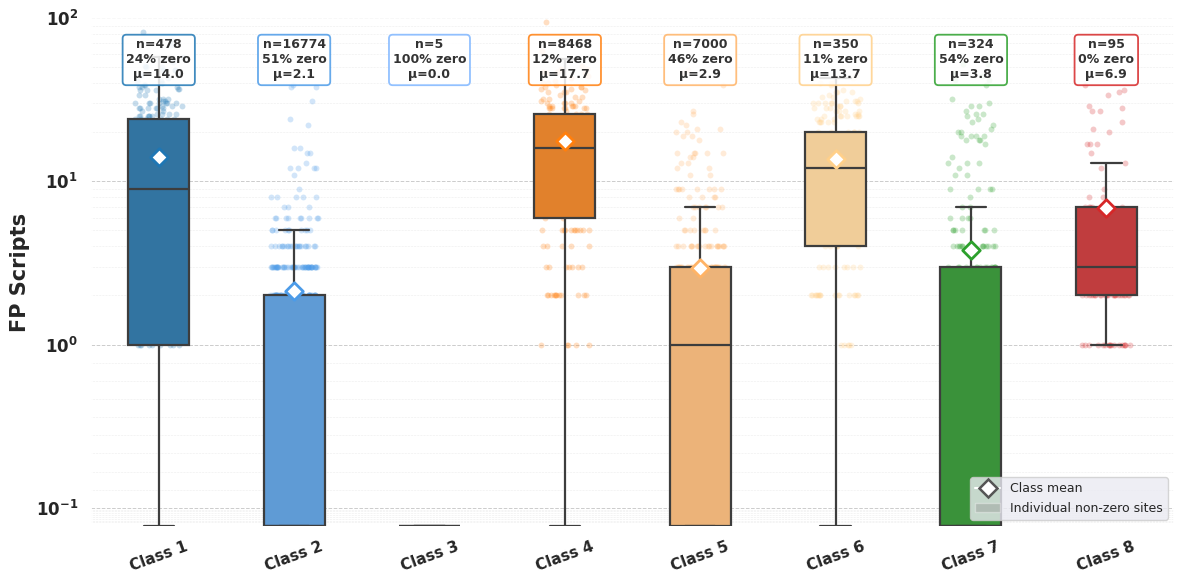

✓ DONE


In [ ]:
# ============================================================
# 8-CLASS FP SCRIPT VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

# ============================================================
# ORDER
# ============================================================

order_8 = [
    "Class 1",
    "Class 2",
    "Class 3",
    "Class 4",
    "Class 5",
    "Class 6",
    "Class 7",
    "Class 8"
]

# ============================================================
# PREPARE DATA
# ============================================================

plot_data = combined_data.copy()

# ============================================================
# PER-CLASS STATS
# ============================================================

group_stats = {}

for grp in order_8:

    sub = plot_data[
        plot_data["disclosure_group"] == grp
    ]["total_request_count"]

    group_stats[grp] = {
        "n": len(sub),
        "pct_zero": 100 * (sub == 0).sum() / len(sub),
        "mean": sub.mean(),
        "median": sub.median()
    }

# ============================================================
# COLORS
# ============================================================

palette = {
    "Class 1": "#1f77b4",
    "Class 2": "#4c9be8",
    "Class 3": "#7fb6ff",
    "Class 4": "#ff7f0e",
    "Class 5": "#ffb366",
    "Class 6": "#ffd08a",
    "Class 7": "#2ca02c",
    "Class 8": "#d62728",
}

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# BOXPLOT
# ============================================================

sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=plot_data,
    order=order_8,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.6,
    width=0.45,
    ax=ax,
    zorder=3,
)

# ============================================================
# STRIP OVERLAY
# ============================================================

rng = np.random.default_rng(42)

for i, grp in enumerate(order_8):

    sub = plot_data[
        plot_data["disclosure_group"] == grp
    ]["total_request_count"]

    nonzero = sub[sub > 0]

    if len(nonzero) > 200:
        nonzero = nonzero.sample(
            200,
            random_state=42
        )

    jitter = rng.uniform(
        -0.18,
        0.18,
        len(nonzero)
    )

    ax.scatter(
        i + jitter,
        nonzero,
        color=palette[grp],
        alpha=0.25,
        s=18,
        linewidths=0,
        zorder=2,
    )

# ============================================================
# MEAN MARKERS
# ============================================================

for i, grp in enumerate(order_8):

    mean_val = group_stats[grp]["mean"]

    if mean_val > 0:

        ax.scatter(
            i,
            mean_val,
            marker="D",
            color="white",
            edgecolors=palette[grp],
            s=80,
            linewidths=2,
            zorder=5,
        )

# ============================================================
# ANNOTATIONS
# ============================================================

for i, grp in enumerate(order_8):

    st = group_stats[grp]

    txt = (
        f"n={st['n']}\n"
        f"{st['pct_zero']:.0f}% zero\n"
        f"μ={st['mean']:.1f}"
    )

    ax.text(
        i,
        75,
        txt,
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold",
        color="#333333",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor=palette[grp],
            linewidth=1.3,
            alpha=0.85,
        ),
        zorder=6
    )

# ============================================================
# AXES
# ============================================================
ax.set_yscale(
    "symlog",
    linthresh=1
)
ax.set_ylim(
    0,
    10**2
)
ax.set_xlim(
    -0.5,
    7.5
)
ax.yaxis.set_major_locator(
    LogLocator(
        base=10,
        numticks=6
    )
)
ax.yaxis.set_minor_locator(
    LogLocator(
        base=10,
        subs=np.arange(2,10)*0.1,
        numticks=12
    )
)
# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.7,
    color="#cccccc",
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.4,
    color="#dddddd",
)

# ============================================================
# LABELS
# ============================================================

ax.set_ylabel(
    "FP Scripts",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("")

ax.set_xticklabels(
    order_8,
    fontsize=11,
    fontweight="bold",
    rotation=20
)

ax.tick_params(
    axis="y",
    labelsize=12
)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0],
        [0],
        marker="D",
        color="w",
        markerfacecolor="white",
        markeredgecolor="#555",
        markeredgewidth=1.8,
        markersize=9,
        label="Class mean"
    ),

    mpatches.Patch(
        facecolor="#888",
        alpha=0.35,
        label="Individual non-zero sites"
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    framealpha=0.8
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    "fp_scripts_8_class_boxplot.pdf",
    dpi=200,
    bbox_inches="tight"
)

plt.savefig(
    "fp_scripts_8_class_boxplot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✓ DONE")

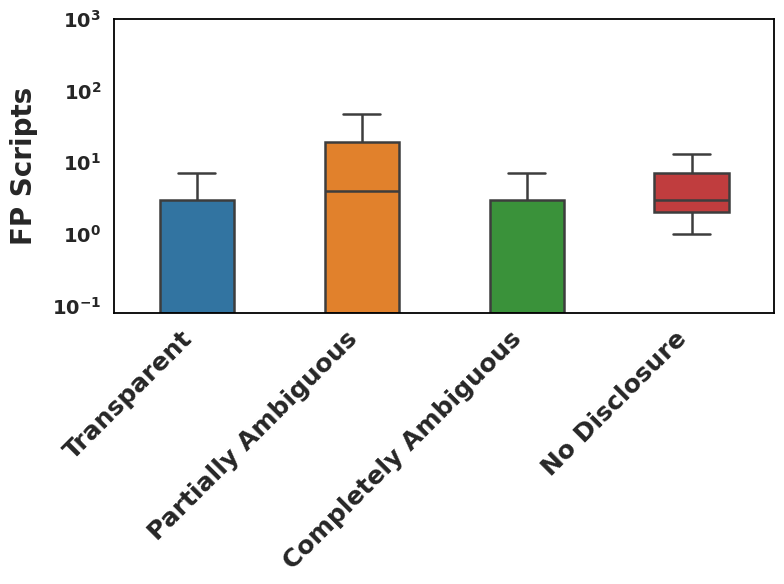

✓ DONE


In [72]:
# ============================================================
# FIGURE — CLEAN BOXPLOT ONLY
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ── Boxplot only ──
sns.boxplot(
    x="broad_group",
    y="total_request_count",
    data=plot_data,
    order=order_4,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.75,
    linewidth=1.8,
    width=0.45,
    ax=ax,
)

# ── Axes / scale ──
ax.set_yscale("symlog", linthresh=1)
ax.set_ylim(0, 10**3)
ax.set_xlim(-0.5, 3.5)
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12)
)

# ── NO grid lines ──
ax.grid(False)
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_axisbelow(False)

# ── Labels & ticks ──
ax.set_ylabel("FP Scripts", fontsize=20, fontweight="bold", labelpad=10)
ax.set_xlabel("")
ax.set_xticklabels(order_4, fontsize=18, fontweight="bold", rotation=45, ha='right')
ax.tick_params(axis="y", which="both", labelsize=14)
plt.draw()
for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")
    lbl.set_fontsize(14)

# ── FULL BOUNDING BOX ──
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("black")

# ── Tight layout ──
plt.tight_layout()

# ── Export ──
plt.savefig(
    "fingerprinting_scripts_broad_groups.pdf",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
plt.savefig(
    "fingerprinting_scripts_broad_groups.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
plt.show()
print("✓ DONE")

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

order_8 = [
    "Class 1",
    "Class 2",
    "Class 3",
    "Class 4",
    "Class 5",
    "Class 6",
    "Class 7",
    "Class 8",
]

display_labels = [
    "C",
    "F",
    "C,F",
    "V,C",
    "V,F",
    "V,C,F",
    "V",
    "N"
]


palette = {
    "Class 1": "#1f77b4",
    "Class 2": "#4e79a7",
    "Class 3": "#76b7b2",

    "Class 4": "#f28e2b",
    "Class 5": "#ff9d9a",
    "Class 6": "#edc948",

    "Class 7": "#59a14f",

    "Class 8": "#d62728",
}

# ============================================================
# PREPARE DATA
# ============================================================

plot_data = combined_data.copy()

# ============================================================
# GROUP STATS
# ============================================================

group_stats = {}

for grp in order_8:

    sub = plot_data[
        plot_data["disclosure_group"] == grp
    ]["total_request_count"]

    group_stats[grp] = {
        "n": len(sub),
        "pct_zero": 100 * (sub == 0).sum() / len(sub),
        "mean": sub.mean(),
        "median": sub.median(),
    }

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6.5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# 1. BOXPLOT
# ============================================================

sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=plot_data,
    order=order_8,
    palette=palette,
    showfliers=False,
    showmeans=False,
    saturation=0.78,
    linewidth=1.6,
    width=0.48,
    ax=ax,
    zorder=3,
)

# ============================================================
# 2. STRIP-PLOT OVERLAY
# ============================================================

rng = np.random.default_rng(42)

for i, grp in enumerate(order_8):

    sub = plot_data[
        plot_data["disclosure_group"] == grp
    ]["total_request_count"]

    nonzero = sub[sub > 0]

    # Downsample large groups
    if len(nonzero) > 180:
        nonzero = nonzero.sample(180, random_state=42)

    jitter = rng.uniform(-0.18, 0.18, size=len(nonzero))

    ax.scatter(
        i + jitter,
        nonzero,
        color=palette[grp],
        alpha=0.23,
        s=16,
        linewidths=0,
        zorder=2,
    )

# ============================================================
# 3. MEAN DIAMOND MARKERS
# ============================================================

for i, grp in enumerate(order_8):

    mean_val = group_stats[grp]["mean"]

    if mean_val > 0:

        ax.scatter(
            i,
            mean_val,
            marker="D",
            color="white",
            edgecolors=palette[grp],
            s=78,
            linewidths=2.0,
            zorder=5,
        )

# ============================================================
# 4. STATISTICS ANNOTATIONS
# ============================================================

for i, grp in enumerate(order_8):

    st = group_stats[grp]

    txt = (
        f"n={st['n']:,}\n"
        f"{st['pct_zero']:.0f}% zero\n"
        f"μ={st['mean']:.1f}"
    )

    ax.text(
        i,
        78,
        txt,
        ha="center",
        va="top",
        fontsize=9.3,
        color="#333333",
        fontweight="bold",

        bbox=dict(
            boxstyle="round,pad=0.32",
            facecolor="white",
            edgecolor=palette[grp],
            linewidth=1.25,
            alpha=0.88,
        ),

        zorder=6,
    )

# ============================================================
# 5. AXES / SCALE
# ============================================================

ax.set_yscale("symlog", linthresh=1)

ax.set_ylim(0, 10**2)

ax.set_xlim(-0.55, 7.55)

# Major ticks
ax.yaxis.set_major_locator(
    LogLocator(base=10.0, numticks=6)
)

# Minor ticks
ax.yaxis.set_minor_locator(
    LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=12
    )
)

# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.72,
    color="#cccccc",
    zorder=0,
)

ax.grid(
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.42,
    color="#dddddd",
    zorder=0,
)

# ============================================================
# LABELS & TICKS
# ============================================================

ax.set_ylabel(
    "FP Scripts",
    fontsize=16,
    fontweight="bold",
    labelpad=12
)

ax.set_xlabel("")

# Replace tick labels
ax.set_xticklabels(
    display_labels,
    fontsize=14,
    fontweight="bold"
)

# Y ticks
ax.tick_params(
    axis="y",
    which="both",
    labelsize=12
)

for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")

# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Line2D(
        [0], [0],
        marker="D",
        color="w",
        markerfacecolor="white",
        markeredgecolor="#555",
        markeredgewidth=1.8,
        markersize=9,
        label="Group mean"
    ),

    mpatches.Patch(
        facecolor="#888",
        alpha=0.35,
        label="Individual non-zero sites"
    ),
]

ax.legend(
    handles=legend_elements,
    fontsize=10,
    loc="lower right",
    framealpha=0.82,
    edgecolor="#cccccc",
)

# ============================================================
# FINALIZE
# ============================================================

plt.tight_layout()

plt.savefig(
    "fp_scripts_8_class_boxplot.pdf",
    dpi=250,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "fp_scripts_8_class_boxplot.png",
    dpi=250,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✓ DONE")

KeyError: 'total_request_count'

✓ Downloaded Disconnect list
###########REJECT/Germany

Number of sites with no tracking cookies:
Transparent Disclosure: 713
Partially Ambiguous Disclosure: 698
Complete Ambiguous Disclosure: 29
No Disclosure: 20

Number of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:
Transparent Disclosure: 70
Partially Ambiguous Disclosure: 149
Complete Ambiguous Disclosure: 3
No Disclosure: 1
Done: Germany
###########REJECT/Brazil

Number of sites with no tracking cookies:
Transparent Disclosure: 645
Partially Ambiguous Disclosure: 335
Complete Ambiguous Disclosure: 21
No Disclosure: 27

Number of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:
Transparent Disclosure: 48
Partially Ambiguous Disclosure: 39
Complete Ambiguous Disclosure: 0
No Disclosure: 0
Done: Brazil
###########REJECT/South Africa

Number of sites with no tracking cookies:
Transparent Disclosure: 568
Partially Ambiguous Disclo

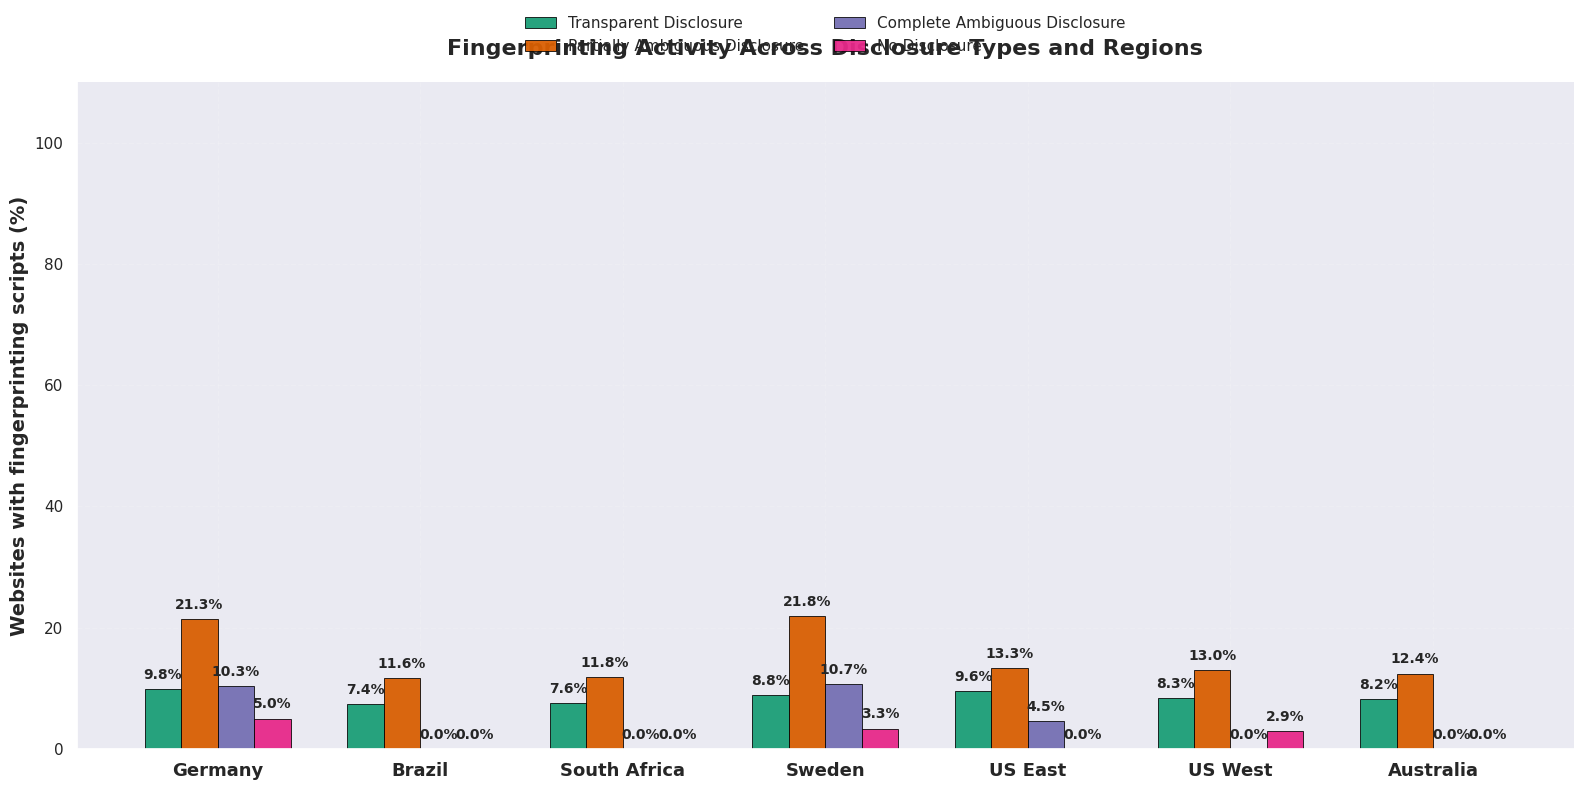

In [17]:
import pandas as pd
import json
import os
import requests
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict


# ============================================================
# CONFIG
# ============================================================
mode = "REJECT"

countries = ["Germany", "Brazil", "South Africa", "Sweden", "US East", "US West", "Australia"]
locations = [f"{mode}/{country}" for country in countries]

disclosure_groups = [
    "Transparent Disclosure",
    "Partially Ambiguous Disclosure",
    "Complete Ambiguous Disclosure",
    "No Disclosure",
]


# ============================================================
# DISCLOSURE GROUP FUNCTION (single-location, uses global sets)
# ============================================================
def assign_disclosure_group(domain):
    if domain in transparent_disclosure:
        return "Transparent Disclosure"
    elif domain in partially_ambiguous:
        return "Partially Ambiguous Disclosure"
    elif domain in complete_ambiguous:
        return "Complete Ambiguous Disclosure"
    elif domain in no_disclosure:
        return "No Disclosure"
    return "Unknown"


# ============================================================
# DISCLOSURE GROUP FUNCTION (multi-country, sets passed in)
# ============================================================
def assign_disclosure_group_country(domain, t, pa, ca, nd):
    if domain in t:
        return "Transparent Disclosure"
    elif domain in pa:
        return "Partially Ambiguous Disclosure"
    elif domain in ca:
        return "Complete Ambiguous Disclosure"
    elif domain in nd:
        return "No Disclosure"
    return "Unknown"


# ============================================================
# LOAD DISCLOSURE MAP PER COUNTRY
# ============================================================
def load_disclosure_sets(location):
    def read_csv_set(path):
        if os.path.exists(path):
            with open(path, "r") as f:
                return set(line.strip() for line in f.readlines())
        return set()

    return (
        read_csv_set(f"{location}/Transparent.csv"),
        read_csv_set(f"{location}/Partially_Ambiguous.csv"),
        read_csv_set(f"{location}/Completely_Ambiguous.csv"),
        read_csv_set(f"{location}/No_Disclosure.csv"),
    )


# ============================================================
# DISCONNECT DATA FUNCTIONS
# ============================================================
def download_disconnect_list():
    url = "https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json"
    print("Downloading Disconnect.me tracker list...")

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        json_data = response.json()

        os.makedirs("dataset_disconnect", exist_ok=True)
        output_file = "dataset_disconnect/services-relay-disconnect.json"

        with open(output_file, "w", encoding="utf-8") as f:
            json.dump(json_data, f, indent=2)

        print("✓ Downloaded Disconnect list")
        return json_data

    except Exception as e:
        print("Error:", e)
        return None


def extract_domains_from_category(category_list):
    domains = set()
    for item in category_list:
        for _, service_data in item.items():
            for _, domain_list in service_data.items():
                domains.update(domain_list)
    return domains


def load_and_process_disconnect_data(
    json_file="dataset_disconnect/services-relay-disconnect.json",
):
    with open(json_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    fp_invasive = extract_domains_from_category(
        data.get("categories", {}).get("FingerprintingInvasive", [])
    )
    fp_general = extract_domains_from_category(
        data.get("categories", {}).get("FingerprintingGeneral", [])
    )

    return fp_invasive, fp_general


def apply_disconnect_categories_to_dataframe(df, domain_column="domain_script_url"):
    try:
        fp_invasive, fp_general = load_and_process_disconnect_data()
    except FileNotFoundError:
        data = download_disconnect_list()
        fp_invasive = extract_domains_from_category(
            data.get("categories", {}).get("FingerprintingInvasive", [])
        )
        fp_general = extract_domains_from_category(
            data.get("categories", {}).get("FingerprintingGeneral", [])
        )

    df["FingerprintingInvasive"] = df[domain_column].isin(fp_invasive)
    df["FingerprintingGeneral"] = df[domain_column].isin(fp_general)

    return df


json_data = download_disconnect_list()

# ============================================================
# MULTI-COUNTRY ANALYSIS
# ============================================================
country_results = {g: [] for g in disclosure_groups}

for loc in locations:
    print(f"###########{loc}")
    country = loc.split("/")[-1]

    transparent, partial, complete, none = load_disclosure_sets(loc)

    df_javascript = pd.read_csv(f"{loc}/js.csv")
    df_cookie = pd.read_csv(f"{loc}/javascript_cookies.csv")
    if json_data:
        df_javascript = apply_disconnect_categories_to_dataframe(
        df_javascript, domain_column="domain_script_url")

    df_javascript_reject = df_javascript[
        df_javascript["clicked_stage"] == "After Interaction (Reject)"
    ]

    df_cookie_reject = df_cookie[
        df_cookie["clicked_stage"] == "After Interaction (Reject)"
    ]

    df_cookie_reject = df_cookie_reject[
        df_cookie_reject["domain_cookie"] != df_cookie_reject["domain"]
    ]

    domains_with_tracking_cookies = set(df_cookie_reject["domain"])
    total_domains = set(pd.read_csv(f"{loc}/common_domains_only_translated.csv").iloc[:, 0])
    domains_without_tracking_cookies = total_domains - domains_with_tracking_cookies

    # JavaScript filtering
    df_javascript_reject = df_javascript_reject[
        (df_javascript_reject["AllList"] == True)
        & (
            (df_javascript_reject["FingerprintingInvasive"] == True)
            | (df_javascript_reject["FingerprintingGeneral"] == True)
        )
        & (df_javascript_reject["domain_script_url"] != df_javascript_reject["domain"])
    ]

    domains_with_fingerprinting_scripts = set(df_javascript_reject["domain"])
    domains_with_scripts_only = (
        domains_with_fingerprinting_scripts & domains_without_tracking_cookies
    )

    # Grouping counts
    group_total = defaultdict(int)
    group_script = defaultdict(int)

    for d in domains_without_tracking_cookies:
        group_total[
            assign_disclosure_group_country(d, transparent, partial, complete, none)
        ] += 1
    # Step X5: Print counts
    print("\nNumber of sites with no tracking cookies:")
    for group in ['Transparent Disclosure', 'Partially Ambiguous Disclosure', 'Complete Ambiguous Disclosure','No Disclosure']:
        count = group_total[group]
        print(f"{group}: {count}")

    for d in domains_with_scripts_only:
        group_script[
            assign_disclosure_group_country(d, transparent, partial, complete, none)
        ] += 1

    # Step X5: Print counts
    print("\nNumber of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:")
    for group in [
        'Transparent Disclosure',
        'Partially Ambiguous Disclosure',
        'Complete Ambiguous Disclosure',
        'No Disclosure'
    ]:
        count = group_script[group]
        print(f"{group}: {count}")

    # Percentages per group
    for g in disclosure_groups:
        total = group_total[g]
        script = group_script[g]
        pct = (script / total * 100) if total > 0 else 0
        country_results[g].append(pct)

    print(f"Done: {country}")

# ============================================================
# PUBLICATION-GRADE GROUPED BAR CHART (A* STYLE)
# ============================================================

import matplotlib as mpl

# ---- Styling (clean academic look) ----
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "--",
})

x = np.arange(len(countries))
width = 0.18

fig, ax = plt.subplots(figsize=(16, 8))

colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]

bars_all = []

# ---- Bars ----
for i, group in enumerate(disclosure_groups):
    bars = ax.bar(
        x + i * width,
        country_results[group],
        width,
        label=group,
        color=colors[i],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.95
    )
    bars_all.append((group, bars))

# ---- Value labels on top of bars ----
for group, bars in bars_all:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.2,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            rotation=0
        )

# ---- Axes formatting ----
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(countries, fontsize=13, fontweight="bold")

ax.set_ylabel(
    "Websites with fingerprinting scripts (%)",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylim(0, 110)

# ---- Subtle horizontal reference lines ----
ax.yaxis.set_major_locator(plt.MultipleLocator(20))
ax.yaxis.set_minor_locator(plt.MultipleLocator(10))

# ---- Legend (clean + top-centered) ----
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    fontsize=11
)

# ---- Title (optional but academic-style) ----
ax.set_title(
    "Fingerprinting Activity Across Disclosure Types and Regions",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# ---- Layout tightening ----
plt.tight_layout()

# ---- Save high-quality figure ----
plt.savefig(
    "countrywise_fingerprinting_grouped.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

✓ Download complete

Processing REJECT/Germany

Processing REJECT/Brazil

Processing REJECT/South Africa

Processing REJECT/Sweden

Processing REJECT/US East

Processing REJECT/US West

Processing REJECT/Australia


/tmp/ipykernel_3429284/1909233867.py:798: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


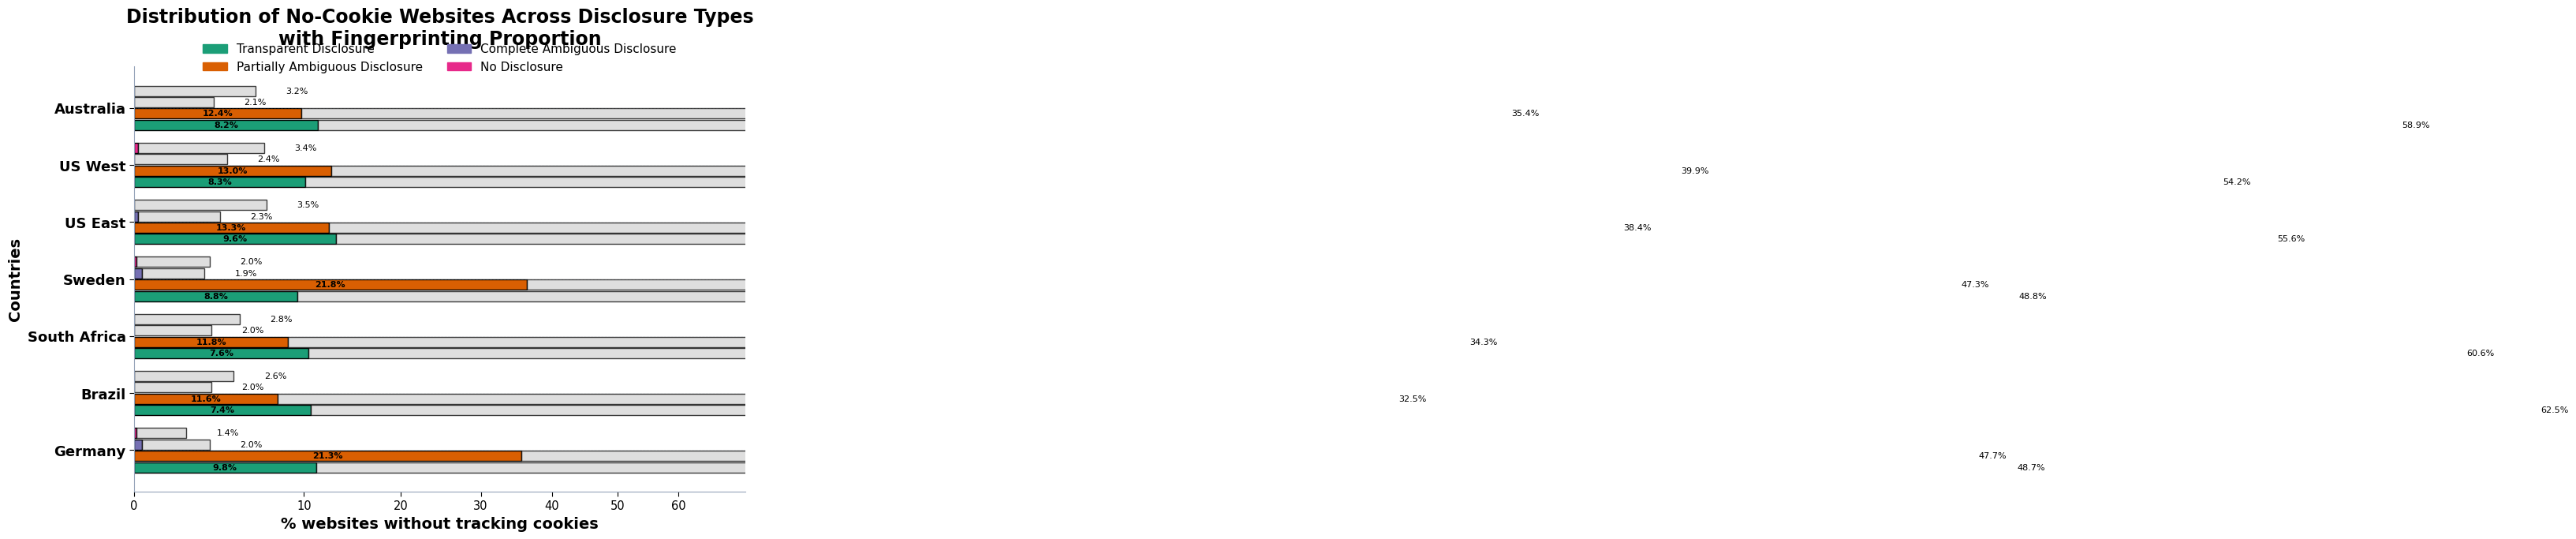

In [39]:
import pandas as pd
import json
import os
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from collections import defaultdict


# ============================================================
# CONFIG
# ============================================================

mode = "REJECT"

countries = [
    "Germany",
    "Brazil",
    "South Africa",
    "Sweden",
    "US East",
    "US West",
    "Australia"
]

locations = [f"{mode}/{country}" for country in countries]

disclosure_groups = [
    "Transparent Disclosure",
    "Partially Ambiguous Disclosure",
    "Complete Ambiguous Disclosure",
    "No Disclosure",
]


# ============================================================
# DISCLOSURE GROUP FUNCTION
# ============================================================

def assign_disclosure_group_country(domain, t, pa, ca, nd):

    if domain in t:
        return "Transparent Disclosure"

    elif domain in pa:
        return "Partially Ambiguous Disclosure"

    elif domain in ca:
        return "Complete Ambiguous Disclosure"

    elif domain in nd:
        return "No Disclosure"

    return "Unknown"


# ============================================================
# LOAD DISCLOSURE SETS
# ============================================================

def load_disclosure_sets(location):

    def read_csv_set(path):

        if os.path.exists(path):

            with open(path, "r") as f:
                return set(
                    line.strip()
                    for line in f.readlines()
                )

        return set()

    return (

        read_csv_set(
            f"{location}/Transparent.csv"
        ),

        read_csv_set(
            f"{location}/Partially_Ambiguous.csv"
        ),

        read_csv_set(
            f"{location}/Completely_Ambiguous.csv"
        ),

        read_csv_set(
            f"{location}/No_Disclosure.csv"
        ),

    )


# ============================================================
# DISCONNECT FUNCTIONS
# ============================================================

def download_disconnect_list():

    url = (
        "https://raw.githubusercontent.com/"
        "disconnectme/"
        "disconnect-tracking-protection/"
        "master/services.json"
    )

    print(
        "Downloading Disconnect tracker list..."
    )

    try:

        response = requests.get(
            url,
            timeout=30
        )

        response.raise_for_status()

        json_data = response.json()

        os.makedirs(
            "dataset_disconnect",
            exist_ok=True
        )

        output_file = (
            "dataset_disconnect/"
            "services-relay-disconnect.json"
        )

        with open(
            output_file,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                json_data,
                f,
                indent=2
            )

        print(
            "✓ Download complete"
        )

        return json_data

    except Exception as e:

        print(
            "Download error:",
            e
        )

        return None


def extract_domains_from_category(category_list):

    domains = set()

    for item in category_list:

        for _, service_data in item.items():

            for _, domain_list in service_data.items():

                domains.update(
                    domain_list
                )

    return domains


def load_and_process_disconnect_data(
    json_file=(
        "dataset_disconnect/"
        "services-relay-disconnect.json"
    )
):

    with open(
        json_file,
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    fp_invasive = extract_domains_from_category(

        data.get(
            "categories",
            {}
        ).get(
            "FingerprintingInvasive",
            []
        )

    )

    fp_general = extract_domains_from_category(

        data.get(
            "categories",
            {}
        ).get(
            "FingerprintingGeneral",
            []
        )

    )

    return (
        fp_invasive,
        fp_general
    )


def apply_disconnect_categories_to_dataframe(
    df,
    domain_column="domain_script_url"
):

    try:

        fp_invasive, fp_general = (
            load_and_process_disconnect_data()
        )

    except FileNotFoundError:

        data = download_disconnect_list()

        fp_invasive = extract_domains_from_category(
            data["categories"][
                "FingerprintingInvasive"
            ]
        )

        fp_general = extract_domains_from_category(
            data["categories"][
                "FingerprintingGeneral"
            ]
        )

    df[
        "FingerprintingInvasive"
    ] = df[
        domain_column
    ].isin(
        fp_invasive
    )

    df[
        "FingerprintingGeneral"
    ] = df[
        domain_column
    ].isin(
        fp_general
    )

    return df


json_data = download_disconnect_list()

# ============================================================
# STORAGE
# ============================================================

country_no_cookie = {
    g: []
    for g in disclosure_groups
}

country_fp_share = {
    g: []
    for g in disclosure_groups
}


# ============================================================
# MULTI COUNTRY ANALYSIS
# ============================================================

for loc in locations:

    print(f"\nProcessing {loc}")

    country = loc.split("/")[-1]

    (
        transparent,
        partial,
        complete,
        none
    ) = load_disclosure_sets(loc)

    df_javascript = pd.read_csv(
        f"{loc}/js.csv"
    )

    df_cookie = pd.read_csv(
        f"{loc}/javascript_cookies.csv"
    )

    if json_data:

        df_javascript = (
            apply_disconnect_categories_to_dataframe(
                df_javascript,
                domain_column="domain_script_url"
            )
        )

    # ------------------------------------------------
    # FILTER REJECT STAGE
    # ------------------------------------------------

    df_javascript_reject = df_javascript[
        df_javascript["clicked_stage"]
        ==
        "After Interaction (Reject)"
    ]

    df_cookie_reject = df_cookie[
        df_cookie["clicked_stage"]
        ==
        "After Interaction (Reject)"
    ]

    df_cookie_reject = df_cookie_reject[
        df_cookie_reject["domain_cookie"]
        !=
        df_cookie_reject["domain"]
    ]

    domains_with_tracking_cookies = set(
        df_cookie_reject["domain"]
    )

    total_domains = set(
        pd.read_csv(
            f"{loc}/common_domains_only_translated.csv"
        ).iloc[:,0]
    )

    domains_without_tracking_cookies = (
        total_domains
        -
        domains_with_tracking_cookies
    )

    # ------------------------------------------------
    # FINGERPRINTING FILTER
    # ------------------------------------------------

    df_javascript_reject = df_javascript_reject[

        (
            df_javascript_reject["AllList"]
            == True
        )

        &

        (
            (
                df_javascript_reject[
                    "FingerprintingInvasive"
                ] == True
            )

            |

            (
                df_javascript_reject[
                    "FingerprintingGeneral"
                ] == True
            )
        )

        &

        (
            df_javascript_reject[
                "domain_script_url"
            ]

            !=

            df_javascript_reject[
                "domain"
            ]
        )

    ]

    domains_with_fp = set(
        df_javascript_reject["domain"]
    )

    domains_fp_only = (
        domains_with_fp
        &
        domains_without_tracking_cookies
    )

    # ------------------------------------------------
    # GROUP COUNTS
    # ------------------------------------------------

    group_total = defaultdict(int)

    group_fp = defaultdict(int)

    for domain in domains_without_tracking_cookies:

        group = assign_disclosure_group_country(
            domain,
            transparent,
            partial,
            complete,
            none
        )

        group_total[group] += 1

    for domain in domains_fp_only:

        group = assign_disclosure_group_country(
            domain,
            transparent,
            partial,
            complete,
            none
        )

        group_fp[group] += 1

    # ------------------------------------------------
    # PERCENTAGES
    # ------------------------------------------------

    total_no_cookie_country = len(
        domains_without_tracking_cookies
    )

    for g in disclosure_groups:

        total_no_cookie_group = (
            group_total[g]
        )

        fp_group = (
            group_fp[g]
        )

        # total bar width

        no_cookie_pct = (

            total_no_cookie_group

            /

            total_no_cookie_country

            * 100

            if total_no_cookie_country > 0

            else 0

        )

        # FP share inside disclosure category

        fp_partition_pct = (

            fp_group

            /

            total_no_cookie_group

            * 100

            if total_no_cookie_group > 0

            else 0

        )

        country_no_cookie[g].append(
            no_cookie_pct
        )

        country_fp_share[g].append(
            fp_partition_pct
        )


# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,7)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]

for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    fp_bar_vals = []

    non_fp_vals = []

    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        fp_width = (
            total
            *
            fp_share
            /
            100
        )

        fp_bar_vals.append(
            fp_width
        )

        non_fp_vals.append(
            total
            -
            fp_width
        )

    # FP PARTITION

    ax.barh(

        y,

        fp_bar_vals,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )

    # REMAINING SECTION

    ax.barh(

        y,

        non_fp_vals,

        left=fp_bar_vals,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )

    # LABELS

    for yy, total, fp_share, fp_width in zip(
        y,
        total_vals,
        fp_share_vals,
        fp_bar_vals
    ):

        if fp_width > 0.5:

            ax.text(

                fp_width/2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        ax.text(

            total + 0.8,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)

ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=14,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=14,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=17,

    fontweight="bold",

    pad=20

)

# ==========================================
# COMPRESS X VISUAL SPACING
# ==========================================

compression = 0.65

real_ticks = np.arange(
    0,
    70,
    10
)

compressed_ticks = (
    real_ticks
    **
    compression
)

ax.set_xticks(
    compressed_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(
    0,
    (65 ** compression) + 1
)

# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=11

)

plt.tight_layout()

plt.savefig(
    "countrywise_no_cookie_fp_horizontal.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

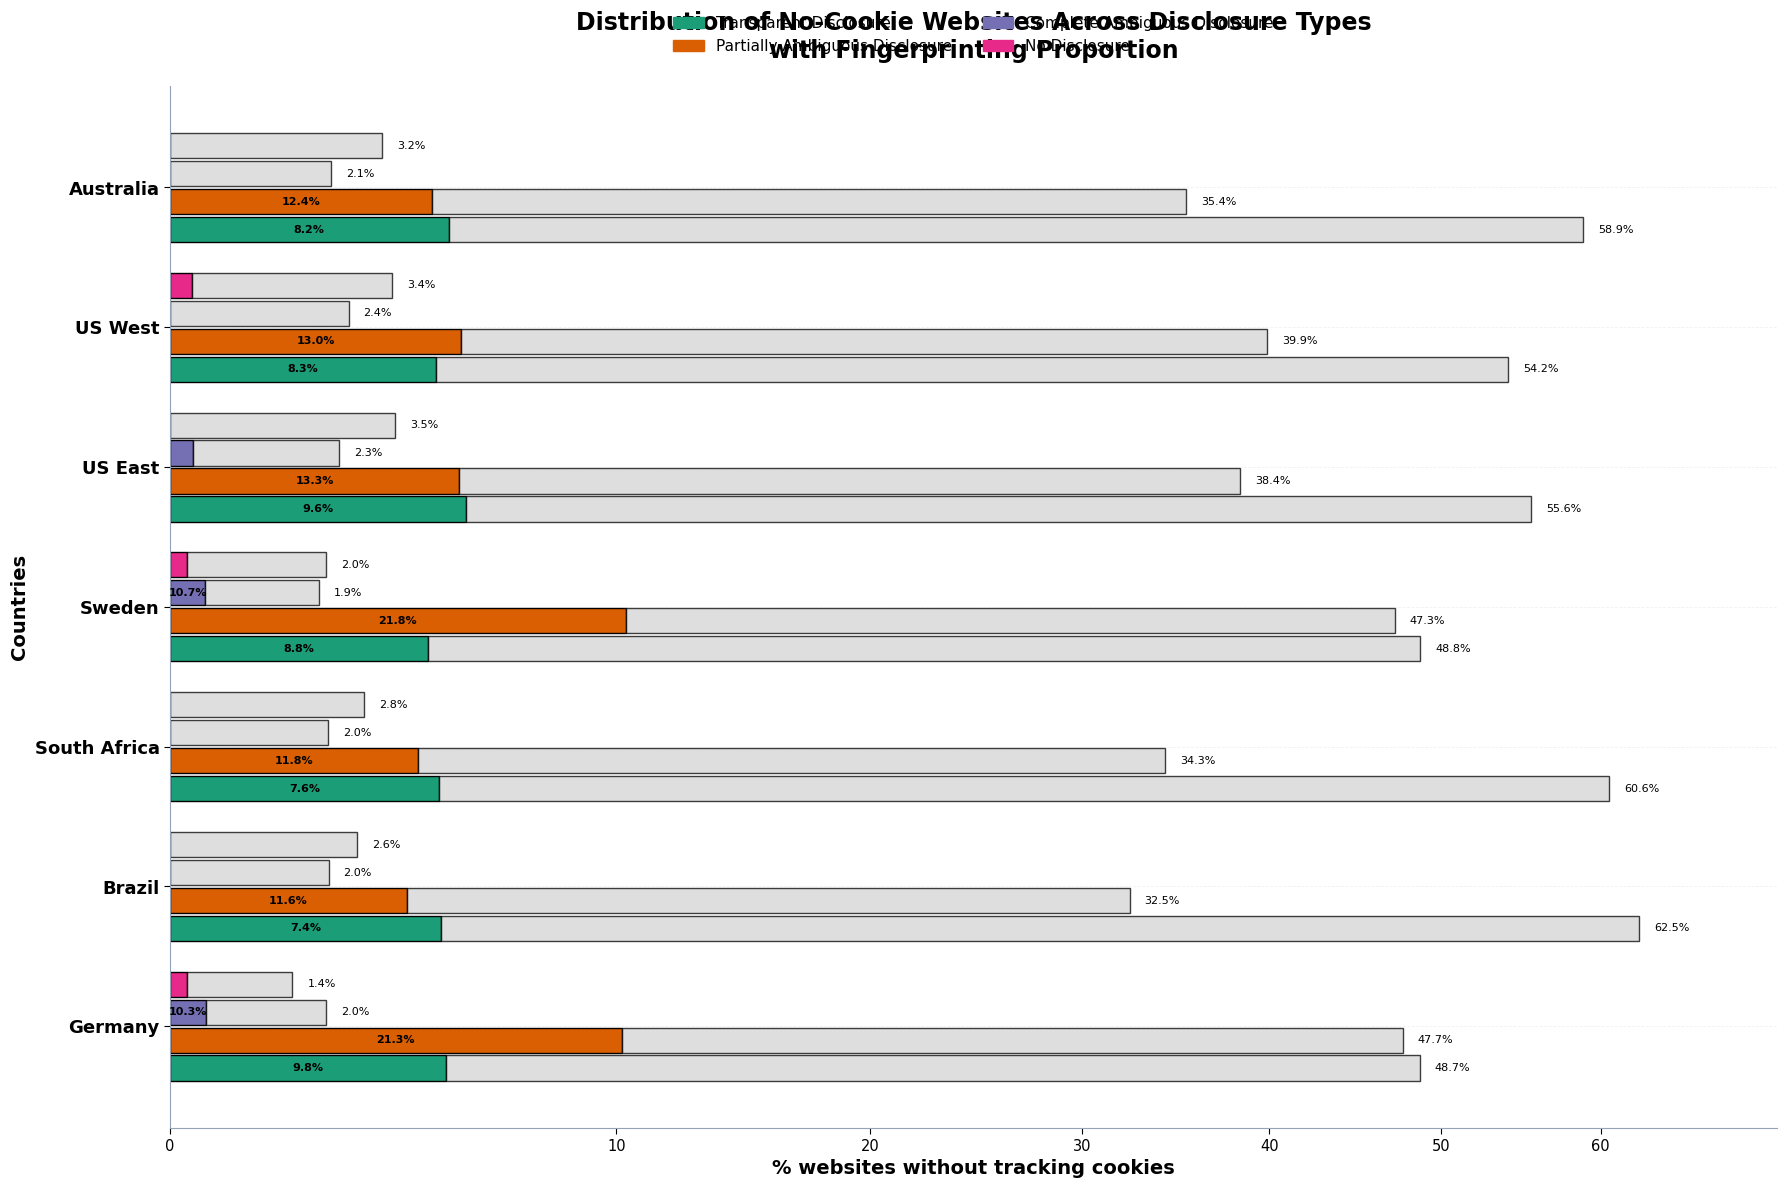

In [40]:
# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({

    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(18,12)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]

# ==========================================
# VISUAL COMPRESSION
# ==========================================

compression = 0.65


for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = country_no_cookie[group]

    fp_share_vals = country_fp_share[group]

    compressed_total = []

    compressed_fp = []

    compressed_nonfp = []

    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # original FP width

        fp_width = (
            total
            *
            fp_share
            /
            100
        )

        # compressed coordinates

        total_scaled = (
            total
            **
            compression
        )

        fp_scaled = (
            fp_width
            **
            compression
            if fp_width > 0
            else 0
        )

        compressed_total.append(
            total_scaled
        )

        compressed_fp.append(
            fp_scaled
        )

        compressed_nonfp.append(
            total_scaled
            -
            fp_scaled
        )

    # ======================================
    # FP SECTION
    # ======================================

    ax.barh(

        y,

        compressed_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )

    # ======================================
    # NON FP SECTION
    # ======================================

    ax.barh(

        y,

        compressed_nonfp,

        left=compressed_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )

    # ======================================
    # LABELS
    # ======================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        compressed_fp,

        compressed_total

    ):

        # FP label

        if fp_scaled > 0.25:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        # total label

        ax.text(

            total_scaled + 0.15,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)

# compressed tick locations

real_ticks = np.arange(
    0,
    70,
    10
)

compressed_ticks = (
    real_ticks
    **
    compression
)

ax.set_xticks(
    compressed_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    (65 ** compression)
    + 1

)

ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=14,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=14,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=17,

    fontweight="bold",

    pad=20

)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=11

)

plt.tight_layout()

plt.savefig(
    "countrywise_no_cookie_fp_horizontal.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

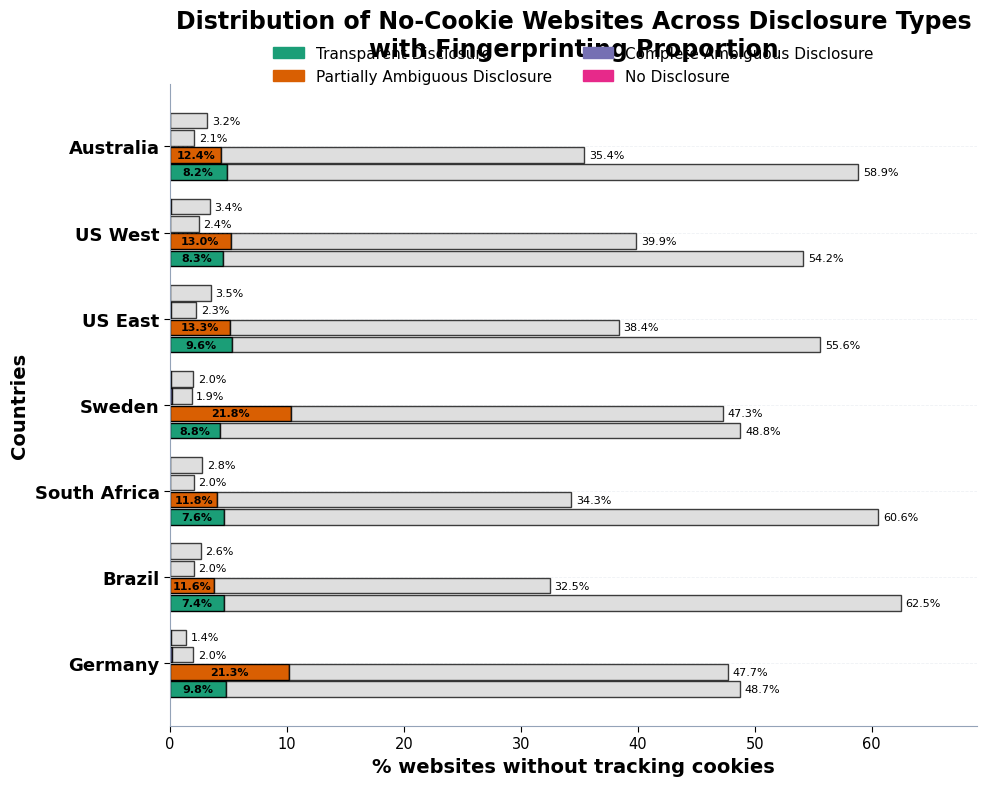

In [42]:
# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({

    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,8)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]

# ==========================================
# UNIFORM VISUAL COMPRESSION
# ==========================================

scale = 0.25


for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []

    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # original FP width

        fp_width = (
            total
            *
            fp_share
            /
            100
        )

        # uniformly compressed

        total_scaled = (
            total
            *
            scale
        )

        fp_scaled = (
            fp_width
            *
            scale
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            total_scaled
            -
            fp_scaled
        )

    # ==================================================
    # FP SECTION
    # ==================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )

    # ==================================================
    # REMAINING SECTION
    # ==================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )

    # ==================================================
    # LABELS
    # ==================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # FP label

        if fp_scaled > 0.10:

            ax.text(

                fp_scaled/2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        # total label

        ax.text(

            total_scaled + 0.10,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)

# equal spacing ticks

real_ticks = np.arange(
    0,
    70,
    10
)

scaled_ticks = (
    real_ticks
    *
    scale
)

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(
    0,
    (65 * scale) + 1
)

ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=14,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=14,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=17,

    fontweight="bold",

    pad=20

)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=11

)

plt.tight_layout()

plt.savefig(

    "countrywise_no_cookie_fp_horizontal.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

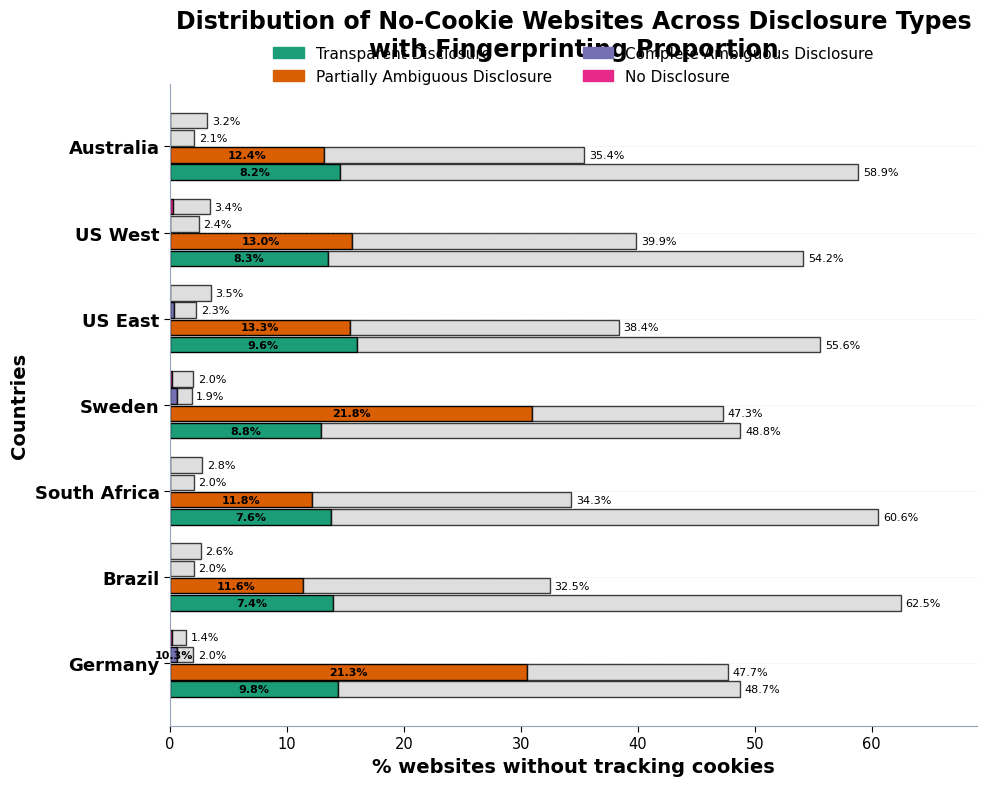

In [43]:
# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,8)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]


# ============================================================
# VISUAL SCALING
# ============================================================

scale = 0.25

# enlarge FP region only
fp_visual_scale = 3.0


for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual FP width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        # compressed total width

        total_scaled = (

            total
            *
            scale

        )

        # enlarged FP section

        fp_scaled = (

            fp_width
            *
            scale
            *
            fp_visual_scale

        )

        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled * 0.95

        )

        remaining = (

            total_scaled
            -
            fp_scaled

        )

        remaining = max(
            remaining,
            0
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP PARTITION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING REGION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # FP internal label

        if fp_scaled > 0.15:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        # total label

        ax.text(

            total_scaled + 0.10,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)


# equal spacing ticks

real_ticks = np.arange(
    0,
    70,
    10
)

scaled_ticks = (

    real_ticks
    *
    scale

)

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    (65 * scale) + 1

)


ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=14,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=14,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=17,

    fontweight="bold",

    pad=20

)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=11

)


plt.tight_layout()

plt.savefig(

    "countrywise_no_cookie_fp_horizontal.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

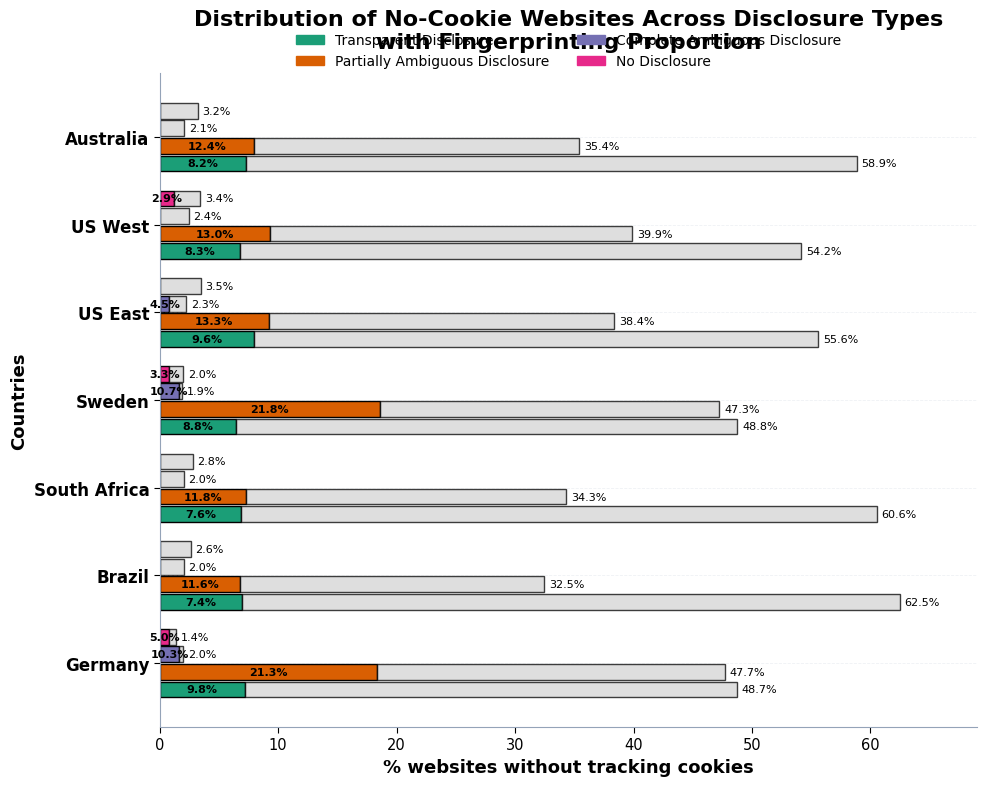

In [44]:
# ============================================================
# PLOT
# ============================================================

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,8)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]


# ============================================================
# VISUAL COMPRESSION
# ============================================================

scale = 0.25


# ============================================================
# CATEGORY-SPECIFIC FP ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 8.0,

    "No Disclosure": 12.0

}


# maximum visible occupation

max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []

    group_scale = (
        fp_visual_scale_map[group]
    )


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # --------------------------------
        # ORIGINAL FP WIDTH
        # --------------------------------

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        # --------------------------------
        # TOTAL BAR
        # --------------------------------

        total_scaled = (

            total
            *
            scale

        )

        # --------------------------------
        # ENLARGED FP REGION
        # --------------------------------

        fp_scaled = (

            fp_width
            *
            scale
            *
            group_scale

        )

        # prevent FP overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )

        remaining = (

            total_scaled
            -
            fp_scaled

        )

        remaining = max(
            remaining,
            0
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP REGION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING REGION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # FP label

        if fp_scaled > 0.15:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        # total label

        ax.text(

            total_scaled + 0.10,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=12,

    fontweight="bold"

)


real_ticks = np.arange(
    0,
    70,
    10
)

scaled_ticks = (

    real_ticks
    *
    scale

)

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    (65 * scale)
    + 1

)

ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=13,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=13,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=16,

    fontweight="bold",

    pad=18

)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=10

)


plt.tight_layout()

plt.savefig(

    "countrywise_no_cookie_fp_horizontal.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

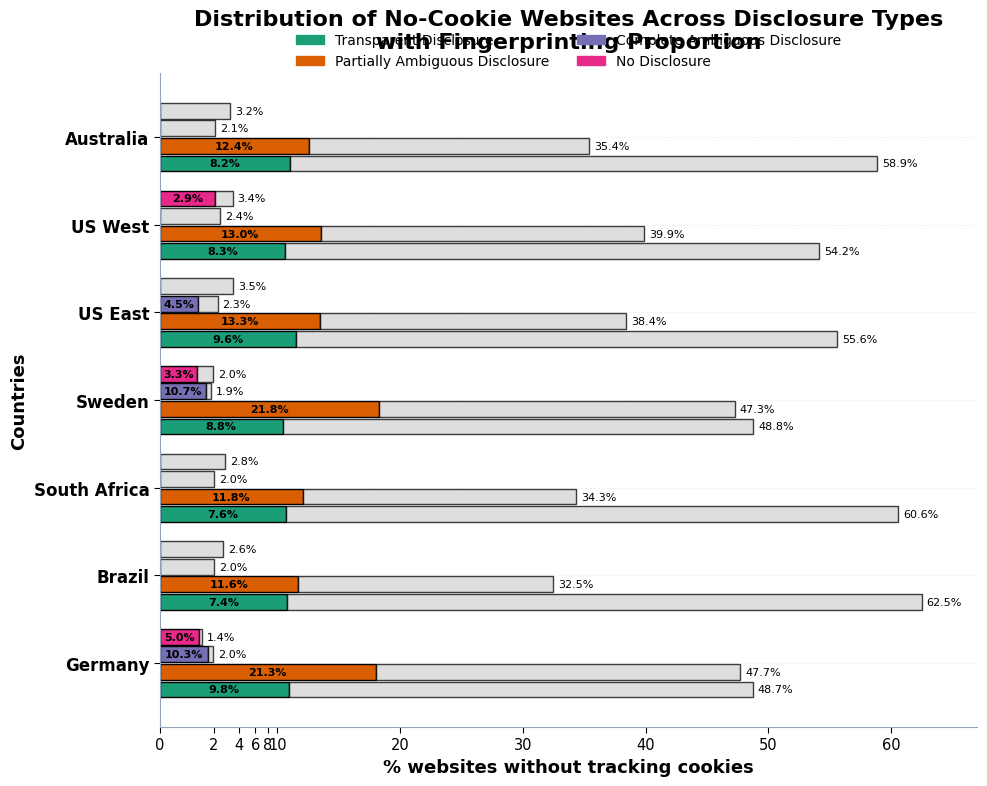

In [45]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import math

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,8)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]


# ============================================================
# HYBRID SCALE
# <10% -> log expansion
# >=10% -> linear spacing
# ============================================================

def hybrid_scale(x):

    if x <= 0:
        return 0

    if x < 10:

        return (
            4
            *
            np.log1p(x)
        )

    return (

        4
        *
        np.log1p(10)

        +

        (x - 10)

    )


# ============================================================
# CATEGORY SPECIFIC FP ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 8.0,

    "No Disclosure": 12.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual FP width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        # hybrid transformed total

        total_scaled = (
            hybrid_scale(
                total
            )
        )

        # hybrid transformed FP

        fp_scaled = (

            hybrid_scale(
                fp_width
            )

            *
            group_scale

        )

        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )

        remaining = (

            total_scaled
            -
            fp_scaled

        )

        remaining = max(
            remaining,
            0
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP REGION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # NON-FP REGION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # FP percentage label

        if fp_scaled > 0.25:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        # total percentage label

        ax.text(

            total_scaled + 0.4,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=12,

    fontweight="bold"

)


# hybrid ticks

real_ticks = [

    0,

    2,

    4,

    6,

    8,

    10,

    20,

    30,

    40,

    50,

    60

]

scaled_ticks = [

    hybrid_scale(t)

    for t in real_ticks

]

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    hybrid_scale(65)
    + 2

)


ax.set_xlabel(

    "% websites without tracking cookies",

    fontsize=13,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=13,

    fontweight="bold"

)

ax.set_title(

    "Distribution of No-Cookie Websites Across Disclosure Types\n"
    "with Fingerprinting Proportion",

    fontsize=16,

    fontweight="bold",

    pad=18

)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=10

)


plt.tight_layout()

plt.savefig(

    "countrywise_no_cookie_fp_horizontal.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

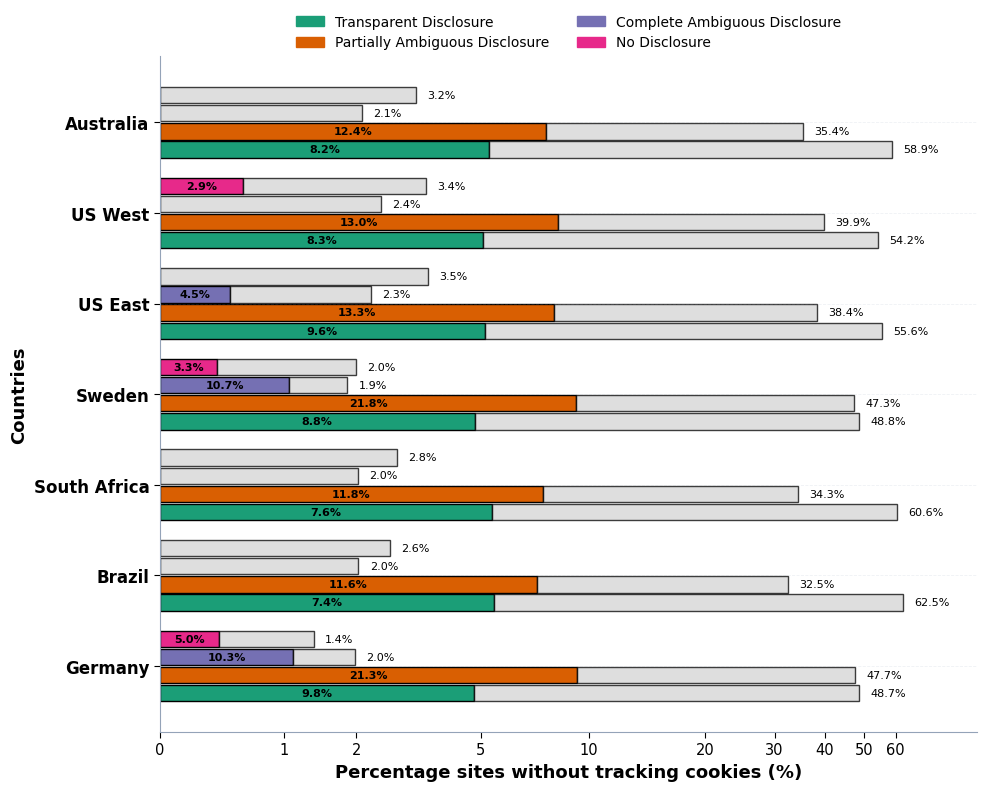

In [48]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": False,

    "axes.spines.right": False,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,8)
)

country_positions = np.arange(
    len(countries)
)

bar_height = 0.18

offsets = [
    -0.30,
    -0.10,
    0.10,
    0.30
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:
        return 0

    return (
        log_factor
        *
        np.log1p(x)
    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual FP width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        # log transformed total

        total_scaled = log_scale(
            total
        )

        # log transformed FP

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )

        # overflow protection

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )

        remaining = (

            total_scaled
            -
            fp_scaled

        )

        remaining = max(
            remaining,
            0
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP REGION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled/2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=12,

    fontweight="bold"

)


# log ticks

real_ticks = [
    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60
]

scaled_ticks = [

    log_scale(
        t
    )

    for t in real_ticks

]

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=13,

    fontweight="bold"

)

ax.set_ylabel(

    "Countries",

    fontsize=13,

    fontweight="bold"

)



# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    bbox_to_anchor=(0.5,1.08),

    loc="upper center",

    ncol=2,

    fontsize=10

)


plt.tight_layout()

plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

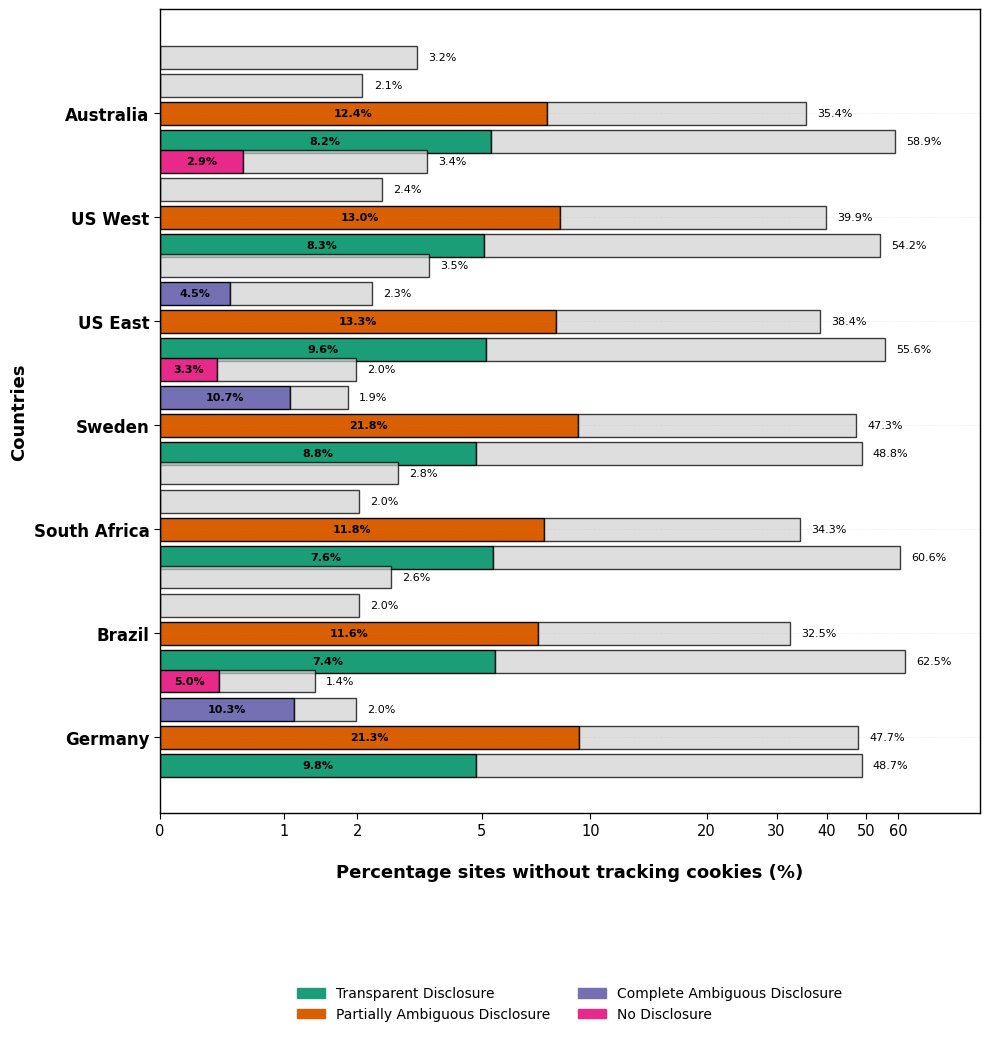

In [55]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    # show all borders

    "axes.spines.top": True,

    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(10,12)
)

country_positions = np.arange(
    len(countries)
)
# thicker bars

bar_height = 0.22


# slightly tighter grouping

offsets = [
    -0.27,
    0,
    0.27,
    0.54
]

colors = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
    "#e7298a"
]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:
        return 0

    return (
        log_factor
        *
        np.log1p(x)
    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (
        country_positions
        +
        offsets[i]
    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        total_scaled = log_scale(
            total
        )

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )

        remaining = (

            total_scaled
            -
            fp_scaled

        )

        remaining = max(
            remaining,
            0
        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP REGION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled/2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=8,

                fontweight="bold"

            )

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=8,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=12,

    fontweight="bold"

)


real_ticks = [
    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60
]

scaled_ticks = [

    log_scale(
        t
    )

    for t in real_ticks

]

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=13,

    fontweight="bold",

    labelpad=18

)

ax.set_ylabel(

    "Countries",

    fontsize=13,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# BELOW X LABEL
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.20),

    ncol=2,

    fontsize=10

)


# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.28,

    left=0.14,

    right=0.96,

    top=0.95

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

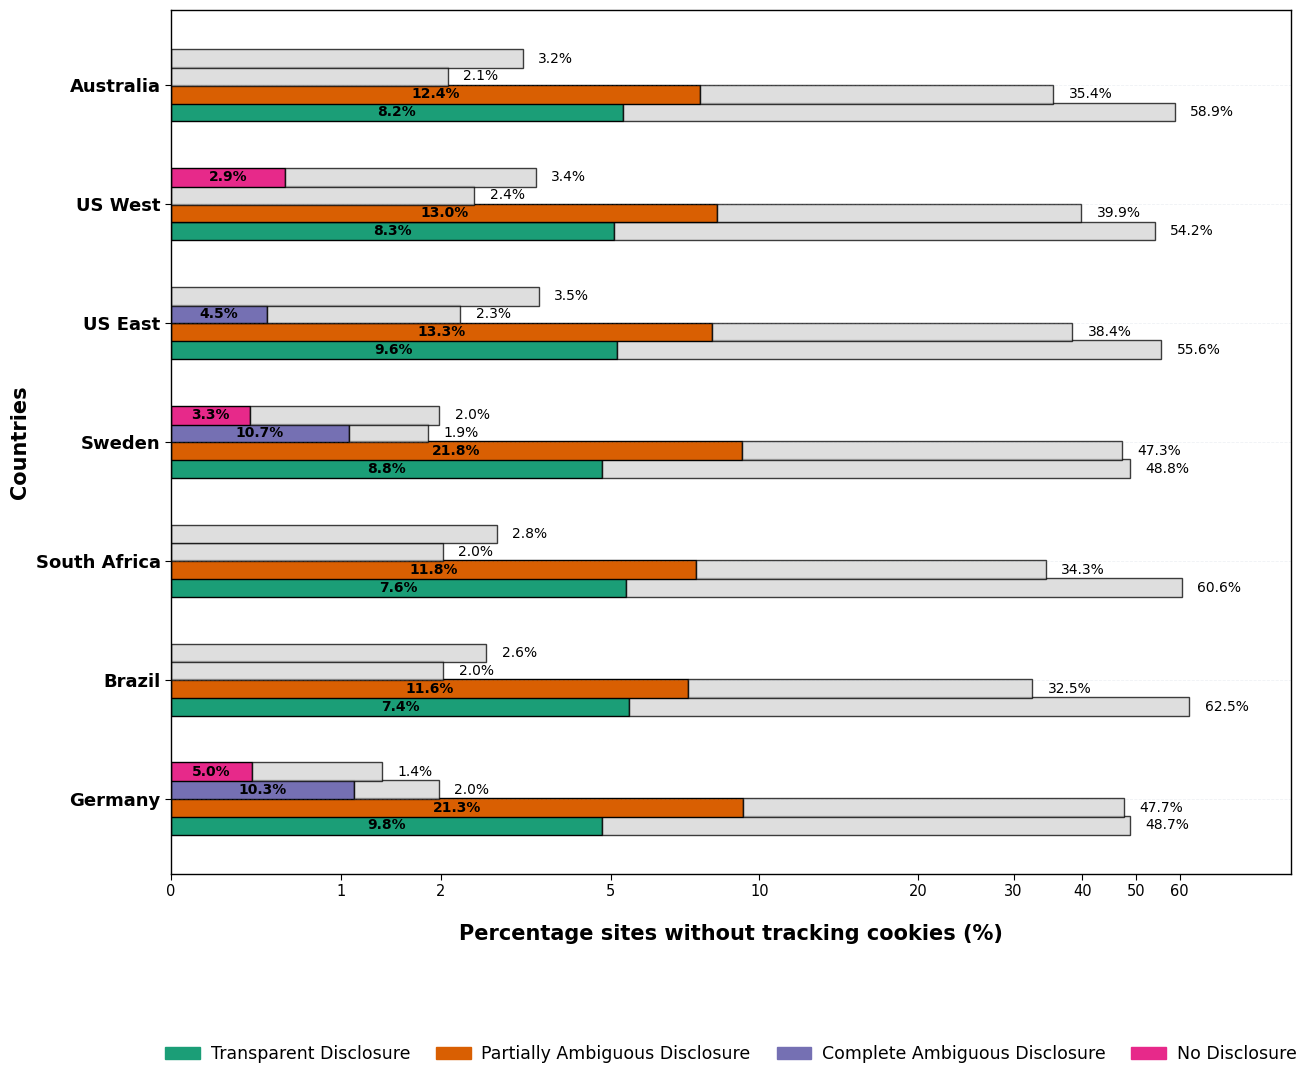

In [64]:
# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(14,12)
)

# ------------------------------------------------
# COUNTRY SPACING
# larger separation between countries
# ------------------------------------------------

country_gap = 1.40

country_positions = np.arange(
    len(countries)
) * country_gap


# ------------------------------------------------
# BAR THICKNESS
# ------------------------------------------------

bar_height = 0.22


# ------------------------------------------------
# DISCLOSURE BARS
# tightly stitched together
# ------------------------------------------------

offset_step = 0.21

offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]

colors = [

    "#1b9e77",

    "#d95f02",

    "#7570b3",

    "#e7298a"

]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        fp_width = (

            total
            *
            fp_share
            /
            100

        )

        total_scaled = log_scale(
            total
        )

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )

        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )

        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # FP SECTION

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # REMAINING SECTION

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # LABELS

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled/2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=10,

                fontweight="bold"

            )

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=10,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]

scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]

ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)

ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=15,

    fontweight="bold",

    labelpad=18

)

ax.set_ylabel(

    "Countries",

    fontsize=15,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]

ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.18),

    ncol=4,          # all disclosure types in one row

    fontsize=12.5,

    columnspacing=1.5,

    handletextpad=0.6

)
# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.24,

    left=0.16,

    right=0.96,

    top=0.96

)

plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

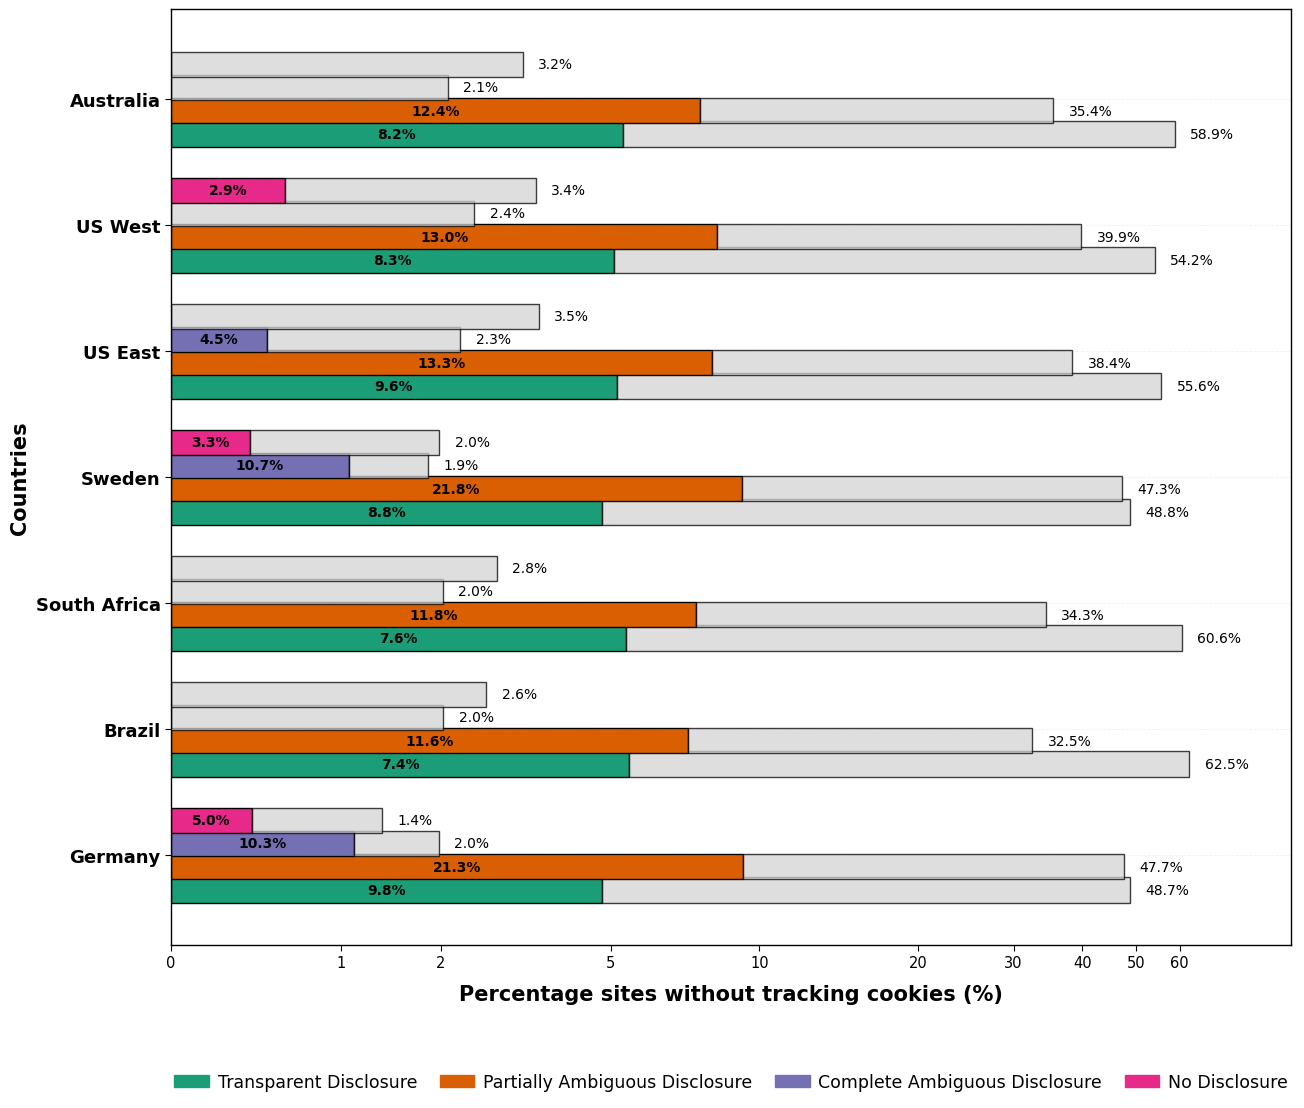

In [66]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": True,
    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(14,12)
)


# ============================================================
# COUNTRY SPACING
# ============================================================

country_gap = 1.30

country_positions = np.arange(
    len(countries)
) * country_gap


# ============================================================
# BAR SETTINGS
# ============================================================

bar_height = 0.26


# tightly packed disclosure bars

offset_step = 0.24

offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]


colors = [

    "#1b9e77",

    "#d95f02",

    "#7570b3",

    "#e7298a"

]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual fingerprinting width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )


        # log transformed total

        total_scaled = log_scale(
            total
        )


        # enlarged fingerprint region

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )


        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )


        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )


        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # fingerprint percentage

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=10,

                fontweight="bold"

            )


        # total percentage

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=10,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=13,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]


scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]


ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)


ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=15,

    fontweight="bold",

    labelpad=10

)


ax.set_ylabel(

    "Countries",

    fontsize=15,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]


ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.12),

    ncol=4,

    fontsize=12.5,

    columnspacing=1.3,

    handletextpad=0.5

)


# ============================================================
# FINAL SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.18,

    left=0.16,

    right=0.96,

    top=0.96

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

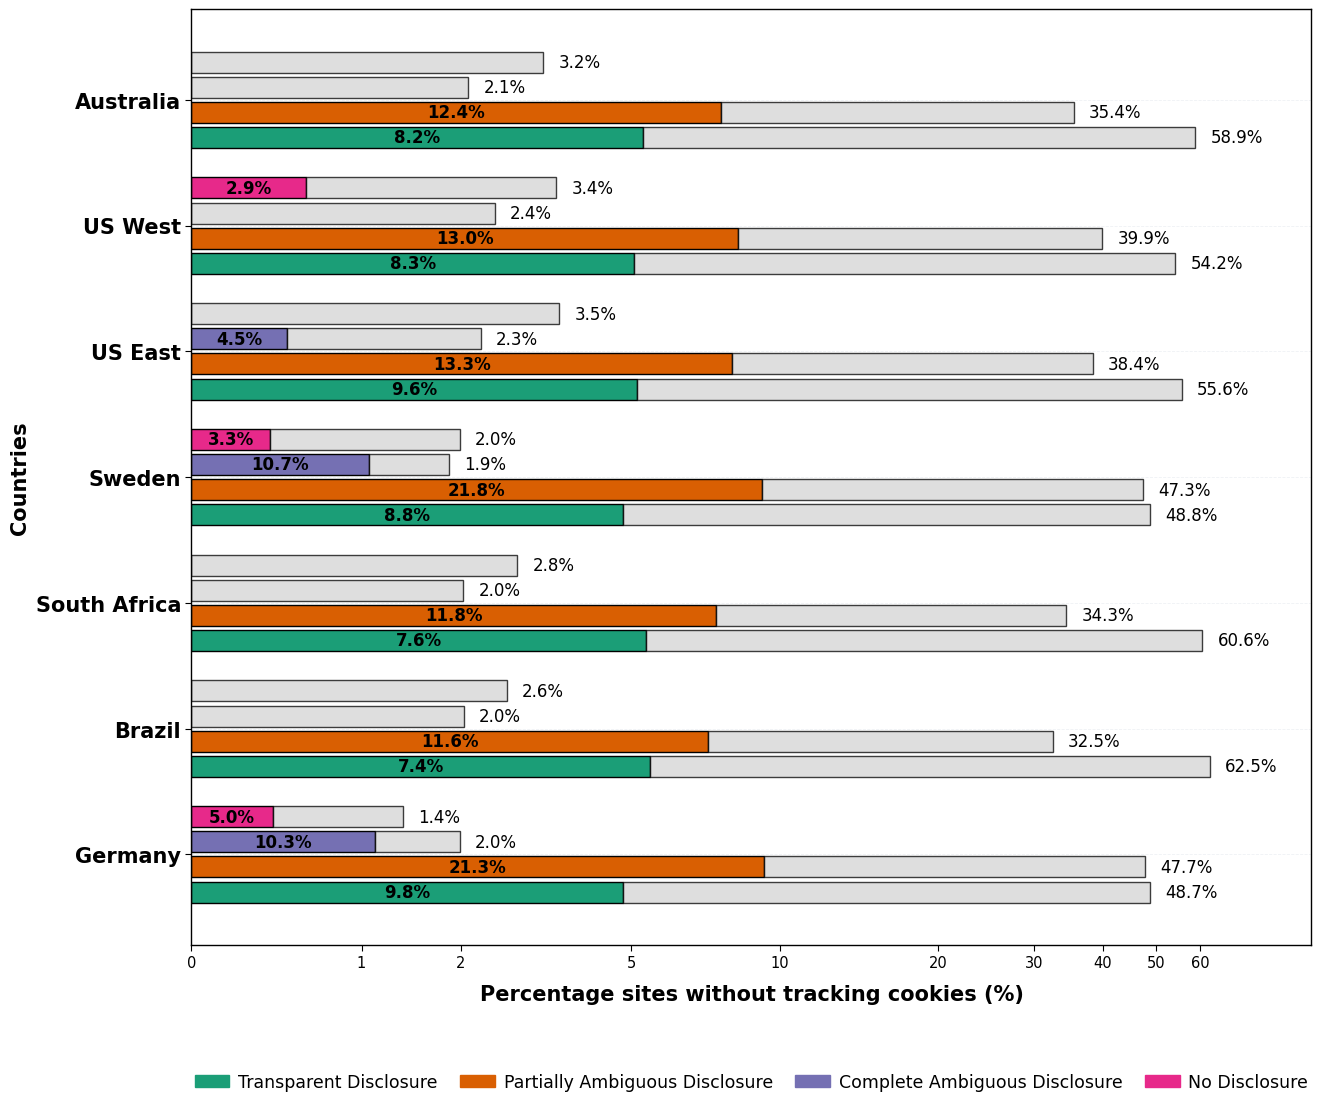

In [69]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": True,
    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(14,12)
)


# ============================================================
# COUNTRY SPACING
# ============================================================

country_gap = 1.20

country_positions = np.arange(
    len(countries)
) * country_gap


# ============================================================
# BAR SETTINGS
# ============================================================

bar_height = 0.20


# tightly packed disclosure bars

offset_step = 0.24

offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]


colors = [

    "#1b9e77",

    "#d95f02",

    "#7570b3",

    "#e7298a"

]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual fingerprinting width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )


        # log transformed total

        total_scaled = log_scale(
            total
        )


        # enlarged fingerprint region

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )


        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )


        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )


        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # fingerprint percentage

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=12,

                fontweight="bold"

            )


        # total percentage

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=12,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=15,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]


scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]


ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks
)


ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=15,

    fontweight="bold",

    labelpad=10

)


ax.set_ylabel(

    "Countries",

    fontsize=15,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]


ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.12),

    ncol=4,

    fontsize=12.5,

    columnspacing=1.3,

    handletextpad=0.5

)


# ============================================================
# FINAL SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.18,

    left=0.16,

    right=0.96,

    top=0.96

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

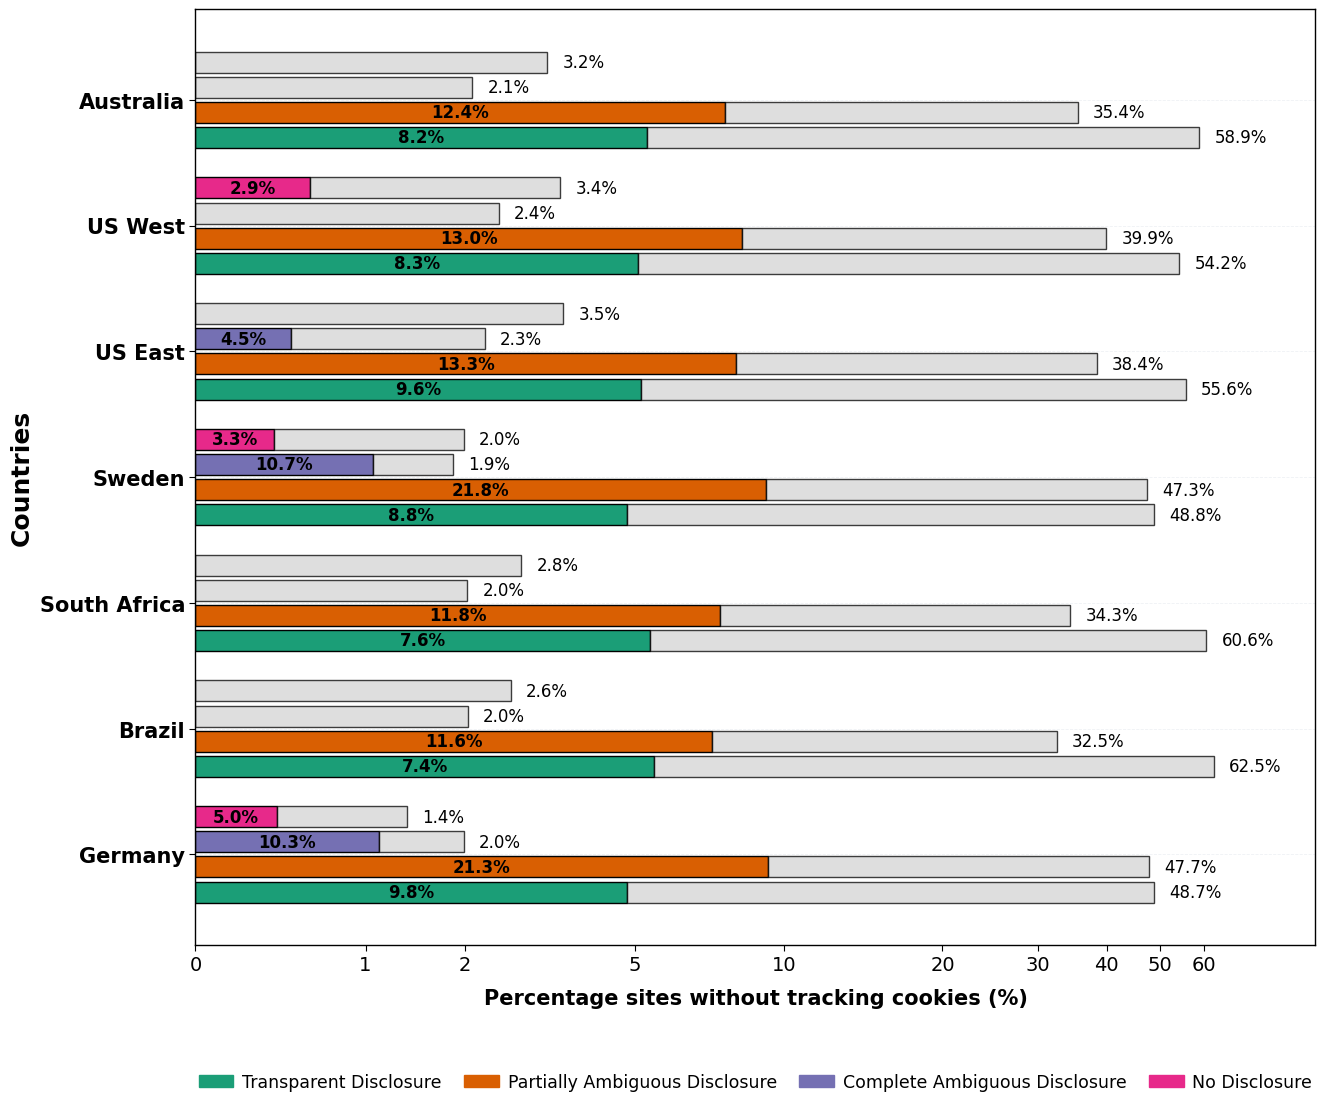

In [71]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": True,
    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(14,12)
)


# ============================================================
# COUNTRY SPACING
# ============================================================

country_gap = 1.20

country_positions = np.arange(
    len(countries)
) * country_gap


# ============================================================
# BAR SETTINGS
# ============================================================

bar_height = 0.20


# tightly packed disclosure bars

offset_step = 0.24

offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]


colors = [

    "#1b9e77",

    "#d95f02",

    "#7570b3",

    "#e7298a"

]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual fingerprinting width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )


        # log transformed total

        total_scaled = log_scale(
            total
        )


        # enlarged fingerprint region

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )


        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )


        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )


        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # fingerprint percentage

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=12,

                fontweight="bold"

            )


        # total percentage

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=12,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=15,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]


scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]


ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks,
    fontsize=14
)


ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without tracking cookies (%)",

    fontsize=15,

    fontweight="bold",

    labelpad=10

)


ax.set_ylabel(

    "Countries",

    fontsize=18,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]


ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.12),

    ncol=4,

    fontsize=12.5,

    columnspacing=1.3,

    handletextpad=0.5

)


# ============================================================
# FINAL SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.18,

    left=0.16,

    right=0.96,

    top=0.96

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


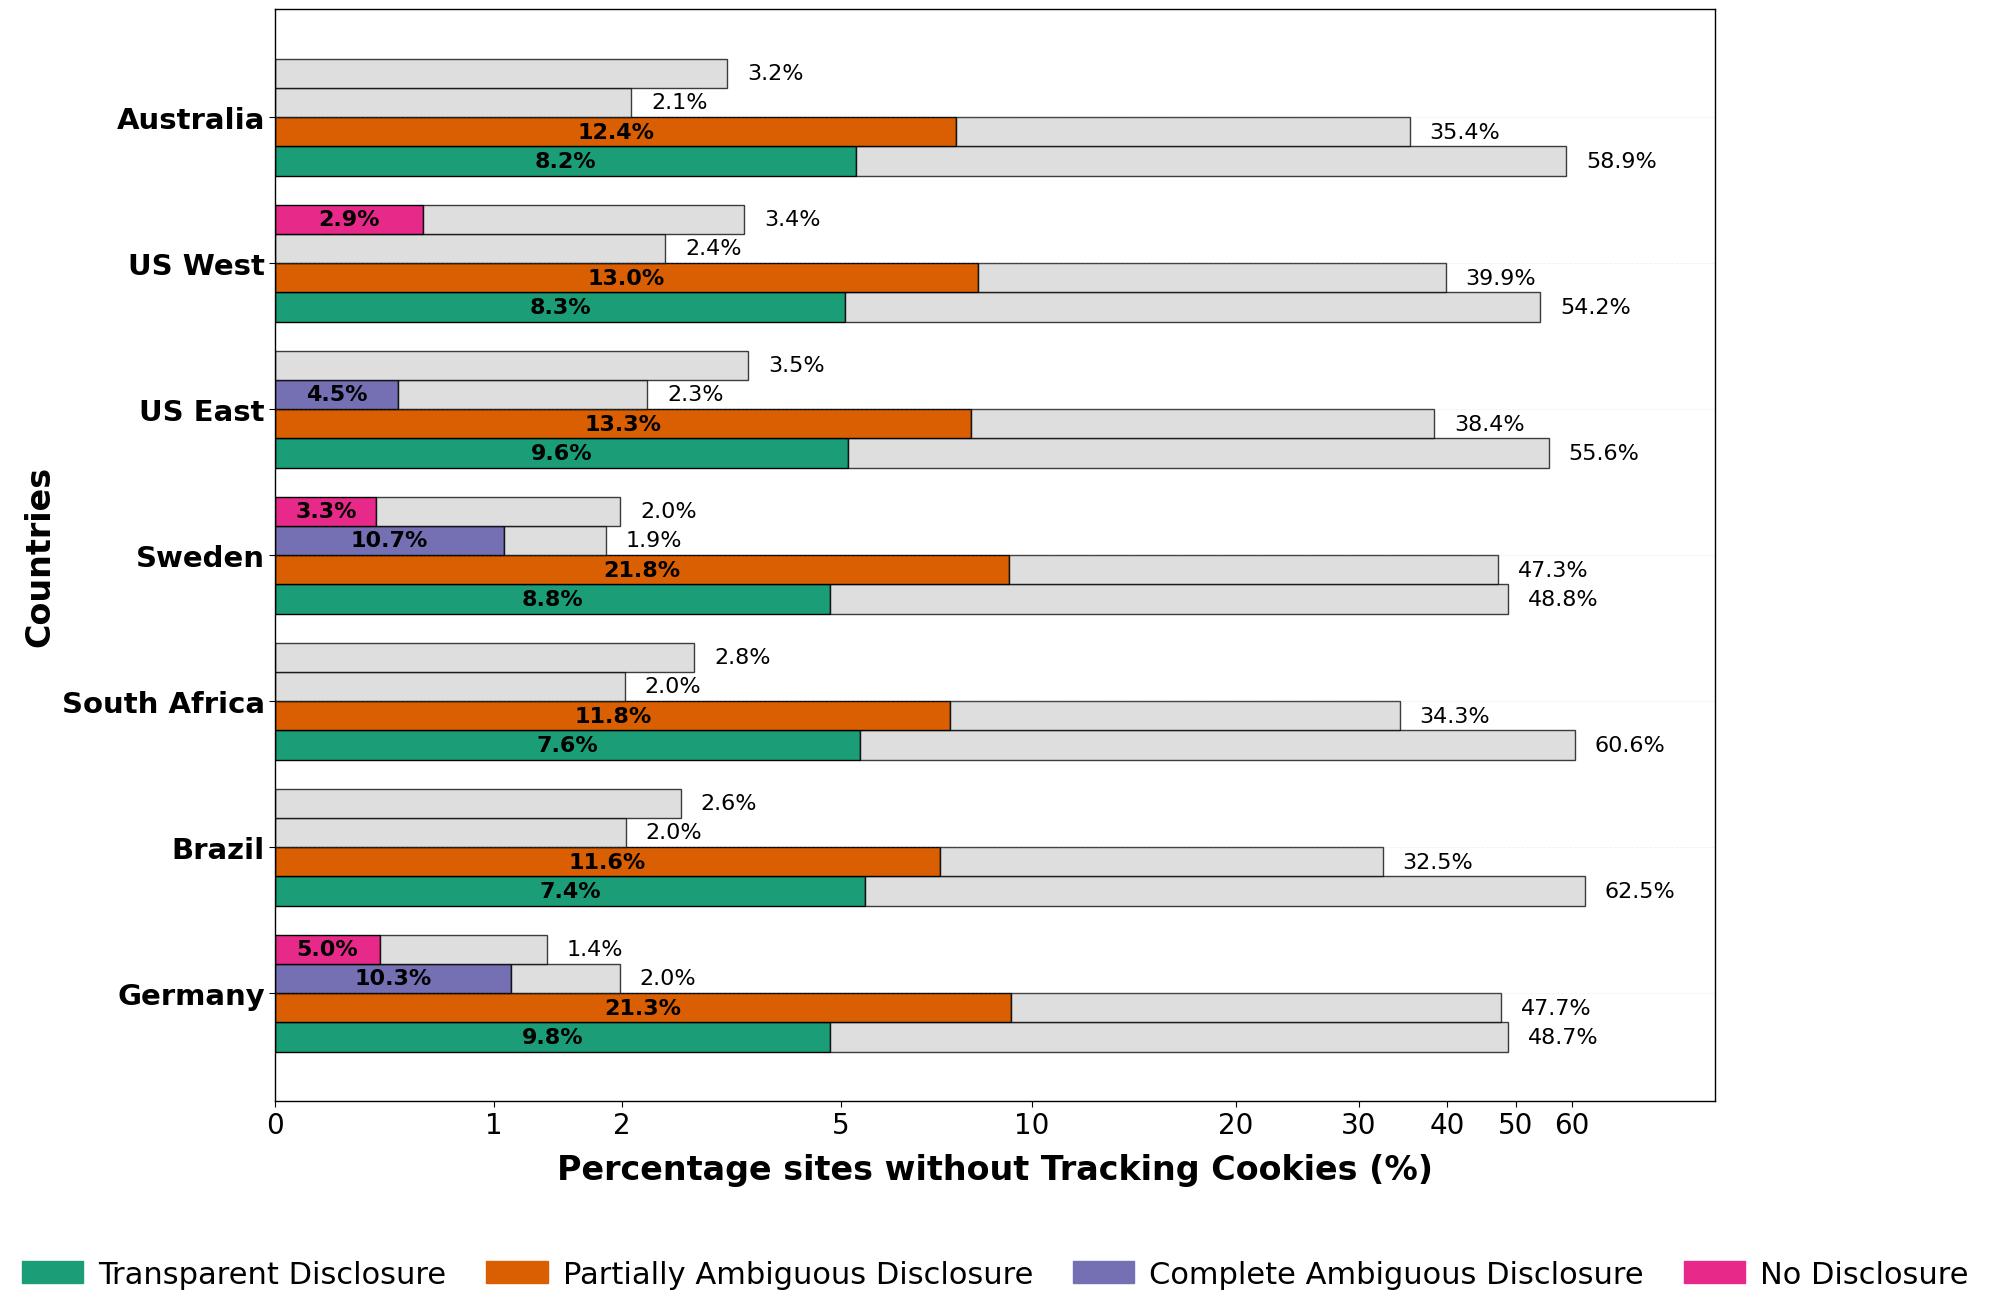

In [84]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": True,
    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(18,14)
)


# ============================================================
# COUNTRY SPACING
# ============================================================

country_gap = 1.20

country_positions = np.arange(
    len(countries)
) * country_gap


# ============================================================
# BAR SETTINGS
# ============================================================

# HISTOGRAM-STYLE: bar_height == offset_step so bars touch edge-to-edge
offset_step = 0.24
bar_height = offset_step  # exactly equal, zero gap, no overlap


offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]


colors = [

    "#1b9e77",

    "#d95f02",

    "#7570b3",

    "#e7298a"

]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual fingerprinting width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )


        # log transformed total

        total_scaled = log_scale(
            total
        )


        # enlarged fingerprint region

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )


        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )


        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )


        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FP SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_fp,

        height=bar_height,

        color=colors[i],

        edgecolor="black"

    )


    # ========================================================
    # REMAINING SECTION
    # ========================================================

    ax.barh(

        y,

        scaled_nonfp,

        left=scaled_fp,

        height=bar_height,

        color="lightgray",

        edgecolor="black",

        alpha=0.75

    )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # fingerprint percentage

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=16,

                fontweight="bold"

            )


        # total percentage

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=16,

            va="center"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=21,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]


scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]


ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks,
    fontsize=20
)


ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without Tracking Cookies (%)",

    fontsize=24,

    fontweight="bold",

    labelpad=10

)


ax.set_ylabel(

    "Countries",

    fontsize=24,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

legend_handles = [

    plt.Rectangle(
        (0,0),
        1,
        1,
        color=colors[i]
    )

    for i in range(
        len(disclosure_groups)
    )

]


ax.legend(

    legend_handles,

    disclosure_groups,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.12),

    ncol=4,

    fontsize=22,

    columnspacing=1.3,

    handletextpad=0.5

)


# ============================================================
# FINAL SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.18,

    left=0.16,

    right=0.96,

    top=0.96

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

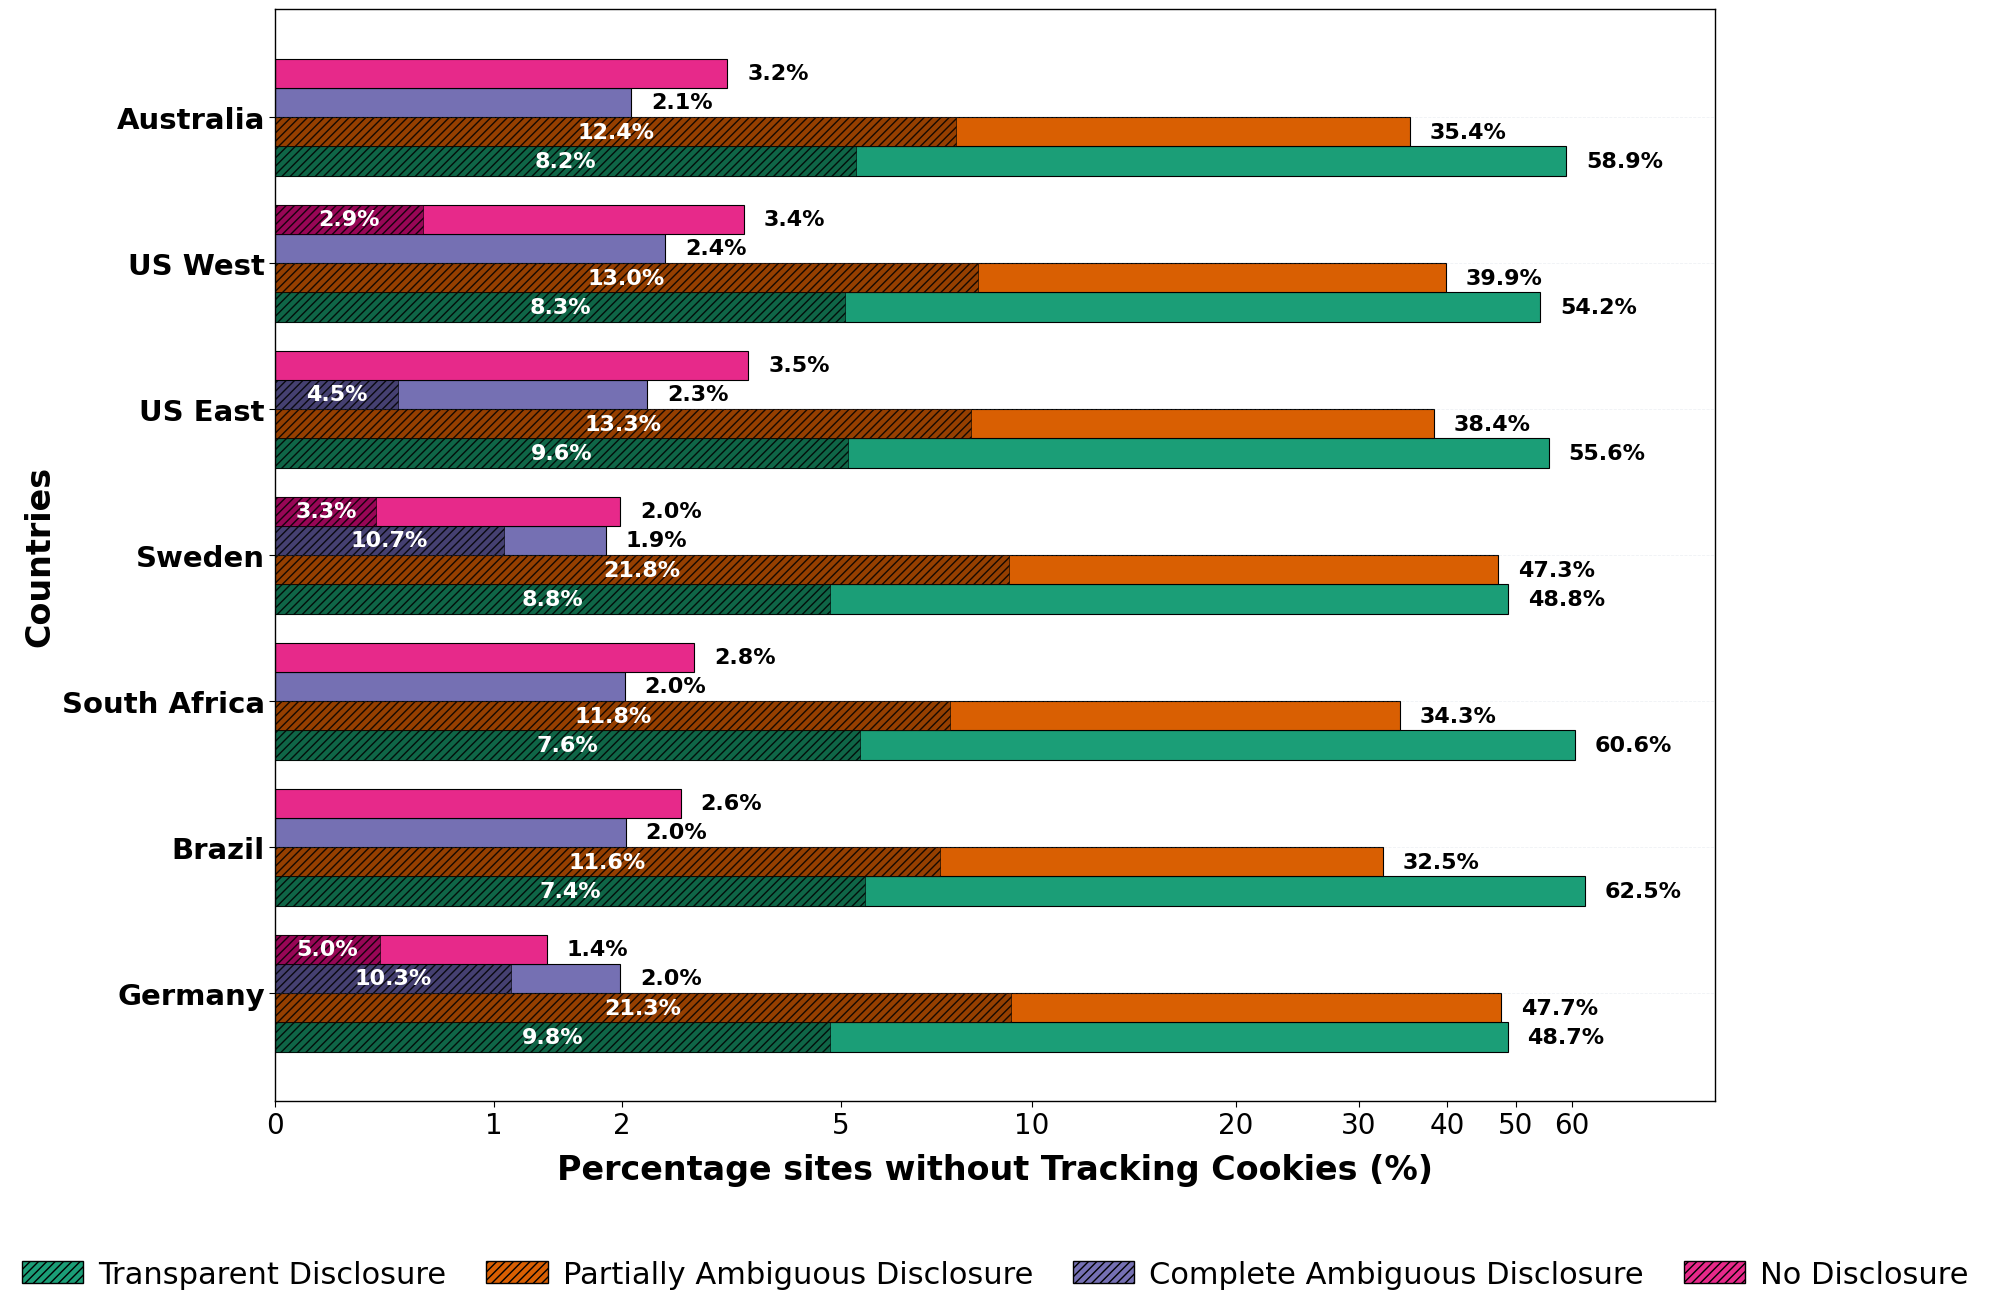

In [85]:
# ============================================================
# PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({

    "font.family": "DejaVu Sans",

    "axes.spines.top": True,
    "axes.spines.right": True,

    "axes.grid": True,

    "grid.alpha": 0.15,

    "grid.linestyle": "--"

})

fig, ax = plt.subplots(
    figsize=(18,14)
)


# ============================================================
# COUNTRY SPACING
# ============================================================

country_gap = 1.20

country_positions = np.arange(
    len(countries)
) * country_gap


# ============================================================
# BAR SETTINGS
# ============================================================

# HISTOGRAM-STYLE: bar_height == offset_step so bars touch edge-to-edge
offset_step = 0.24
bar_height = offset_step  # exactly equal, zero gap, no overlap


offsets = [

    -1.5 * offset_step,

    -0.5 * offset_step,

     0.5 * offset_step,

     1.5 * offset_step

]


colors = [

    "#1b9e77",  # Transparent Disclosure - green
    "#d95f02",  # Partially Ambiguous - orange
    "#7570b3",  # Complete Ambiguous - purple
    "#e7298a"   # No Disclosure - pink
]


# Darker versions for fingerprinting highlight
dark_colors = [
    "#0d5c3f",  # dark green
    "#8b3a00",  # dark orange
    "#3d3866",  # dark purple
    "#8a004d"   # dark pink
]


# ============================================================
# GLOBAL LOG SCALE
# ============================================================

log_factor = 8


def log_scale(x):

    if x <= 0:

        return 0

    return (

        log_factor
        *
        np.log1p(x)

    )


# ============================================================
# FP VISUAL ENLARGEMENT
# ============================================================

fp_visual_scale_map = {

    "Transparent Disclosure": 1.5,

    "Partially Ambiguous Disclosure": 1.8,

    "Complete Ambiguous Disclosure": 4.0,

    "No Disclosure": 5.0

}


max_fraction = {

    "Transparent Disclosure": 0.45,

    "Partially Ambiguous Disclosure": 0.60,

    "Complete Ambiguous Disclosure": 0.90,

    "No Disclosure": 0.95

}


# ============================================================
# DRAW BARS
# ============================================================

for i, group in enumerate(
    disclosure_groups
):

    y = (

        country_positions
        +
        offsets[i]

    )

    total_vals = (
        country_no_cookie[group]
    )

    fp_share_vals = (
        country_fp_share[group]
    )

    group_scale = (
        fp_visual_scale_map[group]
    )

    scaled_total = []

    scaled_fp = []

    scaled_nonfp = []


    for total, fp_share in zip(
        total_vals,
        fp_share_vals
    ):

        # actual fingerprinting width

        fp_width = (

            total
            *
            fp_share
            /
            100

        )


        # log transformed total

        total_scaled = log_scale(
            total
        )


        # enlarged fingerprint region

        fp_scaled = (

            log_scale(
                fp_width
            )

            *
            group_scale

        )


        # avoid overflow

        fp_scaled = min(

            fp_scaled,

            total_scaled
            *
            max_fraction[group]

        )


        remaining = max(

            total_scaled
            -
            fp_scaled,

            0

        )


        scaled_total.append(
            total_scaled
        )

        scaled_fp.append(
            fp_scaled
        )

        scaled_nonfp.append(
            remaining
        )


    # ========================================================
    # FULL BAR - colored with group's base color
    # ========================================================

    ax.barh(

        y,

        scaled_total,

        height=bar_height,

        color=colors[i],

        edgecolor="black",

        linewidth=0.8

    )


    # ========================================================
    # FP SECTION - darker overlay with hatching
    # ========================================================

    for yy, fp_s, nonfp_s in zip(y, scaled_fp, scaled_nonfp):

        if fp_s > 0.01:  # only if there's a visible FP portion

            ax.barh(

                yy,

                fp_s,

                left=0,

                height=bar_height,

                color=dark_colors[i],

                edgecolor="black",

                hatch="////",

                linewidth=0.5,

                alpha=0.85

            )


    # ========================================================
    # LABELS
    # ========================================================

    for yy, total, fp_share, fp_scaled, total_scaled in zip(

        y,

        total_vals,

        fp_share_vals,

        scaled_fp,

        scaled_total

    ):

        # fingerprint percentage (inside the darker FP section)

        if fp_scaled > 0.5:

            ax.text(

                fp_scaled / 2,

                yy,

                f"{fp_share:.1f}%",

                ha="center",

                va="center",

                fontsize=16,

                fontweight="bold",

                color="white"  # white text on dark background for readability

            )


        # total percentage (at the end of the bar)

        ax.text(

            total_scaled + 0.5,

            yy,

            f"{total:.1f}%",

            fontsize=16,

            va="center",

            fontweight="bold"

        )


# ============================================================
# AXES
# ============================================================

ax.set_yticks(
    country_positions
)

ax.set_yticklabels(

    countries,

    fontsize=21,

    fontweight="bold"

)


real_ticks = [

    0,
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    60

]


scaled_ticks = [

    log_scale(t)

    for t in real_ticks

]


ax.set_xticks(
    scaled_ticks
)

ax.set_xticklabels(
    real_ticks,
    fontsize=20
)


ax.set_xlim(

    0,

    log_scale(65)
    + 3

)


ax.set_xlabel(

    "Percentage sites without Tracking Cookies (%)",

    fontsize=24,

    fontweight="bold",

    labelpad=10

)


ax.set_ylabel(

    "Countries",

    fontsize=24,

    fontweight="bold"

)


# ============================================================
# BORDER BOX
# ============================================================

for spine in ax.spines.values():

    spine.set_visible(True)

    spine.set_linewidth(1)

    spine.set_color("black")


# ============================================================
# LEGEND
# ============================================================

# Custom legend: base color + dark hatched for FP
from matplotlib.patches import Patch

legend_handles = []

for i in range(len(disclosure_groups)):
    # Create a combined patch showing base color with dark hatched overlay
    legend_handles.append(
        Patch(
            facecolor=colors[i],
            edgecolor="black",
            hatch="////",
            label=disclosure_groups[i]
        )
    )


ax.legend(

    handles=legend_handles,

    frameon=False,

    loc="upper center",

    bbox_to_anchor=(0.5,-0.12),

    ncol=4,

    fontsize=22,

    columnspacing=1.3,

    handletextpad=0.5

)


# ============================================================
# FINAL SPACING
# ============================================================

plt.subplots_adjust(

    bottom=0.18,

    left=0.16,

    right=0.96,

    top=0.96

)


plt.savefig(

    "countrywise_no_cookie_fp_horizontal_logscale.pdf",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

NameError: name 'countries' is not defined

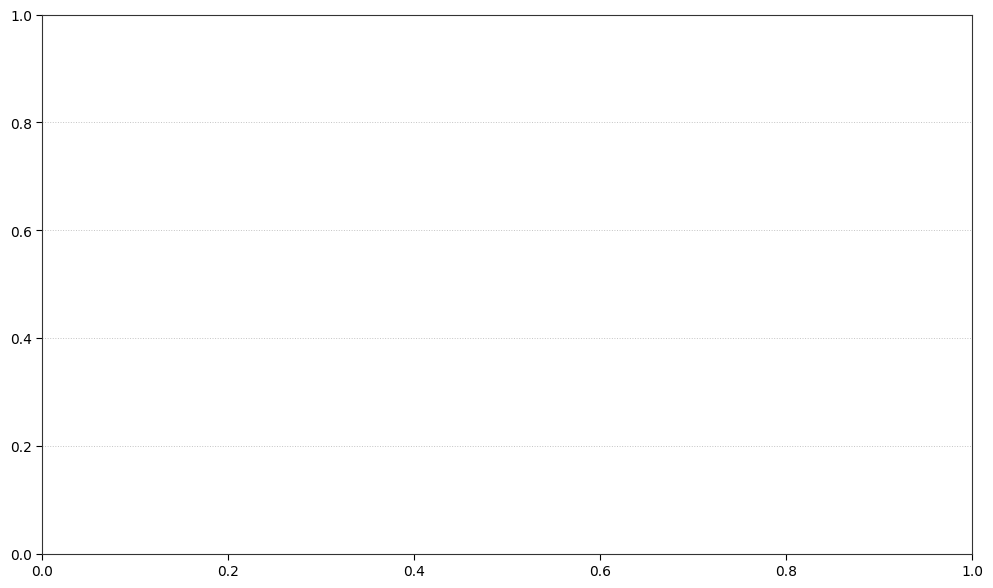

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects

# ============================================================
# PUBLICATION-GRADE VISUALIZATION - LOG SCALE Y-AXIS
# Color scheme: Green, Orange, Purple, Brown (from Figure 5)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# Color scheme from Figure 5
colors = ["#1b7837", "#e08214", "#762a83", "#b35806"]

x = np.arange(len(countries)) * 1.15
width = 0.15
gap = 0.05

# --- Plot bars ---
for i, group in enumerate(disclosure_groups):
    offset = (i - 1.5) * (width + gap)
    values = country_results[group]
    
    bars = ax.bar(
        x + offset,
        values,
        width,
        label=group,
        color=colors[i],
        edgecolor='white',
        linewidth=1.2,
        zorder=3,
        alpha=0.9
    )
    
    # Value labels
    for bar, val in zip(bars, values):
        if val > 1.0:
            txt = ax.text(
                bar.get_x() + bar.get_width() / 2,
                val * 1.05,
                f"{val:.1f}",
                ha='center',
                va='bottom',
                fontsize=13,
                fontweight='bold',
                color='#1a1a1a'
            )
            txt.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='white')])

# --- X-axis ---
ax.set_xticks(x)
# ax.set_xticklabels(countries, fontsize=18, fontweight='bold', color='#1a1a1a')
ax.set_xticklabels(
    countries,
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    rotation=45,
    ha='right'
)
# --- Y-axis: LOG SCALE ---
ax.set_yscale('log')
ax.set_ylabel("Percentage of sites (%)", 
              fontsize=17, fontweight='bold', color='#1a1a1a', labelpad=10)
ax.set_ylim(1, 100)
ax.set_yticks([1, 2, 5, 10, 20, 100])
ax.set_yticklabels(['1', '2', '5', '10', '20', '100'], fontsize=10)
ax.tick_params(axis='y', labelsize=10, colors='#333333')

# --- Grid ---
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#999999', zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#aaaaaa')   # slightly darker
    spine.set_linewidth(1.0)     # slightly thicker
# --- Legend ---
# --- Legend --- REPLACE the existing legend block with this ---
legend = ax.legend(
    loc='upper right',
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor='#aaaaaa',
    fontsize=14,
    columnspacing=1.5,
    handlelength=1.8,
    handleheight=1.0,
    borderpad=0.8,
    labelspacing=0.6,
)
legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Also remove the bottom padding that was reserved for the outside legend
plt.tight_layout()
plt.subplots_adjust(top=0.50)   # drop the bottom=0.12 line

# # --- Title ---
# ax.set_title(
#     "Fingerprinting Activity Persists After Cookie Rejection",
#     fontsize=15,
#     fontweight='bold',
#     pad=20,
#     color='#1a1a1a'
# )

# # --- Subtitle ---
# ax.text(
#     0.5, 1.08,
#     "Percentage of websites (with no tracking cookies) that still load fingerprinting scripts",
#     transform=ax.transAxes,
#     ha='center',
#     fontsize=10,
#     color='#666666',
#     style='italic'
# )

# plt.tight_layout()
# plt.subplots_adjust(bottom=0.12, top=0.88)

plt.savefig('Diff_geo_location.pdf', dpi=300, bbox_inches='tight')
plt.show()

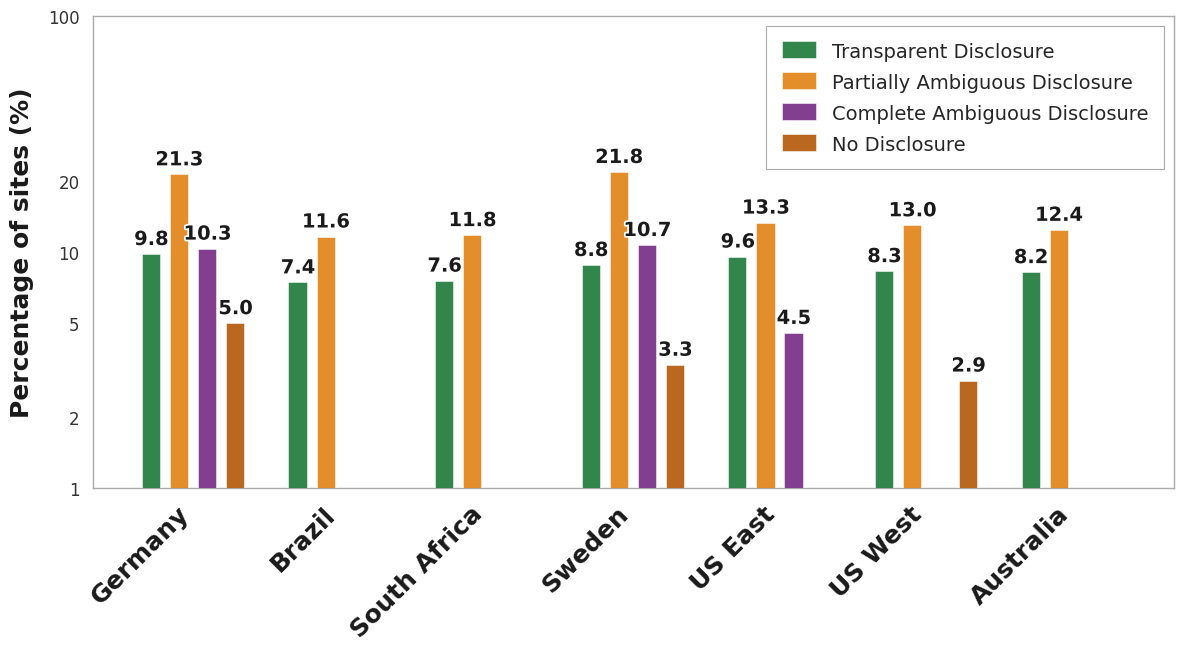

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects
from matplotlib.ticker import LogLocator, NullFormatter

# Minor ticks at every integer/sub-decade position
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(1, 10) * 0.1, numticks=20))
ax.yaxis.set_minor_formatter(NullFormatter())  # no labels, just marks

ax.tick_params(axis='y', which='major', length=6, width=1.0, colors='#333333')
ax.tick_params(axis='y', which='minor', length=3, width=0.6, colors='#aaaaaa')

# ============================================================
# PUBLICATION-GRADE VISUALIZATION - LOG SCALE Y-AXIS
# White background + no grid (Overleaf friendly)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Color scheme
colors = ["#1b7837", "#e08214", "#762a83", "#b35806"]

x = np.arange(len(countries)) * 1.15
width = 0.15
gap = 0.07

# --- Plot bars ---
for i, group in enumerate(disclosure_groups):
    offset = (i - 1.5) * (width + gap)
    values = country_results[group]

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=group,
        color=colors[i],
        edgecolor='white',
        linewidth=1.2,
        alpha=0.9,
        zorder=3
    )

    # Value labels
    for bar, val in zip(bars, values):
        if val > 1.0:
            txt = ax.text(
                bar.get_x() + bar.get_width() / 2,
                val * 1.05,
                f"{val:.1f}",
                ha='center',
                va='bottom',
                fontsize=14,
                fontweight='bold',
                color='#1a1a1a'
            )

            txt.set_path_effects([
                path_effects.withStroke(
                    linewidth=2.5,
                    foreground='white'
                )
            ])

# --- X-axis ---
ax.set_xticks(x)

ax.set_xticklabels(
    countries,
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    rotation=45,
    ha='right'
)

# --- Y-axis (LOG SCALE) ---
ax.set_yscale('log')

ax.set_ylabel(
    "Percentage of sites (%)",
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    labelpad=10
)

ax.set_ylim(1, 100)

ax.set_yticks([1, 2, 5, 10, 20, 100])

ax.set_yticklabels(
    ['1', '2', '5', '10', '20', '100'],
    fontsize=12
)

ax.tick_params(
    axis='y',
    labelsize=12,
    colors='#333333'
)

# --- Border styling ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#aaaaaa')
    spine.set_linewidth(1.0)

# --- Legend ---
legend = ax.legend(
    loc='upper right',
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor='#aaaaaa',
    fontsize=14,
    columnspacing=1.5,
    handlelength=1.8,
    handleheight=1.0,
    borderpad=0.8,
    labelspacing=0.6
)

legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1.0)

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# --- Save ---
plt.savefig(
    "Diff_geo_location.pdf",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

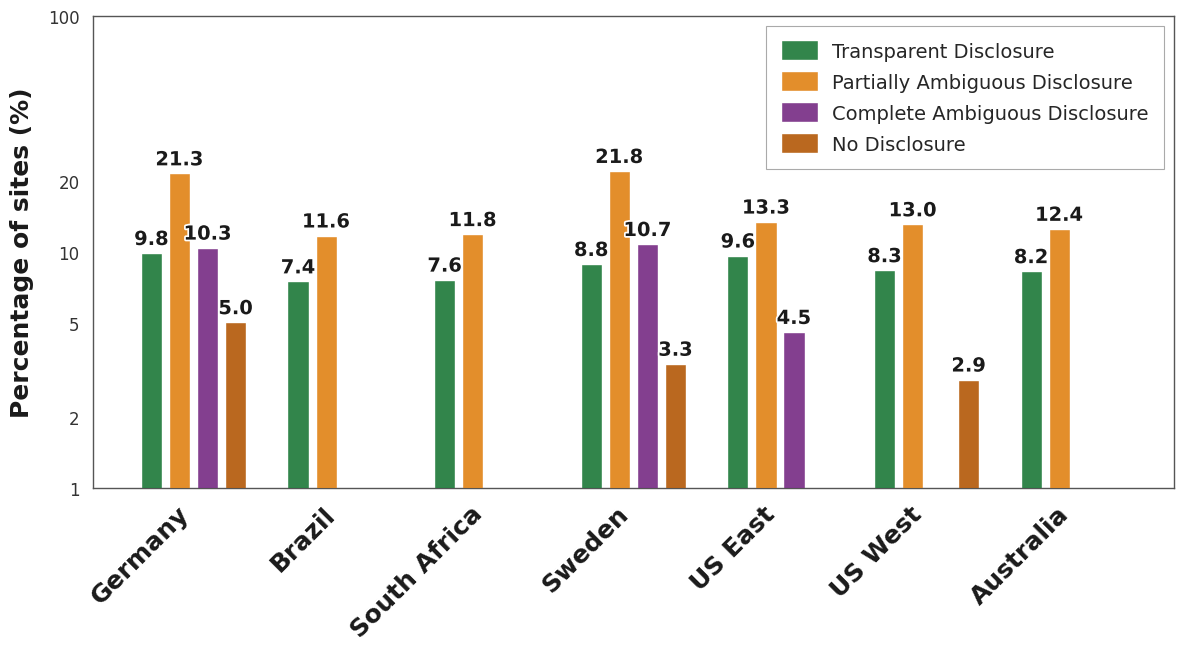

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects
from matplotlib.ticker import LogLocator, NullFormatter

# ============================================================
# PUBLICATION-GRADE VISUALIZATION - LOG SCALE Y-AXIS
# White background + full bounding box
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

# White background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Color scheme
colors = ["#1b7837", "#e08214", "#762a83", "#b35806"]

x = np.arange(len(countries)) * 1.15
width = 0.15
gap = 0.07

# --- Plot bars ---
for i, group in enumerate(disclosure_groups):

    offset = (i - 1.5) * (width + gap)
    values = country_results[group]

    bars = ax.bar(
        x + offset,
        values,
        width,
        label=group,
        color=colors[i],
        edgecolor=colors[i],
        linewidth=0.4,
        alpha=0.9,
        zorder=3
    )

    # Value labels
    for bar, val in zip(bars, values):

        if val > 1.0:

            txt = ax.text(
                bar.get_x() + bar.get_width() / 2,
                val * 1.05,
                f"{val:.1f}",
                ha='center',
                va='bottom',
                fontsize=14,
                fontweight='bold',
                color='#1a1a1a'
            )

            txt.set_path_effects([
                path_effects.withStroke(
                    linewidth=2.5,
                    foreground='white'
                )
            ])

# --- X-axis ---
ax.set_xticks(x)

ax.set_xticklabels(
    countries,
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    rotation=45,
    ha='right'
)

# --- Y-axis (LOG SCALE) ---
ax.set_yscale('log')

ax.set_ylabel(
    "Percentage of sites (%)",
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    labelpad=10
)

ax.set_ylim(1, 100)

ax.set_yticks([1, 2, 5, 10, 20, 100])

ax.set_yticklabels(
    ['1', '2', '5', '10', '20', '100'],
    fontsize=12
)

# Major ticks
ax.tick_params(
    axis='y',
    which='major',
    length=6,
    width=1.0,
    colors='#333333'
)

# Minor ticks
ax.yaxis.set_minor_locator(
    LogLocator(
        base=10,
        subs=np.arange(1, 10) * 0.1,
        numticks=20
    )
)

ax.yaxis.set_minor_formatter(
    NullFormatter()
)

ax.tick_params(
    axis='y',
    which='minor',
    length=3,
    width=0.6,
    colors='#aaaaaa'
)

# --- Remove grid ---
ax.grid(False)

# --- Full bounding box ---
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#555555')
    spine.set_linewidth(1.0)

# --- Legend ---
legend = ax.legend(
    loc='upper right',
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor='#aaaaaa',
    fontsize=14,
    columnspacing=1.5,
    handlelength=1.8,
    handleheight=1.0,
    borderpad=0.8,
    labelspacing=0.6
)

legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1.0)

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# --- Save ---
plt.savefig(
    "Diff_geo_location.pdf",
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

In [2]:
import requests
import json
import os

def download_disconnect_list():
    """
    Download the Disconnect.me tracker protection list
    """
    # URL for the Disconnect.me services list
    url = "https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json"

    print("Downloading Disconnect.me tracker list...")
    print(f"URL: {url}")

    try:
        # Download the file
        response = requests.get(url, timeout=30)
        response.raise_for_status()  # Raise an error for bad status codes

        # Parse JSON
        json_data = response.json()

        # Create directory if it doesn't exist
        os.makedirs('dataset_disconnect', exist_ok=True)

        # Save to file
        output_file = 'dataset_disconnect/services-relay-disconnect.json'
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

        print(f"✓ Successfully downloaded and saved to: {output_file}")

        # Display available categories
        if 'categories' in json_data:
            print("\nAvailable categories:")
            for category in json_data['categories'].keys():
                domain_count = len(json_data['categories'][category])
                print(f"  - {category}: {domain_count} domains")

        return json_data

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading file: {e}")
        print("\nAlternative URLs to try:")
        print("1. https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json")
        print("2. https://services.disconnect.me/disconnect-plaintext.json")
        return None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None

def extract_domains_from_category(category_list):
    """
    Extract all domains from a nested category structure

    Format:
    [
      {"ServiceName": {"url": ["domain1", "domain2"]}},
      ...
    ]
    """
    domains = set()

    for item in category_list:
        # Each item is a dict with one key (service name)
        for service_name, service_data in item.items():
            # service_data is a dict with URLs as keys and domain lists as values
            for url, domain_list in service_data.items():
                # Add all domains from the list
                domains.update(domain_list)

    return domains

def load_and_process_disconnect_data(json_file='dataset_disconnect/services-relay-disconnect.json'):
    """
    Load the Disconnect.me list and extract fingerprinting domains
    """
    print(f"\nLoading Disconnect.me data from: {json_file}")

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        # Extract domains from FingerprintingInvasive and FingerprintingGeneral categories
        fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
        fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])

        # Parse the nested structure to extract actual domains
        fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
        fp_general_domains = extract_domains_from_category(fp_general_list)


        print(f"✓ Loaded successfully")
        print(f"  - FingerprintingInvasive domains: {len(fp_invasive_domains)}")
        print(f"  - FingerprintingGeneral domains: {len(fp_general_domains)}")


        # Display some example domains
        if fp_invasive_domains:
            print(f"\nExample FingerprintingInvasive domains:")
            for domain in list(fp_invasive_domains)[:5]:
                print(f"  - {domain}")

        if fp_general_domains:
            print(f"\nExample FingerprintingGeneral domains:")
            for domain in list(fp_general_domains)[:5]:
                print(f"  - {domain}")

        return fp_invasive_domains, fp_general_domains

    except FileNotFoundError:
        print(f"✗ File not found: {json_file}")
        print("Run download_disconnect_list() first to download the file.")
        return None, None, None, None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None, None, None, None

def apply_disconnect_categories_to_dataframe(df, domain_column='domain_script_url'):
    """
    Apply FingerprintingInvasive and FingerprintingGeneral boolean columns to dataframe

    Parameters:
    - df: pandas DataFrame with script/request data
    - domain_column: column name containing the domain to check
    """
    # Load the disconnect data
    fp_invasive_domains, fp_general_domains = load_and_process_disconnect_data()

    if fp_invasive_domains is None:
        print("Failed to load Disconnect.me data. Attempting to download...")
        json_data = download_disconnect_list()
        if json_data:
            fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
            fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])


            fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
            fp_general_domains = extract_domains_from_category(fp_general_list)

        else:
            return df

    # Create boolean columns
    print(f"\nApplying categories to dataframe...")
    df['FingerprintingInvasive'] = df[domain_column].isin(fp_invasive_domains)
    df['FingerprintingGeneral'] = df[domain_column].isin(fp_general_domains)


    print(f"✓ Categories applied:")
    print(f"  - FingerprintingInvasive: {df['FingerprintingInvasive'].sum()} matches")
    print(f"  - FingerprintingGeneral: {df['FingerprintingGeneral'].sum()} matches")


    return df

# # ============================================================
# # MAIN EXECUTION
# # ============================================================
# if __name__ == "__main__":
#     print("="*60)
#     print("DISCONNECT.ME TRACKER LIST DOWNLOADER")
#     print("="*60)
#     df_2 = main_map_unique["javascript"]
#     df_2 = df_2[df_2["clicked"].notna()]
#     df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
#     df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)

#     # Step 1: Download the list
#     json_data = download_disconnect_list()

#     if json_data:
#         # Step 2: Load and process
#         df_2 = apply_disconnect_categories_to_dataframe(df_2, domain_column='domain_script_url')


Disclosure sets loaded from 'Split_disclosure_output/':
  Transparent          : 17257 domains
  Partially Ambiguous  : 15818 domains
  Completely Ambiguous :   324 domains
  No Disclosure        :   547 domains
  class_1 … class_8    : [478, 16774, 5, 8468, 7000, 350, 324, 547]
URL: https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json
✓ Successfully downloaded and saved to: dataset_disconnect/services-relay-disconnect.json

Available categories:
  - Email: 83 domains
  - EmailAggressive: 84 domains
  - Advertising: 1272 domains
  - Content: 101 domains
  - Analytics: 355 domains
  - FingerprintingInvasive: 282 domains
  - FingerprintingGeneral: 98 domains
  - Anti-fraud: 15 domains
  - Social: 16 domains
  - ConsentManagers: 7 domains
  - Cryptomining: 14 domains

Loading Disconnect.me data from: dataset_disconnect/services-relay-disconnect.json
✓ Loaded successfully
  - FingerprintingInvasive domains: 377
  - FingerprintingGeneral domains

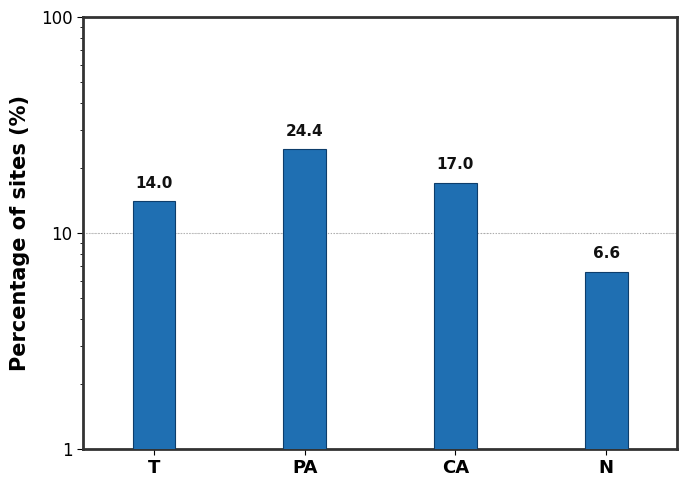

In [15]:
"""
analyse.py  –  Fingerprinting-after-reject analysis
=====================================================
Folder layout expected:

  Split_disclosure_output/
      Transparent.csv
      Partially_Ambiguous.csv
      Completely_Ambiguous.csv
      No_Disclosure.csv
      class_1.csv  …  class_8.csv   (optional sub-classes)

  js.csv
  javascript_cookies.csv

Outputs:
  fingerprinting_by_disclosure.pdf
  fingerprinting_by_disclosure.png
"""

import os, sys
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG  –  edit these two lines if your paths differ
# ══════════════════════════════════════════════════════════════════════════════
DISCLOSURE_DIR = "Split_disclosure_output"   # folder with the four CSVs
JS_CSV         = "REJECT/js.csv"
COOKIE_CSV     = "REJECT/javascript_cookies.csv"

DISCLOSURE_GROUPS = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure",
]

# ══════════════════════════════════════════════════════════════════════════════
# 1.  Load disclosure sets from Split_disclosure_output/
# ══════════════════════════════════════════════════════════════════════════════
def read_set(path):
    """Read a one-column CSV / plain list of domains; return a Python set."""
    if not os.path.exists(path):
        print(f"  [WARN] not found, skipping: {path}")
        return set()
    with open(path, "r") as f:
        return {line.strip() for line in f if line.strip()}

transparent  = read_set(f"{DISCLOSURE_DIR}/Transparent.csv")
partial      = read_set(f"{DISCLOSURE_DIR}/Partially_Ambiguous.csv")
complete     = read_set(f"{DISCLOSURE_DIR}/Completely_Ambiguous.csv")
no_disc      = read_set(f"{DISCLOSURE_DIR}/No_Disclosure.csv")

# Optional sub-class files (class_1.csv … class_8.csv) – loaded but not used
# in the main chart; extend here if you need them later
classes = {}
for i in range(1, 9):
    p = f"{DISCLOSURE_DIR}/class_{i}.csv"
    classes[f"class_{i}"] = read_set(p)   # empty set if file missing

print(f"Disclosure sets loaded from '{DISCLOSURE_DIR}/':")
print(f"  Transparent          : {len(transparent):>5} domains")
print(f"  Partially Ambiguous  : {len(partial):>5} domains")
print(f"  Completely Ambiguous : {len(complete):>5} domains")
print(f"  No Disclosure        : {len(no_disc):>5} domains")
print(f"  class_1 … class_8    : {[len(classes[f'class_{i}']) for i in range(1,9)]}")

# ── Lookup helper ─────────────────────────────────────────────────────────────
def get_group(domain):
    if domain in transparent : return "Transparent"
    if domain in partial     : return "Partially Ambiguous"
    if domain in complete    : return "Completely Ambiguous"
    if domain in no_disc     : return "No Disclosure"
    return "Unknown"

# All known domains = union of the four sets
all_domains = transparent | partial | complete | no_disc

# ══════════════════════════════════════════════════════════════════════════════
# 2.  Load js.csv and javascript_cookies.csv
# ══════════════════════════════════════════════════════════════════════════════
def load_csv(path, label):
    if not os.path.exists(path):
        sys.exit(f"[ERROR] {label} not found at: {path}")
    return pd.read_csv(path)

df_js      = load_csv(JS_CSV,     "js.csv")
json_data = download_disconnect_list()

if json_data:
    # Step 2: Load and process
    df_js = apply_disconnect_categories_to_dataframe(df_js, domain_column='domain_script_url')

df_cookies = load_csv(COOKIE_CSV, "javascript_cookies.csv")

print(f"\nLoaded js.csv         : {len(df_js):>6} rows")
print(f"Loaded cookies.csv    : {len(df_cookies):>6} rows")

# ══════════════════════════════════════════════════════════════════════════════
# 3.  Domains with 3rd-party tracking cookies AFTER Reject
# ══════════════════════════════════════════════════════════════════════════════
rej_cookies = df_cookies[
    df_cookies["clicked_stage"] == "After Interaction (Reject)"
].copy()
rej_cookies = rej_cookies[
    rej_cookies["domain_cookie"] != rej_cookies["domain"]   # 3rd-party only
]

domains_with_tracking_cookies    = set(rej_cookies["domain"])
domains_without_tracking_cookies = all_domains - domains_with_tracking_cookies

# ══════════════════════════════════════════════════════════════════════════════
# 4.  Domains with fingerprinting scripts AFTER Reject
#     (AllList=True, FingerprintingInvasive or General, 3rd-party script)
# ══════════════════════════════════════════════════════════════════════════════
rej_js = df_js[
    (df_js["clicked_stage"] == "After Interaction (Reject)")
    & (df_js["AllList"] == True)
    & (
        (df_js["FingerprintingInvasive"] == True)
        | (df_js["FingerprintingGeneral"] == True)
    )
    & (df_js["domain_script_url"] != df_js["domain"])
].copy()

domains_with_fp_scripts = set(rej_js["domain"])

# Only sites that have fp scripts but NO tracking cookies
domains_scripts_only = domains_with_fp_scripts & domains_without_tracking_cookies

# ══════════════════════════════════════════════════════════════════════════════
# 5.  Aggregate by disclosure group
# ══════════════════════════════════════════════════════════════════════════════
group_total = defaultdict(int)
group_hits  = defaultdict(int)

for d in domains_without_tracking_cookies:
    g = get_group(d)
    if g in DISCLOSURE_GROUPS:
        group_total[g] += 1

for d in domains_scripts_only:
    g = get_group(d)
    if g in DISCLOSURE_GROUPS:
        group_hits[g] += 1

# ── Print summary ─────────────────────────────────────────────────────────────
print("\n" + "─" * 56)
print(f"{'Disclosure Group':<26} {'Total':>6}  {'FP Scripts':>10}  {'%':>6}")
print("─" * 56)
for g in DISCLOSURE_GROUPS:
    t = group_total[g]
    h = group_hits[g]
    p = h / t * 100 if t else 0.0
    print(f"{g:<26} {t:>6}  {h:>10}  {p:>5.1f}%")
print("─" * 56)

percentages = [
    group_hits[g] / group_total[g] * 100 if group_total[g] else 0.0
    for g in DISCLOSURE_GROUPS
]

# ══════════════════════════════════════════════════════════════════════════════
# 6.  Publication-grade chart  (Overleaf / LaTeX compatible)
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family":        "DejaVu Sans",
    "mathtext.fontset":   "dejavusans",
    "font.size":          11,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "axes.spines.top":    True,
    "axes.spines.right":  True,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.linewidth":     2,
    "axes.edgecolor":     "#333333",
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.alpha":         0.35,
    "grid.linestyle":     ":",
    "grid.linewidth":     0.7,
    "grid.color":         "#555555",
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
})

fig, ax = plt.subplots(figsize=(7, 5))

# bar positions (slightly compressed)
x = np.arange(len(DISCLOSURE_GROUPS)) * 0.88 - 1
bar_w      = 0.25
BAR_COLOR  = "#1f6fb2"
EDGE_COLOR = "#0d3d6b"

bars = ax.bar(
    x,
    percentages,
    width=bar_w,
    color=BAR_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.8,
    zorder=3
)

# ── Log-scale y-axis ──────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(1, 100)
ax.tick_params(axis='y', labelsize=12)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda y, _: f"{int(y)}" if y >= 1 else f"{y:.1f}"
))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

# ── Value labels on top of bars ───────────────────────────────────────────────
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.12,
        f"{pct:.1f}",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="#111111",
    )

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_ylabel("Percentage of sites (%)", fontsize=15, fontweight="bold", labelpad=8)

# ── X labels – 45° inclined, right-aligned, unfolded (no \n wrapping) ────────
x_labels = [
    "T",
    "PA",
    "CA",
    "N",
]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0, ha="center",
                   rotation_mode="anchor", fontsize=13, fontweight="bold")

# ── Dotted reference line at 10 % ─────────────────────────────────────────────
ax.axhline(10, color="#aaaaaa", linewidth=0.8, linestyle=":", zorder=2)

ax.margins(x=0.10)
plt.tight_layout()

fig.savefig("sites_still_tracking_after_reject.pdf", dpi=300, bbox_inches="tight")
# fig.savefig("fingerprinting_by_disclosure.png", dpi=300, bbox_inches="tight")
print("\n✓  Saved fingerprinting_by_disclosure.pdf / .png")
plt.show()


════════════════════════════════════════════════════════
  Processing folder: REJECT/250k/
════════════════════════════════════════════════════════
  Transparent               :   821 domains
  Partially Ambiguous       :   564 domains
  Completely Ambiguous      :    14 domains
  No Disclosure             :    21 domains
(43638, 7)
URL: https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json
✓ Successfully downloaded and saved to: dataset_disconnect/services-relay-disconnect.json

Available categories:
  - Email: 83 domains
  - EmailAggressive: 84 domains
  - Advertising: 1272 domains
  - Content: 101 domains
  - Analytics: 355 domains
  - FingerprintingInvasive: 282 domains
  - FingerprintingGeneral: 98 domains
  - Anti-fraud: 15 domains
  - Social: 16 domains
  - ConsentManagers: 7 domains
  - Cryptomining: 14 domains

Loading Disconnect.me data from: dataset_disconnect/services-relay-disconnect.json
✓ Loaded successfully
  - Fingerprintin

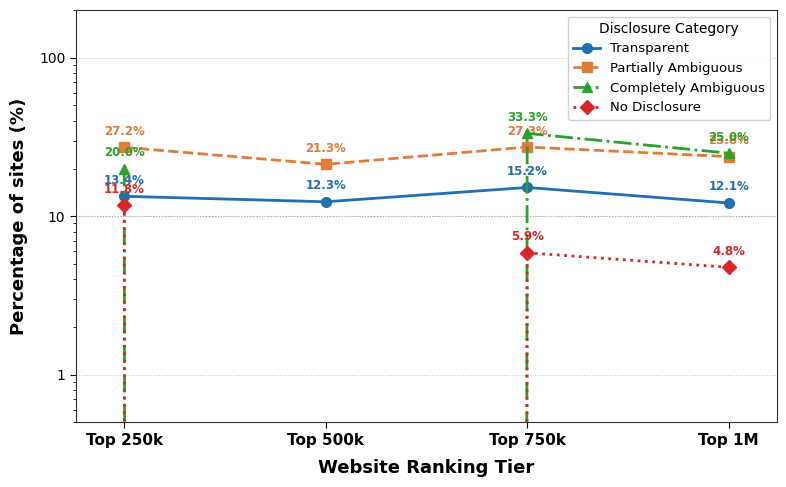

In [21]:
"""
analyse_multi.py  –  Fingerprinting-after-reject analysis across rank tiers
============================================================================
Folder layout expected (NO sub-directory for disclosure files):

  250k/
      Transparent.csv
      Partially_Ambiguous.csv
      Completely_Ambiguous.csv
      No_Disclosure.csv
      js.csv
      javascript_cookies.csv

  500k/   (same layout)
  750k/   (same layout)
  1M/     (same layout)

Output:
  fingerprinting_by_rank_tier.pdf
  fingerprinting_by_rank_tier.png
"""

import os, sys
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
BASE_DIR   = "REJECT"       
RANK_TIERS = ["250k", "500k", "750k", "1M"]   # folder names & x-axis labels

DISCLOSURE_GROUPS = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure",
]

# File names inside each rank-tier folder
DISCLOSURE_FILES = {
    "Transparent"          : "Transparent.csv",
    "Partially Ambiguous"  : "Partially_Ambiguous.csv",
    "Completely Ambiguous" : "Completely_Ambiguous.csv",
    "No Disclosure"        : "No_Disclosure.csv",
}
JS_FILENAME     = "js.csv"
COOKIE_FILENAME = "javascript_cookies.csv"

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def read_set(path):
    """Read a one-column CSV / plain list of domains; return a Python set."""
    if not os.path.exists(path):
        print(f"  [WARN] not found, skipping: {path}")
        return set()
    with open(path, "r") as f:
        return {line.strip() for line in f if line.strip()}


def load_csv(path, label):
    if not os.path.exists(path):
        print(f"  [ERROR] {label} not found at: {path}")
        return None
    return pd.read_csv(path)


def compute_percentages(folder):
    """
    For a single rank-tier folder, compute the % of sites with
    fingerprinting scripts (but no tracking cookies) after Reject,
    broken down by disclosure group.

    Returns dict  {group_name: percentage_float}
    """
    folder = os.path.join(BASE_DIR, tier)   # → REJECT/250k, REJECT/500k, …
    print(f"\n{'═'*56}")
    print(f"  Processing folder: {folder}/")
    print(f"{'═'*56}")

    # ── 1. Load disclosure sets ───────────────────────────────────────────────
    sets = {}
    for group, fname in DISCLOSURE_FILES.items():
        path = os.path.join(folder, fname)
        sets[group] = read_set(path)
        print(f"  {group:<26}: {len(sets[group]):>5} domains")

    all_domains = sets["Transparent"] | sets["Partially Ambiguous"] | \
                  sets["Completely Ambiguous"] | sets["No Disclosure"]

    def get_group(domain):
        for g, s in sets.items():
            if domain in s:
                return g
        return "Unknown"

    # ── 2. Load js.csv and javascript_cookies.csv ─────────────────────────────
    df_js = load_csv(os.path.join(folder, JS_FILENAME), "js.csv")
    print(df_js.shape)
    json_data = download_disconnect_list()
    if json_data:
    # Step 2: Load and process
        df_js = apply_disconnect_categories_to_dataframe(df_js, domain_column='domain_script_url')

    df_cookies = load_csv(COOKIE_CSV, "javascript_cookies.csv")
    
    df_cookies = load_csv(os.path.join(folder, COOKIE_FILENAME), "javascript_cookies.csv")

    if df_js is None or df_cookies is None:
        print(f"  [SKIP] Missing data files in {folder}/")
        return {g: 0.0 for g in DISCLOSURE_GROUPS}

    print(f"  js.csv         : {len(df_js):>6} rows")
    print(f"  cookies.csv    : {len(df_cookies):>6} rows")

    # ── 3. 3rd-party tracking cookies after Reject ────────────────────────────
    rej_cookies = df_cookies[
        df_cookies["clicked_stage"] == "After Interaction (Reject)"
    ].copy()
    rej_cookies = rej_cookies[
        rej_cookies["domain_cookie"] != rej_cookies["domain"]
    ]
    domains_with_tracking_cookies    = set(rej_cookies["domain"])
    domains_without_tracking_cookies = all_domains - domains_with_tracking_cookies


    # ── 4. Fingerprinting scripts after Reject ───────────────────────────────
    rej_js = df_js[
        (df_js["clicked_stage"] == "After Interaction (Reject)")
        & (df_js["AllList"] == True)
        & (
            (df_js["FingerprintingInvasive"] == True)
            | (df_js["FingerprintingGeneral"] == True)
        )
        & (df_js["domain_script_url"] != df_js["domain"])
    ].copy()

    domains_with_fp_scripts = set(rej_js["domain"])

    # Sites with FP scripts but NO tracking cookies
    domains_scripts_only = domains_with_fp_scripts & domains_without_tracking_cookies

    # ── 5. Aggregate by group ─────────────────────────────────────────────────
    group_total = defaultdict(int)
    group_hits  = defaultdict(int)

    for d in domains_without_tracking_cookies:
        g = get_group(d)
        if g in DISCLOSURE_GROUPS:
            group_total[g] += 1

    for d in domains_scripts_only:
        g = get_group(d)
        if g in DISCLOSURE_GROUPS:
            group_hits[g] += 1

    print(f"\n  {'Group':<26} {'Total':>6}  {'FP Scripts':>10}  {'%':>6}")
    print(f"  {'─'*52}")
    result = {}
    for g in DISCLOSURE_GROUPS:
        t = group_total[g]
        h = group_hits[g]
        p = h / t * 100 if t else 0.0
        result[g] = p
        print(f"  {g:<26} {t:>6}  {h:>10}  {p:>5.1f}%")

    return result


# ══════════════════════════════════════════════════════════════════════════════
# MAIN  –  iterate over all rank tiers
# ══════════════════════════════════════════════════════════════════════════════
# results[group][tier_index] = percentage
results = {g: [] for g in DISCLOSURE_GROUPS}

for tier in RANK_TIERS:
    pct = compute_percentages(tier)
    for g in DISCLOSURE_GROUPS:
        results[g].append(pct.get(g, 0.0))


# ══════════════════════════════════════════════════════════════════════════════
# CHART  –  line chart, one line per disclosure group
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family":        "DejaVu Sans",
    "mathtext.fontset":   "dejavusans",
    "font.size":          11,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "axes.spines.top":    True,
    "axes.spines.right":  True,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "axes.linewidth":     0.8,
    "axes.edgecolor":     "#333333",
    "axes.grid":          True,
    "axes.grid.axis":     "y",
    "grid.alpha":         0.35,
    "grid.linestyle":     ":",
    "grid.linewidth":     0.7,
    "grid.color":         "#555555",
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.labelsize":    11,
    "ytick.labelsize":    10,
})

# One distinct color per disclosure group
LINE_STYLES = {
    "Transparent"          : {"color": "#1f6fb2", "marker": "o",  "linestyle": "-"},
    "Partially Ambiguous"  : {"color": "#e07b39", "marker": "s",  "linestyle": "--"},
    "Completely Ambiguous" : {"color": "#2ca02c", "marker": "^",  "linestyle": "-."},
    "No Disclosure"        : {"color": "#d62728", "marker": "D",  "linestyle": ":"},
}

x = np.arange(len(RANK_TIERS))

fig, ax = plt.subplots(figsize=(8, 5))

for g in DISCLOSURE_GROUPS:
    style = LINE_STYLES[g]
    y = results[g]
    ax.plot(
        x, y,
        color=style["color"],
        marker=style["marker"],
        linestyle=style["linestyle"],
        linewidth=2.0,
        markersize=7,
        label=g,
        zorder=3,
    )
    # Annotate each data point
    for xi, yi in zip(x, y):
        ax.annotate(
            f"{yi:.1f}%",
            xy=(xi, yi),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
            color=style["color"],
            fontweight="bold",
        )

# ── Log-scale y-axis ──────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(0.5, 200)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(
    lambda y, _: f"{int(y)}" if y >= 1 else f"{y:.1f}"
))
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

# ── Reference line at 10 % ────────────────────────────────────────────────────
ax.axhline(10, color="#aaaaaa", linewidth=0.8, linestyle=":", zorder=2)

# ── Axes labels & ticks ───────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(
    ["Top 250k", "Top 500k", "Top 750k", "Top 1M"],
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Website Ranking Tier", fontsize=13, fontweight="bold", labelpad=8)
ax.set_ylabel("Percentage of sites (%)", fontsize=13, fontweight="bold", labelpad=8)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    title="Disclosure Category",
    title_fontsize=10,
    fontsize=9.5,
    loc="upper right",
    framealpha=0.9,
    edgecolor="#cccccc",
)

ax.margins(x=0.08)
plt.tight_layout()

fig.savefig("fingerprinting_by_rank_tier.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fingerprinting_by_rank_tier.png", dpi=300, bbox_inches="tight")
print("\n✓  Saved fingerprinting_by_rank_tier.pdf / .png")
plt.show()

✓  Saved  fingerprinting_by_rank_tier.pdf  /  .png


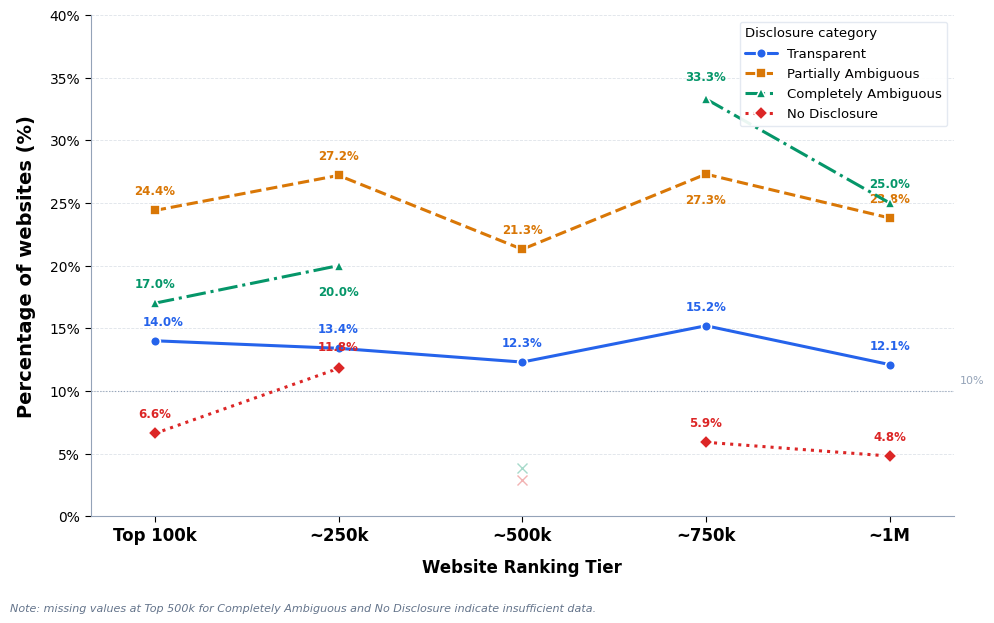

In [23]:
"""
plot_fingerprinting.py
======================
Standalone script – no CSV files needed.
Hardcoded data from manual analysis across 5 ranking tiers.

Output:
    fingerprinting_by_rank_tier.pdf
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ══════════════════════════════════════════════════════════════════════════════
# DATA  –  % of websites with fingerprinting scripts after Reject
#          None = missing / insufficient data for that tier
# ══════════════════════════════════════════════════════════════════════════════
X_LABELS = ["Top 100k", "~250k", "~500k", "~750k", "~1M"]

DATA = {
    "Transparent": {
        "values"    : [14.0, 13.4, 12.3, 15.2, 12.1],
        "color"     : "#2563EB",   # blue
        "linestyle" : "-",
        "marker"    : "o",
        "dashes"    : (None, None),
    },
    "Partially Ambiguous": {
        "values"    : [24.4, 27.2, 21.3, 27.3, 23.8],
        "color"     : "#D97706",   # amber
        "linestyle" : "--",
        "marker"    : "s",
        "dashes"    : (6, 3),
    },
    "Completely Ambiguous": {
        "values"    : [17.0, 20.0, None, 33.3, 25.0],
        "color"     : "#059669",   # green
        "linestyle" : "-.",
        "marker"    : "^",
        "dashes"    : (8, 3, 2, 3),
    },
    "No Disclosure": {
        "values"    : [6.6, 11.8, None, 5.9, 4.8],
        "color"     : "#DC2626",   # red
        "linestyle" : ":",
        "marker"    : "D",
        "dashes"    : (2, 3),
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# MATPLOTLIB STYLE
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "savefig.facecolor" : "white",
    "axes.linewidth"    : 0.8,
    "axes.edgecolor"    : "#94A3B8",
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
    "grid.color"        : "#94A3B8",
    "xtick.direction"   : "out",
    "ytick.direction"   : "out",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.labelsize"   : 10.5,
    "ytick.labelsize"   : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(X_LABELS))

for group, cfg in DATA.items():
    vals = cfg["values"]

    # ── Split into contiguous segments so None gaps break the line ────────────
    segments_x, segments_y = [], []
    seg_x, seg_y = [], []
    for xi, yi in zip(x, vals):
        if yi is None:
            if seg_x:
                segments_x.append(seg_x); segments_y.append(seg_y)
                seg_x, seg_y = [], []
        else:
            seg_x.append(xi); seg_y.append(yi)
    if seg_x:
        segments_x.append(seg_x); segments_y.append(seg_y)

    # ── Draw each contiguous segment ─────────────────────────────────────────
    label_drawn = False
    for sx, sy in zip(segments_x, segments_y):
        lbl = group if not label_drawn else "_nolegend_"
        ax.plot(
            sx, sy,
            color     = cfg["color"],
            linestyle = cfg["linestyle"],
            linewidth = 2.2,
            marker    = cfg["marker"],
            markersize= 7,
            markerfacecolor = cfg["color"],
            markeredgecolor = "white",
            markeredgewidth = 1.2,
            label     = lbl,
            zorder    = 3,
            solid_capstyle = "round",
        )
        label_drawn = True

    # ── Annotate every non-None data point ───────────────────────────────────
    for xi, yi in zip(x, vals):
        if yi is None:
            continue

        # Nudge labels so they don't collide with the line/markers
        # Default: above the point
        offset_x, offset_y = 0, 9

        # Special-case known collisions (750k cluster)
        if group == "Completely Ambiguous" and xi == x[3]:
            offset_y =  11
        if group == "Partially Ambiguous" and xi == x[3]:
            offset_y = -14     # push below to separate from Completely Ambiguous
        if group == "Completely Ambiguous" and xi == x[1]:
            offset_y = -14
        if group == "No Disclosure" and xi == x[1]:
            offset_y =  11
        if group == "Transparent" and xi == x[0]:
            offset_x = 6

        ax.annotate(
            f"{yi:.1f}%",
            xy         = (xi, yi),
            xytext     = (offset_x, offset_y),
            textcoords = "offset points",
            ha         = "center",
            va         = "bottom" if offset_y > 0 else "top",
            fontsize   = 8.5,
            fontweight = "bold",
            color      = cfg["color"],
        )

# ── Mark missing-data points with a faint ✕ ──────────────────────────────────
MISSING = {
    "Completely Ambiguous" : [2],   # Top 500k index
    "No Disclosure"        : [2],
}
for group, idxs in MISSING.items():
    cfg = DATA[group]
    for xi in idxs:
        ax.plot(xi, ax.get_ylim()[0] + 0.5, marker="x",
                color=cfg["color"], alpha=0.35, markersize=7, zorder=2)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(X_LABELS, fontsize=12, fontweight="bold")
ax.set_xlim(-0.35, len(X_LABELS) - 0.65)
ax.set_ylim(0, 40)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v)}%"))

ax.set_xlabel("Website Ranking Tier", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Percentage of websites (%)", fontsize=14, fontweight="bold", labelpad=10)

# ── Thin reference line at 10 % ───────────────────────────────────────────────
ax.axhline(10, color="#94A3B8", linewidth=0.8, linestyle=":", zorder=1)
ax.text(len(X_LABELS) - 0.62, 10.4, "10%", fontsize=8, color="#94A3B8", va="bottom")

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(
    title          = "Disclosure category",
    title_fontsize = 9.5,
    fontsize       = 9.5,
    loc            = "upper right",
    framealpha     = 0.92,
    edgecolor      = "#E2E8F0",
    handlelength   = 2.4,
    labelspacing   = 0.55,
)
leg._legend_box.align = "left"

# ── Footer note ───────────────────────────────────────────────────────────────
fig.text(
    0.01, -0.03,
    "Note: missing values at Top 500k for Completely Ambiguous and No Disclosure indicate insufficient data.",
    fontsize = 8,
    color    = "#64748B",
    style    = "italic",
)

plt.tight_layout()

fig.savefig("fingerprinting_by_rank_tier.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fingerprinting_by_rank_tier.png", dpi=300, bbox_inches="tight")
print("✓  Saved  fingerprinting_by_rank_tier.pdf  /  .png")
plt.show()

✓  Saved  fingerprinting_by_rank_tier.pdf  /  .png


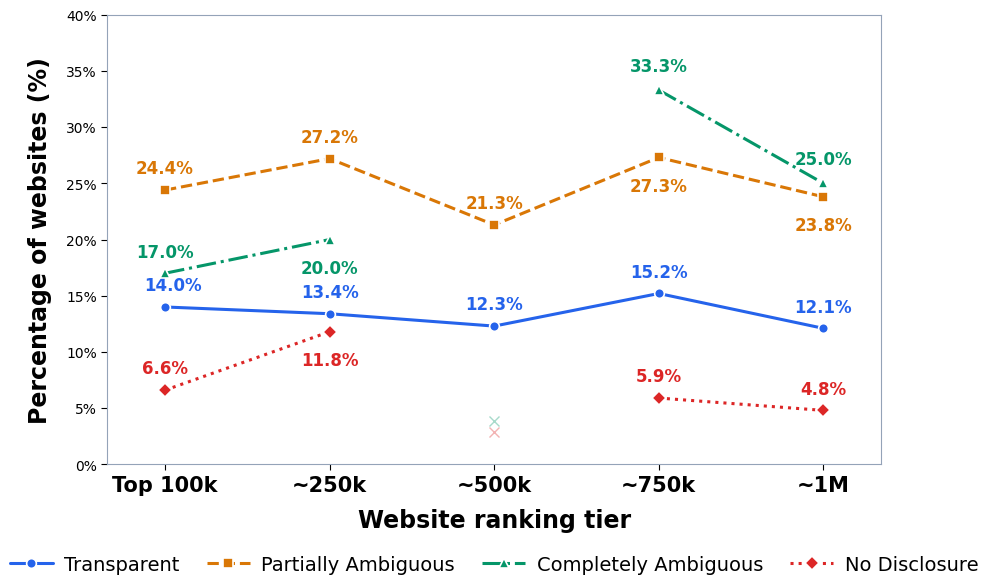

In [30]:
"""
plot_fingerprinting.py
======================
Standalone script – no CSV files needed.
Hardcoded data from manual analysis across 5 ranking tiers.

Output:
    fingerprinting_by_rank_tier.pdf
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ══════════════════════════════════════════════════════════════════════════════
# DATA  –  % of websites with fingerprinting scripts after Reject
#          None = missing / insufficient data for that tier
# ══════════════════════════════════════════════════════════════════════════════
X_LABELS = ["Top 100k", "~250k", "~500k", "~750k", "~1M"]

DATA = {
    "Transparent": {
        "values"    : [14.0, 13.4, 12.3, 15.2, 12.1],
        "color"     : "#2563EB",   # blue
        "linestyle" : "-",
        "marker"    : "o",
        "dashes"    : (None, None),
    },
    "Partially Ambiguous": {
        "values"    : [24.4, 27.2, 21.3, 27.3, 23.8],
        "color"     : "#D97706",   # amber
        "linestyle" : "--",
        "marker"    : "s",
        "dashes"    : (6, 3),
    },
    "Completely Ambiguous": {
        "values"    : [17.0, 20.0, None, 33.3, 25.0],
        "color"     : "#059669",   # green
        "linestyle" : "-.",
        "marker"    : "^",
        "dashes"    : (8, 3, 2, 3),
    },
    "No Disclosure": {
        "values"    : [6.6, 11.8, None, 5.9, 4.8],
        "color"     : "#DC2626",   # red
        "linestyle" : ":",
        "marker"    : "D",
        "dashes"    : (2, 3),
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# MATPLOTLIB STYLE
# ══════════════════════════════════════════════════════════════════════════════
mpl.rcParams.update({
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "white",
    "savefig.facecolor" : "white",
    "axes.linewidth"    : 0.8,
    "axes.edgecolor"    : "#94A3B8",
    "axes.grid"         : False,
    "xtick.direction"   : "out",
    "ytick.direction"   : "out",
    "xtick.major.size"  : 4,
    "ytick.major.size"  : 4,
    "xtick.labelsize"   : 10.5,
    "ytick.labelsize"   : 10,
    "axes.spines.top"   : True,
    "axes.spines.right" : True,
})

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(X_LABELS))

for group, cfg in DATA.items():
    vals = cfg["values"]

    # ── Split into contiguous segments so None gaps break the line ────────────
    segments_x, segments_y = [], []
    seg_x, seg_y = [], []
    for xi, yi in zip(x, vals):
        if yi is None:
            if seg_x:
                segments_x.append(seg_x); segments_y.append(seg_y)
                seg_x, seg_y = [], []
        else:
            seg_x.append(xi); seg_y.append(yi)
    if seg_x:
        segments_x.append(seg_x); segments_y.append(seg_y)

    # ── Draw each contiguous segment ─────────────────────────────────────────
    label_drawn = False
    for sx, sy in zip(segments_x, segments_y):
        lbl = group if not label_drawn else "_nolegend_"
        ax.plot(
            sx, sy,
            color     = cfg["color"],
            linestyle = cfg["linestyle"],
            linewidth = 2.2,
            marker    = cfg["marker"],
            markersize= 7,
            markerfacecolor = cfg["color"],
            markeredgecolor = "white",
            markeredgewidth = 1.2,
            label     = lbl,
            zorder    = 3,
            solid_capstyle = "round",
        )
        label_drawn = True

    # ── Annotate every non-None data point ───────────────────────────────────
    for xi, yi in zip(x, vals):
        if yi is None:
            continue

        # Nudge labels so they don't collide with the line/markers
        # Default: above the point
        offset_x, offset_y = 0, 9

        # Special-case known collisions
        if group == "Completely Ambiguous" and xi == x[3]:   # 750k: push green up
            offset_y =  11
        if group == "Partially Ambiguous" and xi == x[3]:    # 750k: push amber below
            offset_y = -14
        if group == "Completely Ambiguous" and xi == x[1]:   # 250k: push green below
            offset_y = -14
        if group == "No Disclosure" and xi == x[1]:          # 250k: push red below
            offset_y = -14
        if group == "Transparent" and xi == x[0]:            # 100k: slight right
            offset_x = 6
        if group == "Completely Ambiguous" and xi == x[4]:   # 1M: push green up
            offset_y =  11
        if group == "Partially Ambiguous" and xi == x[4]:    # 1M: push amber below
            offset_y = -14

        ax.annotate(
            f"{yi:.1f}%",
            xy         = (xi, yi),
            xytext     = (offset_x, offset_y),
            textcoords = "offset points",
            ha         = "center",
            va         = "bottom" if offset_y > 0 else "top",
            fontsize   = 12,
            fontweight = "bold",
            color      = cfg["color"],
        )

# ── Mark missing-data points with a faint ✕ ──────────────────────────────────
MISSING = {
    "Completely Ambiguous" : [2],   # Top 500k index
    "No Disclosure"        : [2],
}
for group, idxs in MISSING.items():
    cfg = DATA[group]
    for xi in idxs:
        ax.plot(xi, ax.get_ylim()[0] + 0.5, marker="x",
                color=cfg["color"], alpha=0.35, markersize=7, zorder=2)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(X_LABELS, fontsize=15, fontweight="bold")
ax.set_xlim(-0.35, len(X_LABELS) - 0.65)
ax.set_ylim(0, 40)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v)}%"))

ax.set_xlabel("Website ranking tier", fontsize=17, fontweight="bold", labelpad=10)
ax.set_ylabel("Percentage of websites (%)", fontsize=17, fontweight="bold", labelpad=10)

# # ── Thin reference line at 10 % ───────────────────────────────────────────────
# ax.axhline(10, color="#94A3B8", linewidth=0.8, linestyle=":", zorder=1)
# ax.text(len(X_LABELS) - 0.62, 10.4, "10%", fontsize=8, color="#94A3B8", va="bottom")

# ── Legend – single row below x-axis label ───────────────────────────────────
leg = ax.legend(
    title          = None,
    fontsize       = 14,
    loc            = "upper center",
    bbox_to_anchor = (0.5, -0.18),
    ncol           = 4,
    framealpha     = 0.0,
    edgecolor      = "none",
    handlelength   = 2.2,
    handletextpad  = 0.6,
    columnspacing  = 1.4,
    borderpad      = 0.0,
)

# # ── Footer note ───────────────────────────────────────────────────────────────
# fig.text(
#     0.01, -0.03,
#     "Note: missing values at Top 500k for Completely Ambiguous and No Disclosure indicate insufficient data.",
#     fontsize = 8,
#     color    = "#64748B",
#     style    = "italic",
# )

plt.tight_layout()

fig.savefig("fingerprinting_by_rank_tier.pdf", dpi=300, bbox_inches="tight")
fig.savefig("fingerprinting_by_rank_tier.png", dpi=300, bbox_inches="tight")
print("✓  Saved  fingerprinting_by_rank_tier.pdf  /  .png")
plt.show()